# AI-Based Smart Irrigation System Using Environmental Sensor Data

Internship project — Data Science + AI for IoT Agriculture


## Step 1 — Project Introduction

### The problem
Irrigation is one of the largest uses of fresh water in agriculture. Farmers usually decide *when* to irrigate using experience, a fixed schedule or a quick visual check of the field. That is difficult because soil conditions change continuously with weather, crop stage and soil type, and they are not monitored continuously. Two failure modes follow:

Under-irrigation : the crop is stressed because water was applied too late or not at all, which can reduce yield.
Over-irrigation : water, energy and money are wasted, and nutrients can be washed out of the soil.

### The purpose of the smart irrigation system
Measure field conditions automatically and use those measurements to recommend (or trigger) irrigation only when it is needed.

### Role of sensors and AI
Component and Role

Sensors: Continuously measure conditions in the field.
Machine-learning model:Learns from historical labelled data how sensor readings relate to irrigation need, and turns new readings into a decision. 

### Model inputs (the three main sensor measurements)
1. Soil moisture
2. Temperatur
3. Humidity

### Expected output
A prediction of the field's irrigation need, which is then translated into a pump recommendation (irrigate / do not irrigate). The exact form of the target depends on what the uploaded dataset actually contains, and is established in Steps 3–4.

### Overall system
Sensors → Data Collection → Preprocessing → ML Model → Irrigation Prediction → Water Pump


 This notebook builds and evaluates the machine-learning prototype. Connecting it to physical sensors and a pump is a future stage (Step 19) and has not been implemented or tested here.


> ### Update (architecture v2) — AI inference + configurable irrigation control
> Steps 1–22 (data → model → evaluation) are unchanged. **Part B** (Steps 23–38, at the end) adds the real-data workflow, a separate irrigation-control layer, user-configurable parameters with safety limits, closed-loop pump logic, and the proposed multi-zone / power / communication architecture.
>
> | Requested section | Where |
> |---|---|
> | 1–3 Introduction, problem, AI in agriculture | Step 1 |
> | 4–5 Dataset, preprocessing | Steps 3–5, 10–11 |
> | 6–7 EDA, feature selection | Steps 6–9, 15 |
> | 8–10 Model development, evaluation, interpretation | Steps 12–16 |
> | 11–12 Real sensor data, AI inference | Steps 23–24 |
> | 13–14 Control layer, mathematical calculation | Steps 25, 27 |
> | 15 User-configurable parameters | Step 26 |
> | 16–17 Pump ON/OFF logic, safety controls | Steps 26, 28, 29 |
> | 18 Closed-loop architecture | Step 29 |
> | 19–20 Multi-zone architecture, power & communication | Steps 32–33 |
> | 21–23 Limitations, future development, conclusion | Steps 35, 36, 38 |

## Step 2 — Import Libraries

Only libraries that are actually needed are imported:

 Library and Use 
 
 `pandas`  Loading the CSV, cleaning, tabulating and summarising data 
 `numpy`  Numerical operations, random seeds 
`matplotlib`  Base plotting (histograms, bar charts, evaluation plots) 
 `seaborn`  Statistical plots (heatmaps, box plots) built on matplotlib 
 `scikit-learn` Train/test split, scaling, pipelines, models, cross-validation, metrics 
 `joblib`  Saving and loading the trained model 
 `json`, `pathlib`, `datetime`, `platform` Writing model metadata and handling file paths (standard library) 


In [1]:
import json
import platform
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_predict, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, export_text

warnings.filterwarnings("ignore")          # keep the report output clean
RANDOM_STATE = 42                          # reproducibility everywhere
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__)

pandas 3.0.2 | numpy 2.4.4 | scikit-learn 1.8.0


## Step 3 — Load the Dataset

The file is loaded first without assuming any column names. The commands below tell us:

 `shape`  how many rows (observations) and columns (variables) we have.
 `head()` / `tail()` what the records look like at the start and end of the file (units, formats, obvious ordering problems).
`columns`  the exact variable names.
`info()`  data types and non-null counts, which reveals missing values and wrongly-typed columns.


In [2]:
CANDIDATE_PATHS = [
    "irrigation_prediction.csv",                          # same folder as the notebook
       
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if Path(p).exists()), None)
assert DATA_PATH is not None, "Dataset not found - put irrigation_prediction.csv next to the notebook."

df_raw = pd.read_csv(DATA_PATH)
print("Loaded from:", DATA_PATH)
print("Shape (rows, columns):", df_raw.shape)

Loaded from: irrigation_prediction.csv
Shape (rows, columns): (10000, 20)


In [3]:
print("First 5 rows"); display(df_raw.head())
print("Last 5 rows");  display(df_raw.tail())

First 5 rows


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


Last 5 rows


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
9995,Silt,7.01,26.67,0.86,0.76,27.61,52.20,1075.12,7.41,19.66,Sugarcane,Sowing,Kharif,Drip,Groundwater,2.62,Yes,92.44,South,Low
9996,Clay,5.40,49.44,0.90,1.19,34.03,52.31,1591.84,9.86,5.66,Maize,Sowing,Kharif,Rainfed,Groundwater,4.87,No,15.46,South,Low
9997,Loamy,4.97,60.63,0.99,1.30,36.68,68.16,2384.87,10.75,13.40,Potato,Harvest,Kharif,Canal,Groundwater,10.08,Yes,116.36,North,Low
9998,Loamy,7.12,44.33,1.56,1.08,31.50,64.83,2397.01,4.03,3.05,Sugarcane,Harvest,Kharif,Rainfed,Reservoir,11.11,Yes,118.17,East,Low
9999,Sandy,5.65,62.25,1.48,3.00,35.71,45.33,177.69,10.93,12.32,Potato,Harvest,Kharif,Canal,Rainwater,11.32,No,98.88,North,Medium


In [4]:
print("Column names:"); print(df_raw.columns.tolist()); print()
df_raw.info()

Column names:
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  str    
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sun

**Interpretation.** The file has **10,000 observations and 20 columns** (11 numerical, 9 text). Every column has 10,000 non-null values, so there are no missing entries. The columns cover soil properties, weather, crop information and management, and finish with `Irrigation_Need`. Latitude/longitude columns are absent (checked formally in Step 7).

## Step 4 — Understand the Dataset

### 4.1 Overview: types, missing values, duplicates, unique values


In [5]:
numeric_cols = df_raw.select_dtypes(include="number").columns.tolist()
categorical_cols = df_raw.select_dtypes(exclude="number").columns.tolist()

print(f"Observations (rows)      : {len(df_raw):,}")
print(f"Variables (columns)      : {df_raw.shape[1]}")
print(f"Numerical columns  ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns({len(categorical_cols)}): {categorical_cols}")
print(f"Total missing values     : {int(df_raw.isna().sum().sum())}")
print(f"Duplicate rows           : {int(df_raw.duplicated().sum())}")

overview = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "unique_values": df_raw.nunique(),
})
display(overview)

Observations (rows)      : 10,000
Variables (columns)      : 20
Numerical columns  (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Categorical columns(9): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need']
Total missing values     : 0
Duplicate rows           : 0


,dtype,missing,unique_values
Soil_Type,str,0,4
Soil_pH,float64,0,341
Soil_Moisture,float64,0,4751
Organic_Carbon,float64,0,131
Electrical_Conductivity,float64,0,341
Temperature_C,float64,0,2897
Humidity,float64,0,5305
Rainfall_mm,float64,0,9813
Sunlight_Hours,float64,0,701
Wind_Speed_kmh,float64,0,1937


### 4.2 Basic statistics

In [6]:
display(df_raw.describe().T.round(2))
print("Categorical variables - category counts:")
for col in categorical_cols:
    print(f"  {col:18s}", df_raw[col].value_counts().to_dict())

,count,mean,std,min,25%,50%,75%,max
Soil_pH,10000.0,6.49,0.98,4.80,5.64,6.47,7.35,8.20
Soil_Moisture,10000.0,36.97,16.43,8.00,22.86,37.24,50.94,65.00
Organic_Carbon,10000.0,0.94,0.37,0.30,0.62,0.95,1.26,1.60
Electrical_Conductivity,10000.0,1.79,0.98,0.10,0.94,1.78,2.65,3.50
Temperature_C,10000.0,26.99,8.66,12.00,19.46,27.09,34.50,42.00
Humidity,10000.0,60.08,20.19,25.00,42.86,60.04,77.70,95.00
Rainfall_mm,10000.0,1252.50,715.58,0.38,634.16,1250.34,1880.26,2499.69
Sunlight_Hours,10000.0,7.52,2.02,4.00,5.76,7.56,9.26,11.00
Wind_Speed_kmh,10000.0,10.16,5.67,0.50,5.16,10.19,15.10,20.00
Field_Area_hectare,10000.0,7.60,4.23,0.30,3.95,7.54,11.20,15.00


Categorical variables - category counts:
  Soil_Type          {'Sandy': 2536, 'Silt': 2501, 'Loamy': 2486, 'Clay': 2477}
  Crop_Type          {'Rice': 1711, 'Maize': 1694, 'Sugarcane': 1678, 'Potato': 1663, 'Wheat': 1659, 'Cotton': 1595}
  Crop_Growth_Stage  {'Harvest': 2581, 'Vegetative': 2521, 'Flowering': 2465, 'Sowing': 2433}
  Season             {'Rabi': 3383, 'Kharif': 3362, 'Zaid': 3255}
  Irrigation_Type    {'Sprinkler': 2527, 'Rainfed': 2511, 'Drip': 2495, 'Canal': 2467}
  Water_Source       {'River': 2528, 'Reservoir': 2513, 'Rainwater': 2497, 'Groundwater': 2462}
  Mulching_Used      {'No': 5013, 'Yes': 4987}
  Region             {'South': 2102, 'West': 2017, 'East': 1994, 'Central': 1987, 'North': 1900}
  Irrigation_Need    {'Low': 5864, 'Medium': 3800, 'High': 336}


### 4.3 Identifying the columns we need

The dataset has no data dictionary, so columns are identified from their names and their value ranges:

Soil moisture → `Soil_Moisture` (range 8–65, consistent with a percentage).
Temperature → `Temperature_C` (range 12–42; the `_C` suffix indicates degrees Celsius).
Humidity → `Humidity` (range 25–95, consistent with relative humidity in %).
Irrigation requirement → `Irrigation_Need` – the only column describing irrigation status.

Assumption to confirm: the units (%, °C) are inferred, not documented. They should be confirmed with the data provider before real sensors are calibrated against this dataset.

Important finding about the target. `Irrigation_Need` is not binary. It has three ordered levels: Low, Medium, High. This is an original column supplied by the dataset (not a derived target), so the model will predict those three real labels. A pump ON/OFF recommendation is derived from the predicted level later (Step 17) using an explicit, editable rule.

All other columns (soil type, crop, season, region, rainfall, …) are documented below but are not used as model inputs, as required by the project brief.


In [7]:
SOIL_COL, TEMP_COL, HUM_COL = "Soil_Moisture", "Temperature_C", "Humidity"
TARGET_COL = "Irrigation_Need"
FEATURES = [SOIL_COL, TEMP_COL, HUM_COL]           # final model inputs (order matters!)
CLASS_ORDER = ["Low", "Medium", "High"]            # natural order of the target labels
OTHER_COLS = [c for c in df_raw.columns if c not in FEATURES + [TARGET_COL]]

print("FEATURE COLUMNS :", FEATURES)
print("TARGET COLUMN   :", TARGET_COL, "->", CLASS_ORDER)
print("Documented but NOT used in the model:", OTHER_COLS)

FEATURE COLUMNS : ['Soil_Moisture', 'Temperature_C', 'Humidity']
TARGET COLUMN   : Irrigation_Need -> ['Low', 'Medium', 'High']
Documented but NOT used in the model: ['Soil_Type', 'Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region']


### 4.4 Distribution of the three sensor variables (numerical summary)

In [8]:
summary = df_raw[FEATURES].agg(["count", "mean", "median", "std", "min", "max", "skew"]).T.round(2)
display(summary)

,count,mean,median,std,min,max,skew
Soil_Moisture,10000.0,36.97,37.24,16.43,8.0,65.0,-0.04
Temperature_C,10000.0,26.99,27.09,8.66,12.0,42.0,-0.01
Humidity,10000.0,60.08,60.04,20.19,25.0,95.0,-0.01


**Interpretation.**

No missing values and no duplicate rows were found.
 The three sensor variables have means close to the middle of their ranges (soil moisture ≈ 37 %, temperature ≈ 27 °C, humidity ≈ 60 %) and mean ≈ median with skew ≈ 0. This suggests roughly symmetric, evenly spread distributions, confirmed in Step 6.
 The target `Irrigation_Need` is imbalanced: Low 5,864 · Medium 3,800 · High 336.
 Final selection: features = `Soil_Moisture`, `Temperature_C`, `Humidity`; target = `Irrigation_Need` (Low / Medium / High).

## Step 5 — Data Cleaning

Checks performed: missing values, duplicates, impossible values, data types and outliers.

Plausibility rules used for "impossible" values** (physical limits, not statistical ones):

| Variable | Valid range | Reason |
|---|---|---|
| Soil moisture | 0 – 100 % | It is a percentage |
| Humidity | 0 – 100 % | Relative humidity is a percentage |
| Temperature | −20 – 60 °C | Wider than any plausible agricultural air temperature |

Outliers are flagged, not deleted. The IQR rule (values beyond 1.5 × IQR outside the quartiles) only tells us a value is statistically unusual. Whether it is a genuine reading or a sensor fault needs a physical judgement, which is made below.


In [9]:
# --- 5.1 missing values, duplicates, types ---------------------------------
print("Missing values in model columns:\n", df_raw[FEATURES + [TARGET_COL]].isna().sum().to_string(), "\n")
print("Duplicate rows:", df_raw.duplicated().sum())
print("Numeric feature dtypes:", df_raw[FEATURES].dtypes.astype(str).to_dict())
print("Target labels found   :", sorted(df_raw[TARGET_COL].dropna().unique()), "(expected", CLASS_ORDER, ")")
print("Labels with stray whitespace/case issues:",
      int((df_raw[TARGET_COL].dropna() != df_raw[TARGET_COL].dropna().str.strip().str.title()).sum()))

Missing values in model columns:
 Soil_Moisture      0
Temperature_C      0
Humidity           0
Irrigation_Need    0 

Duplicate rows: 0
Numeric feature dtypes: {'Soil_Moisture': 'float64', 'Temperature_C': 'float64', 'Humidity': 'float64'}
Target labels found   : ['High', 'Low', 'Medium'] (expected ['Low', 'Medium', 'High'] )


Labels with stray whitespace/case issues: 0


In [10]:
# --- 5.2 impossible values --------------------------------------------------
PHYSICAL_LIMITS = {SOIL_COL: (0, 100), TEMP_COL: (-20, 60), HUM_COL: (0, 100)}
rows = []
for col, (lo, hi) in PHYSICAL_LIMITS.items():
    rows.append({"variable": col, "allowed_range": f"{lo} to {hi}",
                 "observed_min": df_raw[col].min(), "observed_max": df_raw[col].max(),
                 "violations": int(((df_raw[col] < lo) | (df_raw[col] > hi)).sum())})
display(pd.DataFrame(rows))

,variable,allowed_range,observed_min,observed_max,violations
0,Soil_Moisture,0 to 100,8.0,65.0,0
1,Temperature_C,-20 to 60,12.0,42.0,0
2,Humidity,0 to 100,25.0,95.0,0


In [11]:
# --- 5.3 statistical outliers (IQR rule) - flagged only ----------------------
def iqr_outlier_report(frame, cols):
    out = []
    for col in cols:
        q1, q3 = frame[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out.append({"variable": col, "lower_fence": round(lo, 2), "upper_fence": round(hi, 2),
                    "n_outliers": int(((frame[col] < lo) | (frame[col] > hi)).sum()),
                    "rows_at_min": int((frame[col] == frame[col].min()).sum()),
                    "rows_at_max": int((frame[col] == frame[col].max()).sum())})
    return pd.DataFrame(out)

display(iqr_outlier_report(df_raw, FEATURES))

,variable,lower_fence,upper_fence,n_outliers,rows_at_min,rows_at_max
0,Soil_Moisture,-19.26,93.06,0,1,1
1,Temperature_C,-3.10,57.06,0,1,2
2,Humidity,-9.42,129.98,0,2,1


In [12]:
# --- 5.4 apply cleaning (only what is justified) ---------------------------
df = df_raw.copy()
before = df.shape
df = df.drop_duplicates()                                             # exact duplicates carry no new information
df = df.dropna(subset=FEATURES + [TARGET_COL])                        # a row without inputs/label cannot train the model
df = df[np.logical_and.reduce([df[c].between(lo, hi) for c, (lo, hi) in PHYSICAL_LIMITS.items()])]  # physically impossible only
df = df.reset_index(drop=True)

pd.DataFrame({"before": before, "after": df.shape}, index=["rows", "columns"]).T.pipe(display)
print("Rows removed:", before[0] - df.shape[0])

,rows,columns
before,10000,20
after,10000,20


Rows removed: 0


**Interpretation / decisions.**
* **Missing values, duplicates, wrong types:** none found, nothing to fix.
* **Impossible values:** none. All values are inside the physical limits (soil moisture 8–65 %, temperature 12–42 °C, humidity 25–95 %).
* **Outliers:** the IQR rule flags **zero** outliers in any of the three variables, so no judgement about sensor errors was needed and **no row was removed** (10,000 rows before and after).
* **Something worth noting rather than fixing:** each variable stops abruptly at round-number limits (e.g. 12 and 42 °C, 25 and 95 % humidity) with only 1–2 rows exactly at each limit. Combined with the flat histograms and near-zero correlations between the sensors (Step 6), this is typical of **simulated / generated data** rather than field measurements. The dataset's origin is not documented, so this cannot be confirmed, but it is important: relationships learned here reflect this dataset's rules, and must be re-validated on real sensor data.

## Step 6 — Exploratory Data Analysis

All plots below use the cleaned dataframe `df`. Units are assumed as discussed in Step 4.


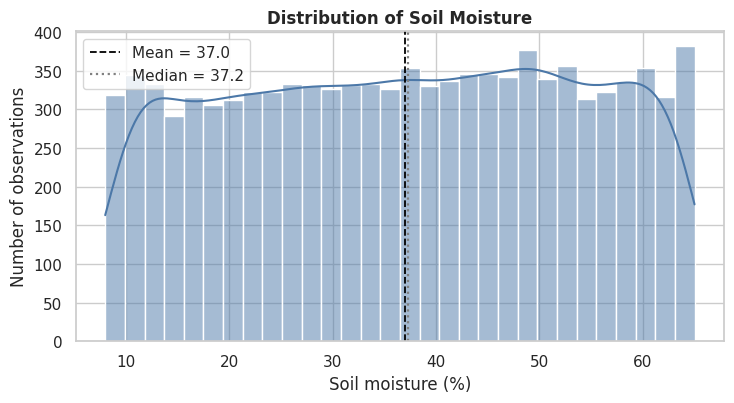

In [13]:
FEATURE_LABELS = {
    SOIL_COL: "Soil moisture (%)",
    TEMP_COL: "Temperature (°C)",
    HUM_COL: "Relative humidity (%)",
}
FEATURE_TITLES = {SOIL_COL: "Soil Moisture", TEMP_COL: "Temperature", HUM_COL: "Humidity"}
CLASS_COLORS = {"Low": "#4C9F70", "Medium": "#E9A23B", "High": "#C8443A"}

def plot_distribution(col, color):
    """Histogram + KDE + mean/median markers for one sensor variable."""
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    sns.histplot(df[col], bins=30, kde=True, color=color, ax=ax)
    ax.axvline(df[col].mean(), color="black", ls="--", lw=1.3, label=f"Mean = {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="grey", ls=":", lw=1.6, label=f"Median = {df[col].median():.1f}")
    ax.set_title(f"Distribution of {FEATURE_TITLES[col]}")
    ax.set_xlabel(FEATURE_LABELS[col]); ax.set_ylabel("Number of observations")
    ax.legend(); plt.tight_layout(); plt.show()

plot_distribution(SOIL_COL, "#4C78A8")

**Interpretation.** Soil moisture is spread almost **evenly** between 8 % and 65 % (mean ≈ 37 %, median ≈ 37 %), rather than bell-shaped. The histogram bars are roughly the same height, and there is no cluster of extreme values.

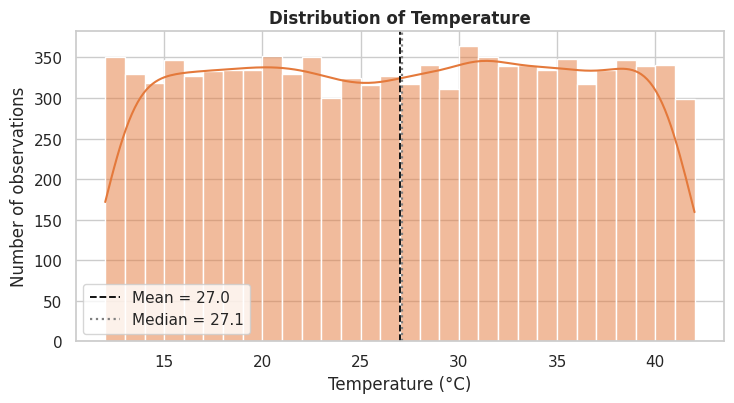

In [14]:
plot_distribution(TEMP_COL, "#E4793B")

**Interpretation.** Temperature is also spread roughly **evenly** between 12 °C and 42 °C (mean ≈ 27 °C, median ≈ 27 °C). No unusual spikes or gaps are visible.

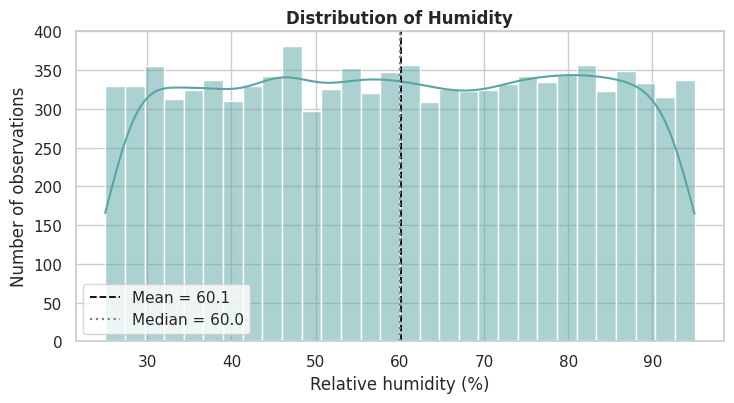

In [15]:
plot_distribution(HUM_COL, "#59A5A5")

**Interpretation.** Humidity is roughly **evenly** distributed between 25 % and 95 % (mean ≈ 60 %). All three sensor variables therefore cover their full range with similar density, which is convenient for training but unlike most real measurements, which usually cluster.

In [16]:
# Are the distributions flat? Compare counts in 10 equal-width bins.
flat = {c: np.histogram(df[c], bins=10)[0] for c in FEATURES}
for c, counts in flat.items():
    print(f"{c:14s} bin counts: {counts.tolist()}  (max/min = {counts.max()/counts.min():.2f})")
print()
print("Pairwise correlation between the three sensor variables:")
display(df[FEATURES].corr().round(3))

Soil_Moisture  bin counts: [997, 914, 958, 991, 990, 1020, 1034, 1072, 974, 1050]  (max/min = 1.17)
Temperature_C  bin counts: [998, 1007, 1021, 980, 968, 969, 1054, 1024, 999, 980]  (max/min = 1.09)
Humidity       bin counts: [1015, 974, 982, 1003, 1020, 992, 979, 1021, 1029, 985]  (max/min = 1.06)

Pairwise correlation between the three sensor variables:


,Soil_Moisture,Temperature_C,Humidity
Soil_Moisture,1.000,-0.005,0.007
Temperature_C,-0.005,1.000,-0.009
Humidity,0.007,-0.009,1.000


**Interpretation.** In 10 equal-width bins the largest bin is only 1.06–1.17 times the smallest, confirming near-uniform distributions. The three sensors are also essentially **uncorrelated** with each other (all |r| < 0.01), whereas in real fields temperature and humidity are normally related. This supports the note in Step 5 that the data looks simulated.

### 6.4 Correlation heatmap

The target is ordinal (Low < Medium < High), so it is encoded as 0/1/2 **only for this correlation plot** and Spearman (rank) correlation is used.

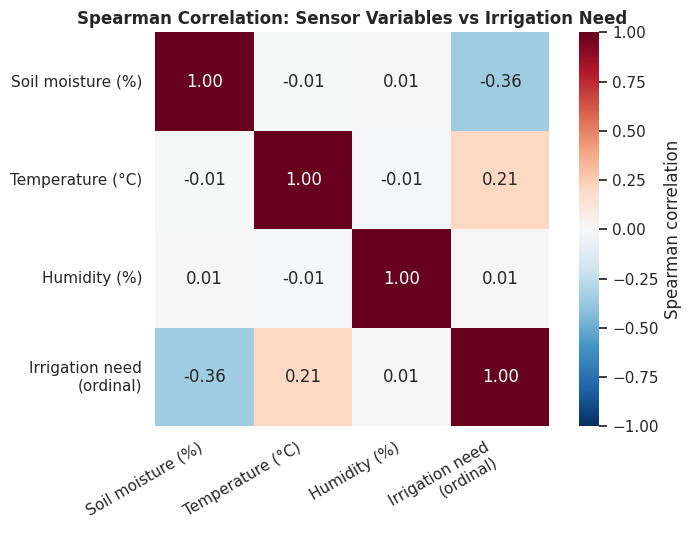

In [17]:
TARGET_ORDINAL = {label: i for i, label in enumerate(CLASS_ORDER)}   # Low=0, Medium=1, High=2
corr_frame = df[FEATURES].copy()
corr_frame["Irrigation_Need (Low=0, Med=1, High=2)"] = df[TARGET_COL].map(TARGET_ORDINAL)
corr = corr_frame.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Spearman Correlation: Sensor Variables vs Irrigation Need")
ax.set_xticklabels(["Soil moisture (%)", "Temperature (°C)", "Humidity (%)", "Irrigation need\n(ordinal)"], rotation=30, ha="right")
ax.set_yticklabels(["Soil moisture (%)", "Temperature (°C)", "Humidity (%)", "Irrigation need\n(ordinal)"], rotation=0)
plt.tight_layout(); plt.show()

**Interpretation.** Spearman correlations with the ordinal irrigation need are:
* **Soil moisture: −0.36** – drier soil goes with higher irrigation need (the strongest of the three).
* **Temperature: +0.21** – hotter conditions go with higher need.
* **Humidity: ≈ 0.00** – no monotonic relationship with irrigation need in this dataset.

The correlations are moderate at best, so no single sensor determines the class on its own. Correlation does not show causation.

### 6.5 Feature relationships with the irrigation requirement

Because the target has three categories, a plain scatter plot would place all points on three horizontal lines. To make the relationship readable:

1. **Jittered scatter plots** – each point is one observation, with small random vertical jitter so points do not overlap; the black diamonds are the class averages.
2. **Box plots** – show the spread of each sensor value within each class.
3. **Class share by value range** – for each range of a sensor value, what fraction of observations are Low / Medium / High.


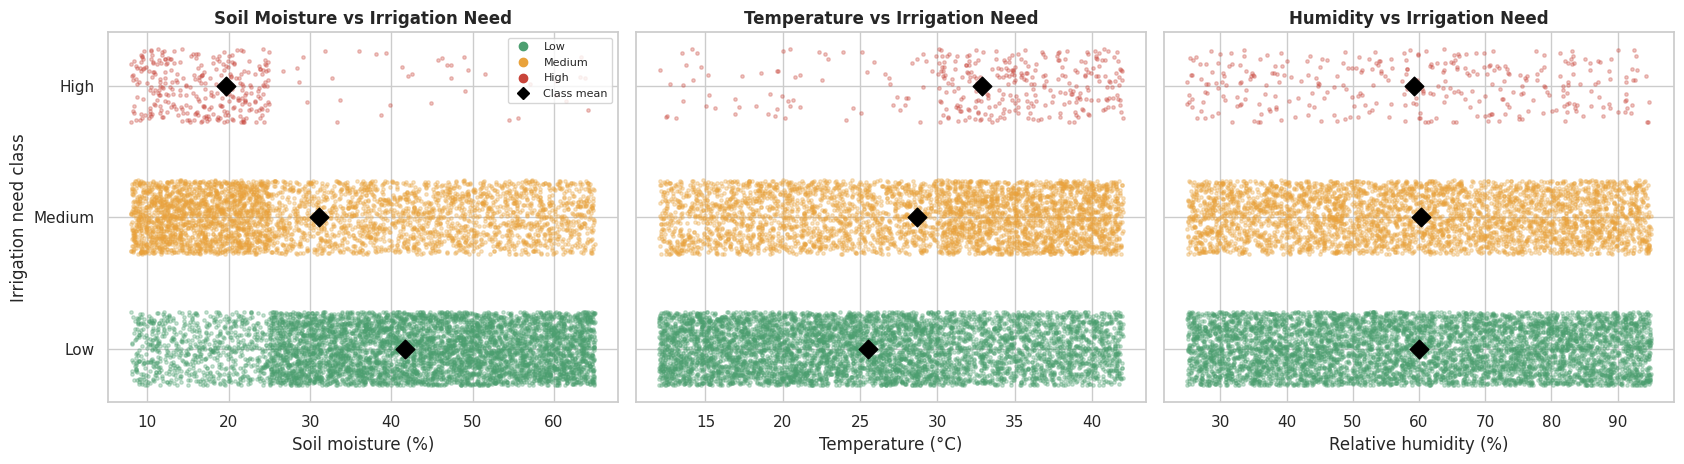

In [18]:
rng = np.random.default_rng(RANDOM_STATE)
y_num = df[TARGET_COL].map(TARGET_ORDINAL)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, col in zip(axes, FEATURES):
    for label in CLASS_ORDER:
        mask = df[TARGET_COL] == label
        ax.scatter(df.loc[mask, col], y_num[mask] + rng.uniform(-0.28, 0.28, mask.sum()),
                   s=6, alpha=0.30, color=CLASS_COLORS[label], label=label)
    means = df.groupby(TARGET_COL)[col].mean().reindex(CLASS_ORDER)
    ax.scatter(means.values, range(3), marker="D", s=90, color="black", zorder=5, label="Class mean")
    ax.set_title(f"{FEATURE_TITLES[col]} vs Irrigation Need")
    ax.set_xlabel(FEATURE_LABELS[col])
axes[0].set_ylabel("Irrigation need class")
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(CLASS_ORDER)
from matplotlib.lines import Line2D
handles = [Line2D([], [], marker="o", ls="", color=CLASS_COLORS[c], label=c) for c in CLASS_ORDER] +           [Line2D([], [], marker="D", ls="", color="black", label="Class mean")]
axes[0].legend(handles=handles, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.**
* **Soil moisture:** almost all *High* points lie below ≈ 25 %, and *Low* points become much denser above ≈ 25 %. There is a visible **threshold** near 25 %.
* **Temperature:** *High* points are concentrated above ≈ 30 °C.
* **Humidity:** all three classes are spread across the whole humidity range; the class averages (diamonds) sit at almost the same humidity.

The classes overlap heavily, especially *Medium* with the others, so three sensors alone will not separate them cleanly.

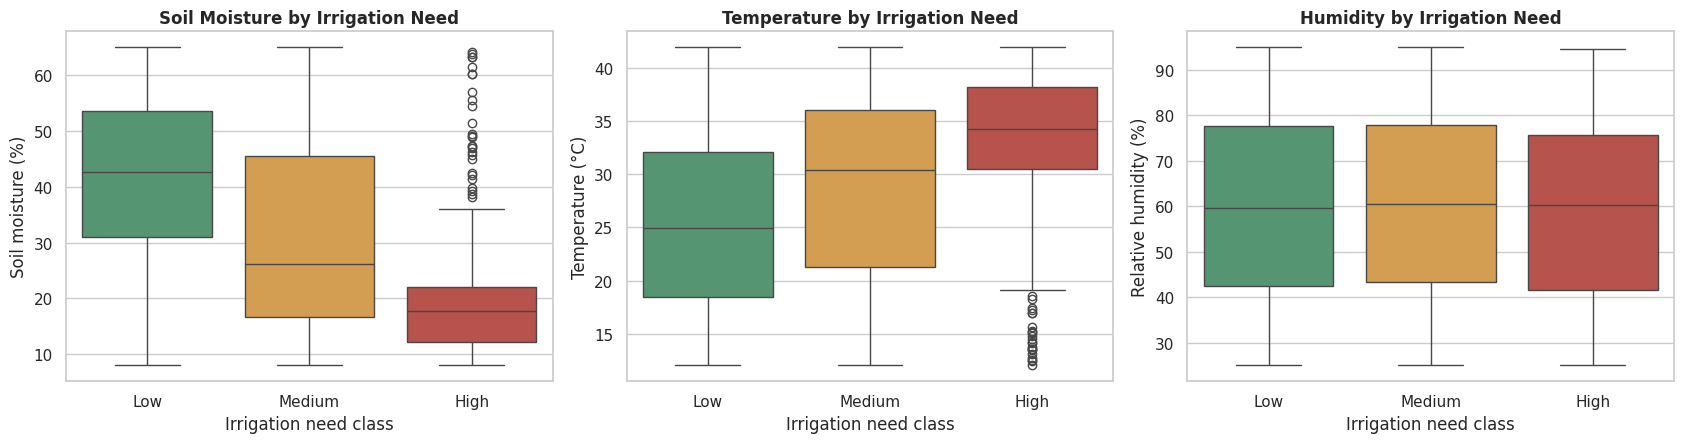

Mean of each sensor variable per class:


Soil_Moisture        Temperature_C       Humidity       
                         mean    std          mean   std     mean    std
Irrigation_Need                                                         
Low                     41.72  14.44         25.54  8.41    59.97  20.26
Medium                  31.16  16.83         28.71  8.64    60.32  20.09
High                    19.71  10.84         32.88  7.18    59.31  20.07

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, col in zip(axes, FEATURES):
    sns.boxplot(data=df, x=TARGET_COL, y=col, order=CLASS_ORDER, palette=CLASS_COLORS, ax=ax)
    ax.set_title(f"{FEATURE_TITLES[col]} by Irrigation Need")
    ax.set_xlabel("Irrigation need class"); ax.set_ylabel(FEATURE_LABELS[col])
plt.tight_layout(); plt.show()

print("Mean of each sensor variable per class:")
display(df.groupby(TARGET_COL)[FEATURES].agg(["mean", "std"]).reindex(CLASS_ORDER).round(2))

**Interpretation.** Median soil moisture falls from ≈ 43 % (Low) to ≈ 26 % (Medium) to ≈ 18 % (High), and median temperature rises from ≈ 25 °C to ≈ 30 °C to ≈ 34 °C. Humidity medians are almost identical in all three classes (≈ 60 %). The boxes for Low and Medium overlap substantially, which limits how well any model can separate them from these inputs.

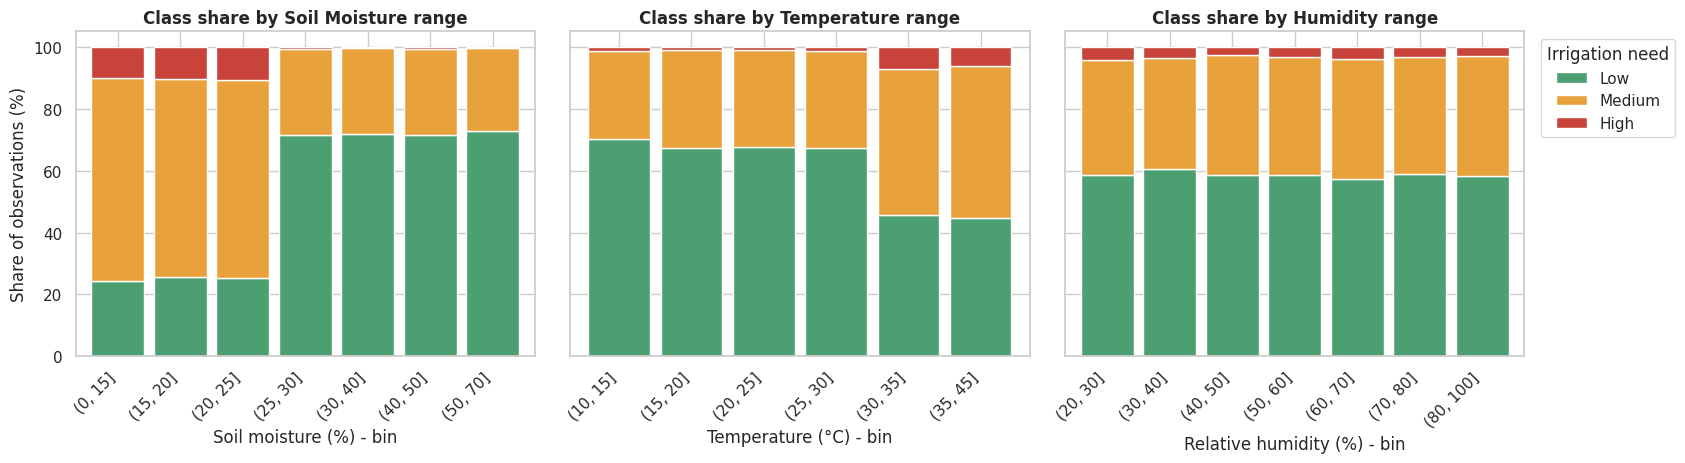

In [20]:
bin_edges = {SOIL_COL: [0, 15, 20, 25, 30, 40, 50, 70],
             TEMP_COL: [10, 15, 20, 25, 30, 35, 45],
             HUM_COL:  [20, 30, 40, 50, 60, 70, 80, 100]}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, col in zip(axes, FEATURES):
    bins = pd.cut(df[col], bins=bin_edges[col])
    share = pd.crosstab(bins, df[TARGET_COL], normalize="index")[CLASS_ORDER] * 100
    share.plot(kind="bar", stacked=True, ax=ax, color=[CLASS_COLORS[c] for c in CLASS_ORDER], width=0.85, legend=False)
    ax.set_title(f"Class share by {FEATURE_TITLES[col]} range")
    ax.set_xlabel(FEATURE_LABELS[col] + " - bin"); ax.set_xticklabels([str(i) for i in share.index], rotation=45, ha="right")
axes[0].set_ylabel("Share of observations (%)")
axes[-1].legend(CLASS_ORDER, title="Irrigation need", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

**Interpretation.**
* **Soil moisture:** below 25 %, about 64–65 % of observations are *Medium* and 10–11 % are *High*; above 25 %, about 71–73 % are *Low* and *High* almost disappears (≈ 0–1 %). The change happens sharply at about 25 %.
* **Temperature:** up to 30 °C, *High* is only ≈ 1 %; above 30 °C it rises to ≈ 6–7 % and *Low* drops from ≈ 67–70 % to ≈ 45 %.
* **Humidity:** the class shares stay nearly constant (Low ≈ 58–60 %, High ≈ 3–4 %) in every range – humidity carries little information about the target here.

## Step 7 — Geographic Visualization / Map

The dataset is searched for latitude/longitude or other location fields before deciding whether a map is possible.


In [21]:
geo_keywords = ["lat", "lon", "lng", "long", "gps", "coord", "location", "region", "city", "country", "farm", "district", "state"]
geo_cols = [c for c in df_raw.columns if any(k in c.lower() for k in geo_keywords)]
lat_cols = [c for c in df_raw.columns if c.lower() in ("lat", "latitude")]
lon_cols = [c for c in df_raw.columns if c.lower() in ("lon", "lng", "long", "longitude")]

print("Possible geographic columns:", geo_cols)
print("Latitude columns :", lat_cols, "| Longitude columns:", lon_cols)
HAS_COORDINATES = bool(lat_cols and lon_cols)
print("Coordinates available:", HAS_COORDINATES)
for c in geo_cols:
    print(f"  {c}: {df_raw[c].value_counts().to_dict()}")

Possible geographic columns: ['Region']
Latitude columns : [] | Longitude columns: []
Coordinates available: False
  Region: {'South': 2102, 'West': 2017, 'East': 1994, 'Central': 1987, 'North': 1900}


> **The dataset does not contain geographic coordinates, so a meaningful observation-level map cannot be generated from this dataset.**

It does contain a coarse categorical `Region` column (North / South / East / West / Central) but no shapes, names of real places or GPS points, so no coordinates are invented. As the closest honest alternative, the chart below summarises irrigation need **by region** (a bar chart, not a map). `Region` is **not** used as a model feature.

**How location could be added in the IoT deployment:** each field node could carry a GPS module (or a fixed, surveyed latitude/longitude stored in the node's configuration) and send it along with each reading. With coordinates and real sensor data, a `folium` map of fields coloured by predicted irrigation need would be straightforward, and location could later support weather-forecast look-ups.


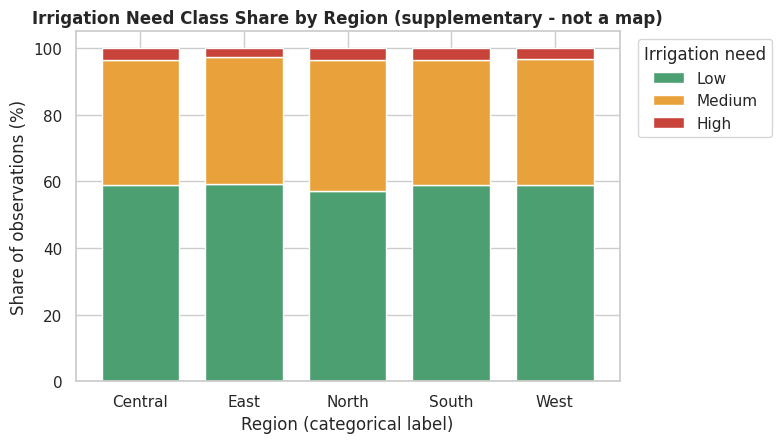

Irrigation_Need,Low,Medium,High
Region,,,
Central,59.0,37.4,3.5
East,59.1,38.2,2.7
North,57.1,39.3,3.6
South,58.9,37.5,3.5
West,59.0,37.6,3.4


In [22]:
region_share = pd.crosstab(df["Region"], df[TARGET_COL], normalize="index")[CLASS_ORDER] * 100
ax = region_share.plot(kind="bar", stacked=True, figsize=(8, 4.6), color=[CLASS_COLORS[c] for c in CLASS_ORDER], width=0.75)
ax.set_title("Irrigation Need Class Share by Region (supplementary - not a map)")
ax.set_xlabel("Region (categorical label)"); ax.set_ylabel("Share of observations (%)")
ax.legend(title="Irrigation need", bbox_to_anchor=(1.02, 1), loc="upper left"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()
display(region_share.round(1))

**Interpretation.** Class shares are nearly the same in all five regions (Low ≈ 57–59 %, Medium ≈ 37–39 %, High ≈ 2.7–3.6 %), so `Region` shows no meaningful difference in irrigation need here.

## Step 8 — Define Features and Target

* **`X`** – the *input matrix*: one row per observation, three columns (soil moisture, temperature, humidity). This is what the physical sensors will supply.
* **`y`** – the *target vector*: the irrigation-need label the model must learn to predict. It is the dataset's own `Irrigation_Need` column with the classes **Low, Medium, High**.

**Why these three inputs?** They are the measurements that a low-cost IoT node can realistically provide (a capacitive soil-moisture probe and a DHT-type temperature/humidity sensor), which is the constraint of the final system. Other columns in the dataset (crop type, growth stage, region, rainfall, soil pH …) would need extra data entry, weather feeds or laboratory tests, so they are intentionally excluded.


### Original dataset target vs derived pump decision

Two different things are used in this project and must not be confused:

| | **Original dataset target** | **Derived pump decision** |
|---|---|---|
| Column / name | `Irrigation_Need` | `IRRIGATION_POLICY` applied to a prediction |
| Values | **Low, Medium, High** | Irrigation Not Needed / Irrigation Needed |
| Source | Supplied in the dataset | **Assumption made in this project** |
| Used for | Training, tuning and evaluating the model | Turning a prediction into a pump recommendation |

**Assumption (not from the dataset):** *Low → Not Needed*; *Medium and High → Needed*. The dataset does not state which levels should start the pump, so this rule must be confirmed with an agronomist and can be edited in one place (`IRRIGATION_POLICY`, Step 14.1). The model itself is always trained on the original three classes.

**Model inputs.** Only the three sensor features (`Soil_Moisture`, `Temperature_C`, `Humidity`) are used by the project model. The one exception is the clearly labelled diagnostic in Step 15.1, which trains a separate reference model on all columns purely to measure what the three-sensor restriction costs; it is never used for selection, prediction or deployment.


In [23]:
X = df[FEATURES].copy()
y = df[TARGET_COL].copy()
print("X shape:", X.shape, "| y shape:", y.shape)
print("Feature order:", list(X.columns))
display(X.head(3))
print("Target classes:", CLASS_ORDER, "(Low = little/no irrigation needed, High = urgent irrigation need)")

X shape: (10000, 3) | y shape: (10000,)
Feature order: ['Soil_Moisture', 'Temperature_C', 'Humidity']


,Soil_Moisture,Temperature_C,Humidity
0,36.48,21.90,31.19
1,50.56,36.50,26.01
2,40.07,41.83,76.41


Target classes: ['Low', 'Medium', 'High'] (Low = little/no irrigation needed, High = urgent irrigation need)


## Step 9 — Check Target Distribution

,count,percent
Irrigation_Need,,
Low,5864,58.64
Medium,3800,38.00
High,336,3.36


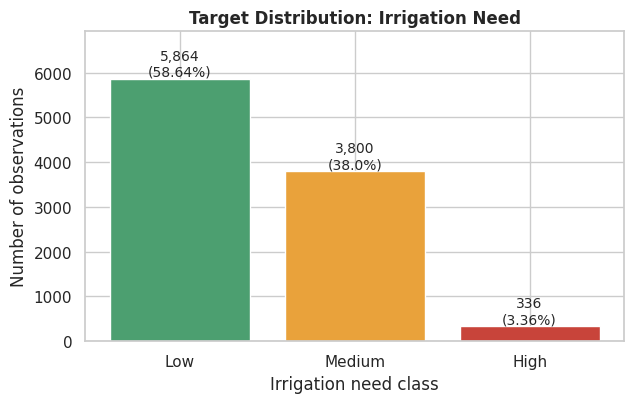

Imbalance ratio (largest / smallest class): 17.5 : 1


In [24]:
class_counts = y.value_counts().reindex(CLASS_ORDER)
class_pct = (class_counts / class_counts.sum() * 100).round(2)
display(pd.DataFrame({"count": class_counts, "percent": class_pct}))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(CLASS_ORDER, class_counts.values, color=[CLASS_COLORS[c] for c in CLASS_ORDER])
for bar, pct in zip(bars, class_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60, f"{int(bar.get_height()):,}\n({pct}%)", ha="center", fontsize=10)
ax.set_title("Target Distribution: Irrigation Need"); ax.set_xlabel("Irrigation need class")
ax.set_ylabel("Number of observations"); ax.set_ylim(0, class_counts.max() * 1.18)
plt.tight_layout(); plt.show()
print(f"Imbalance ratio (largest / smallest class): {class_counts.max() / class_counts.min():.1f} : 1")

**Interpretation.** The dataset is **not balanced**: *Low* is 58.6 %, *Medium* 38.0 % and *High* only 3.4 % (336 rows; 67 in the test set), a ratio of about 17.5 : 1.

**Effect on evaluation.** A model that always answers "Low" would already reach ≈ 58.6 % accuracy, so **accuracy alone is misleading**. Accuracy can look acceptable while the rare *High* class – the one where under-irrigation is most damaging – is never detected. Per-class recall, precision and macro-averaged scores are therefore reported. Because rows were not resampled, the test set keeps the real class proportions. Instead of oversampling/undersampling, the `class_weight="balanced"` option is tested as a lighter-touch remedy (Step 12), since missing *High* cases matters for this application.

## Step 10 — Prepare the Data (Train / Test Split)

The data is split into a **training set** (80 %), used to fit and tune the models, and a **test set** (20 %), which stays **unseen** until the final evaluation. The test set mimics future, never-seen sensor readings: if the model were evaluated on the data it learned from, accuracy would be overly optimistic and we could not detect overfitting.

`stratify=y` keeps the Low/Medium/High proportions identical in both parts — essential here because the *High* class is rare.


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"Training set: {X_train.shape[0]:,} rows | Test set: {X_test.shape[0]:,} rows")
split_check = pd.DataFrame({
    "train_%": (y_train.value_counts(normalize=True).reindex(CLASS_ORDER) * 100).round(2),
    "test_%":  (y_test.value_counts(normalize=True).reindex(CLASS_ORDER) * 100).round(2),
    "train_n": y_train.value_counts().reindex(CLASS_ORDER),
    "test_n":  y_test.value_counts().reindex(CLASS_ORDER)})
display(split_check)

Training set: 8,000 rows | Test set: 2,000 rows


,train_%,test_%,train_n,test_n
Irrigation_Need,,,,
Low,58.64,58.65,4691,1173
Medium,38.00,38.00,3040,760
High,3.36,3.35,269,67


## Step 11 — Feature Scaling

**What scaling does.** `StandardScaler` transforms each feature to mean 0 and standard deviation 1 (`z = (x − mean) / std`), so soil moisture (8–65), temperature (12–42) and humidity (25–95) are on comparable scales.

**Is it necessary?** It depends on the model:

| Model | Needs scaling? | Why |
|---|---|---|
| Logistic Regression | **Yes (helps)** | Uses gradient-based optimisation and regularisation, both sensitive to feature scale; also makes coefficients comparable. |
| Decision Tree / Random Forest | No | Splits are threshold comparisons on a single feature; monotonic rescaling does not change them. |

**Avoiding data leakage.** The scaler's mean and standard deviation must be learned from the **training data only**. If they were computed on the full dataset, information about the test set would leak into training. Wrapping scaler + model in a scikit-learn **`Pipeline`** guarantees this: the scaler is fitted on the training part only (including inside each cross-validation fold) and re-applied unchanged to any new data. Tree models use `"passthrough"` in the scaler slot so every candidate has the same pipeline structure.


In [26]:
def build_pipeline(model, scale):
    """Scaler (or passthrough) + model in one object -> no leakage, one object to deploy."""
    return Pipeline([("scaler", StandardScaler() if scale else "passthrough"),
                     ("clf", model)])

# Quick demonstration that the scaler learns from the training data only
demo_scaler = StandardScaler().fit(X_train)
print("Scaler means learned from TRAINING data:", dict(zip(FEATURES, demo_scaler.mean_.round(2))))
print("Scaler std devs learned from TRAINING data:", dict(zip(FEATURES, demo_scaler.scale_.round(2))))

Scaler means learned from TRAINING data: {'Soil_Moisture': np.float64(37.14), 'Temperature_C': np.float64(27.02), 'Humidity': np.float64(60.24)}
Scaler std devs learned from TRAINING data: {'Soil_Moisture': np.float64(16.45), 'Temperature_C': np.float64(8.63), 'Humidity': np.float64(20.14)}


## Step 12 — Train Multiple Candidate Models

Three model families are compared. This is a small tabular problem (3 features, 10,000 rows), so deep learning would be unjustified.

* **Logistic Regression** – a simple, fast, interpretable baseline. It learns a weighted sum of the scaled sensor values and converts it to class probabilities. It can only draw *linear* class boundaries.
* **Decision Tree** – learns a set of `if soil_moisture < x …` rules from the sensor values. Easy to read and to run on a microcontroller, but a deep tree can overfit.
* **Random Forest** – averages many decision trees trained on random subsets of the data. Captures non-linear relationships and is usually more stable than one tree, but is larger and harder to explain.

**Handling the imbalanced *High* class.** *High* is only a few percent of the data (Step 9). Each family is therefore trained twice: normally, and with `class_weight="balanced"`, which penalises mistakes on rare classes more heavily. This changes the model, not the data (no oversampling / undersampling).

**Tuning without touching the test set.** Hyper-parameters are chosen with 5-fold stratified cross-validation on the **training set only**, using **macro-F1** (the average F1 of the three classes, so the rare *High* class counts as much as the common *Low* class) as the tuning score.


In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidate_specs = {
    "Logistic Regression": dict(
        pipe=build_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), scale=True),
        grid={"clf__C": [0.01, 0.1, 1, 10, 100]}),
    "Logistic Regression (balanced)": dict(
        pipe=build_pipeline(LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE), scale=True),
        grid={"clf__C": [0.01, 0.1, 1, 10, 100]}),
    "Decision Tree": dict(
        pipe=build_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE), scale=False),
        grid={"clf__max_depth": [2, 3, 4, 5, 6, 8, 10], "clf__min_samples_leaf": [5, 20, 50]}),
    "Decision Tree (balanced)": dict(
        pipe=build_pipeline(DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE), scale=False),
        grid={"clf__max_depth": [2, 3, 4, 5, 6, 8, 10], "clf__min_samples_leaf": [5, 20, 50]}),
    "Random Forest": dict(
        pipe=build_pipeline(RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=1), scale=False),
        grid={"clf__max_depth": [4, 6, 8], "clf__min_samples_leaf": [10, 30], "clf__max_features": [1, 2]}),
    "Random Forest (balanced)": dict(
        pipe=build_pipeline(RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1), scale=False),
        grid={"clf__max_depth": [4, 6, 8], "clf__min_samples_leaf": [10, 30], "clf__max_features": [1, 2]}),
}

fitted_models, best_params = {}, {}
for name, spec in candidate_specs.items():
    search = GridSearchCV(spec["pipe"], spec["grid"], scoring="f1_macro", cv=cv, n_jobs=1, refit=True)
    search.fit(X_train, y_train)                       # TRAINING DATA ONLY
    fitted_models[name] = search.best_estimator_
    best_params[name] = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    print(f"{name:34s} best CV macro-F1 = {search.best_score_:.4f}  params = {best_params[name]}")

Logistic Regression                best CV macro-F1 = 0.4320  params = {'C': 0.1}


Logistic Regression (balanced)     best CV macro-F1 = 0.4315  params = {'C': 1}


Decision Tree                      best CV macro-F1 = 0.4639  params = {'max_depth': 4, 'min_samples_leaf': 5}


Decision Tree (balanced)           best CV macro-F1 = 0.5114  params = {'max_depth': 2, 'min_samples_leaf': 5}


Random Forest                      best CV macro-F1 = 0.4492  params = {'max_depth': 8, 'max_features': 2, 'min_samples_leaf': 30}


Random Forest (balanced)           best CV macro-F1 = 0.5095  params = {'max_depth': 6, 'max_features': 1, 'min_samples_leaf': 10}


## Step 13 — Evaluate the Models

**Metrics** (computed on the unseen test set):

* **Accuracy** – share of all predictions that are correct. Can hide poor performance on a rare class.
* **Precision** – of the observations predicted as a class, how many truly belong to it.
* **Recall** – of the observations that truly belong to a class, how many the model found.
* **F1-score** – harmonic mean of precision and recall.
* **Macro** averages weight the three classes equally.

**Why recall matters most for irrigation.** A missed genuine irrigation requirement (a false negative) means the crop is **under-irrigated**: the model says “Low/Medium” when the field really needs “High”. This is the costlier error for crop health. A false alarm (unnecessary irrigation) mainly wastes water and energy. Recall of the **High** class is therefore examined closely, but never in isolation, because a model that predicts “High” for everything would have perfect High-recall and be useless.


In [28]:
def summarize(y_true, y_pred):
    """Overall + per-class metrics for the 3-class problem."""
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=CLASS_ORDER, zero_division=0)
    out = {"accuracy": accuracy_score(y_true, y_pred),
           "macro_precision": p.mean(), "macro_recall": r.mean(), "macro_f1": f.mean()}
    for i, label in enumerate(CLASS_ORDER):
        out[f"precision_{label}"], out[f"recall_{label}"], out[f"f1_{label}"] = p[i], r[i], f[i]
    return out

test_predictions = {name: model.predict(X_test) for name, model in fitted_models.items()}
test_results = pd.DataFrame({name: summarize(y_test, pred) for name, pred in test_predictions.items()}).T
display(test_results[["accuracy", "macro_precision", "macro_recall", "macro_f1",
                      "precision_High", "recall_High", "f1_High"]].round(3))

,accuracy,macro_precision,macro_recall,macro_f1,precision_High,recall_High,f1_High
Logistic Regression,0.662,0.426,0.434,0.428,0.000,0.000,0.000
Logistic Regression (balanced),0.512,0.421,0.551,0.407,0.109,0.716,0.190
Decision Tree,0.695,0.519,0.457,0.455,0.200,0.015,0.028
Decision Tree (balanced),0.578,0.484,0.595,0.489,0.177,0.642,0.277
Random Forest,0.698,0.453,0.456,0.450,0.000,0.000,0.000
Random Forest (balanced),0.590,0.477,0.589,0.489,0.174,0.627,0.272


In [29]:
print("Per-class precision / recall / F1 on the test set")
per_class = test_results[[f"{m}_{c}" for c in CLASS_ORDER for m in ("precision", "recall", "f1")]].round(3)
per_class.columns = pd.MultiIndex.from_product([CLASS_ORDER, ["precision", "recall", "f1"]])
display(per_class)

Per-class precision / recall / F1 on the test set


Low                  Medium                    High              
                               precision recall     f1 precision recall     f1 precision recall     f1
Logistic Regression                0.704  0.808  0.753     0.573  0.493  0.530     0.000  0.000  0.000
Logistic Regression (balanced)     0.747  0.641  0.690     0.406  0.296  0.342     0.109  0.716  0.190
Decision Tree                      0.721  0.870  0.788     0.637  0.484  0.550     0.200  0.015  0.028
Decision Tree (balanced)           0.807  0.591  0.682     0.468  0.553  0.507     0.177  0.642  0.277
Random Forest                      0.725  0.863  0.788     0.635  0.505  0.563     0.000  0.000  0.000
Random Forest (balanced)           0.778  0.655  0.711     0.480  0.487  0.483     0.174  0.627  0.272

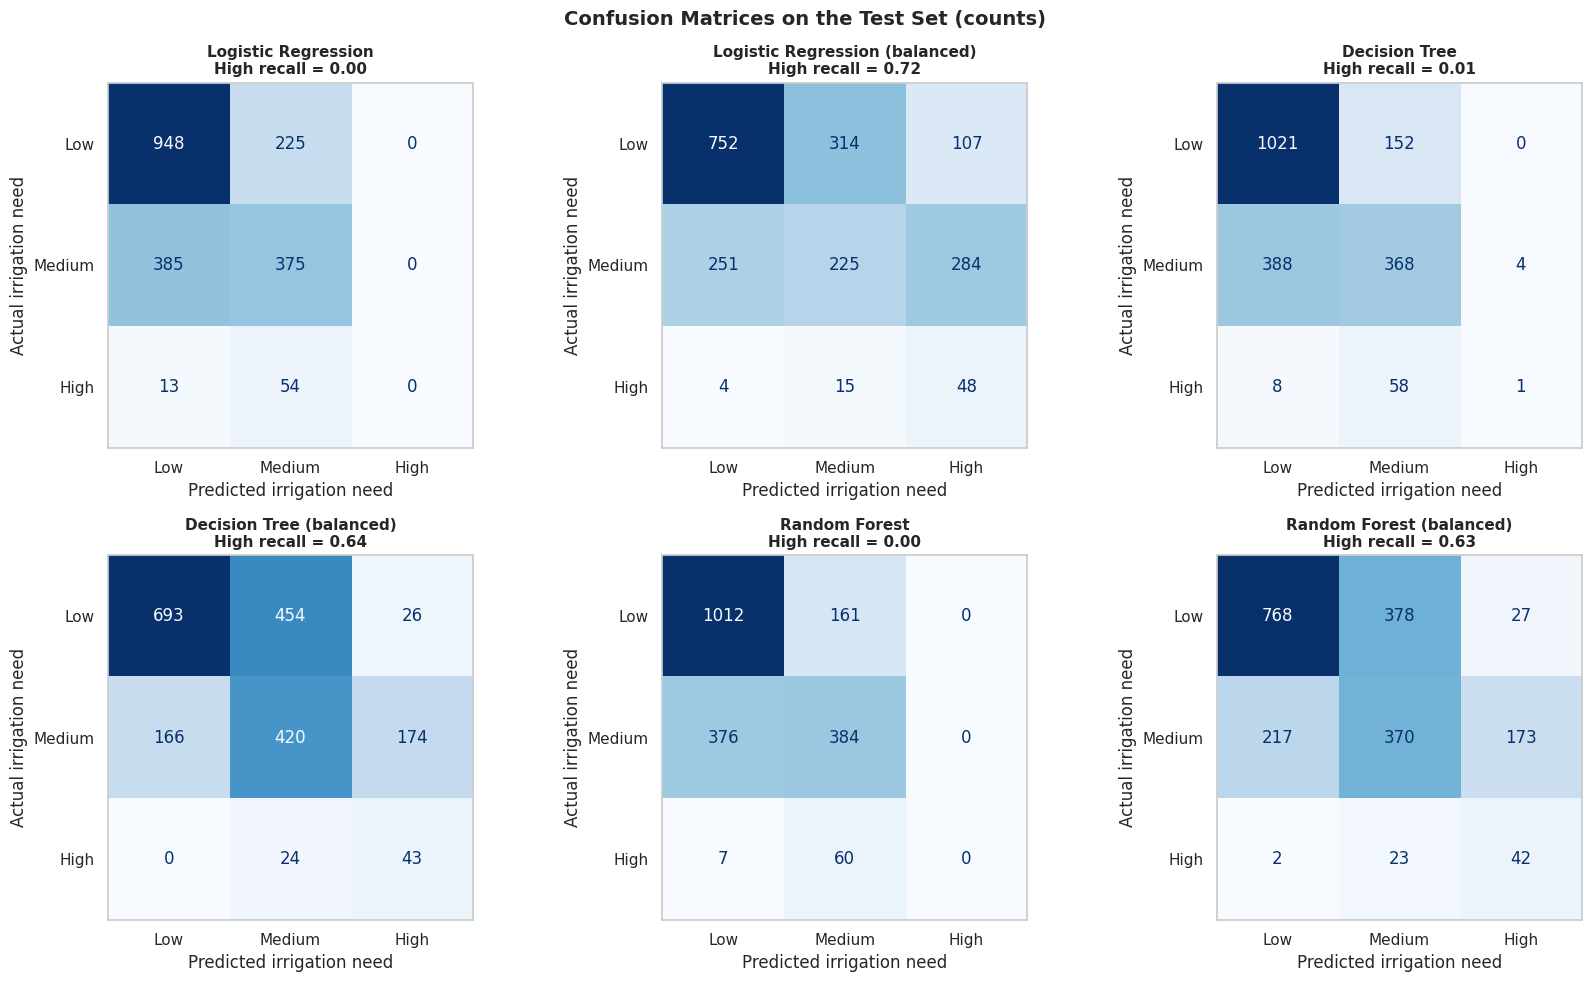

In [30]:
# Confusion matrices for all candidates (rows = actual, columns = predicted)
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (name, pred) in zip(axes.ravel(), test_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASS_ORDER, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name}\nHigh recall = {test_results.loc[name, 'recall_High']:.2f}", fontsize=11)
    ax.set_xlabel("Predicted irrigation need"); ax.set_ylabel("Actual irrigation need"); ax.grid(False)
plt.suptitle("Confusion Matrices on the Test Set (counts)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

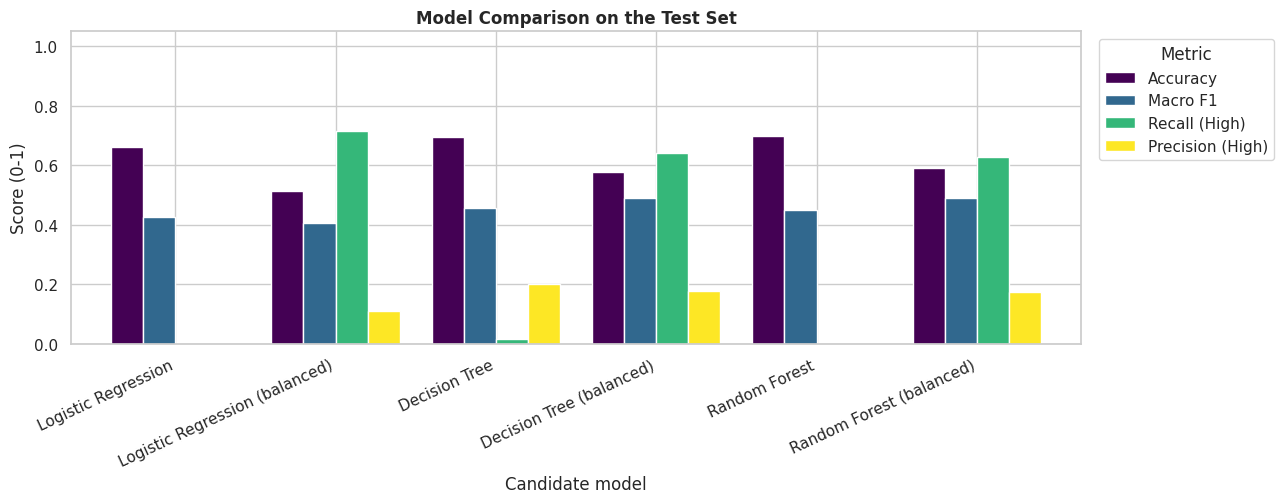

In [31]:
# Model comparison chart
plot_cols = {"accuracy": "Accuracy", "macro_f1": "Macro F1", "recall_High": "Recall (High)", "precision_High": "Precision (High)"}
comparison = test_results[list(plot_cols)].rename(columns=plot_cols)
ax = comparison.plot(kind="bar", figsize=(13, 5.2), width=0.8, colormap="viridis")
ax.set_title("Model Comparison on the Test Set"); ax.set_xlabel("Candidate model"); ax.set_ylabel("Score (0-1)")
ax.set_ylim(0, 1.05); plt.xticks(rotation=25, ha="right"); ax.legend(title="Metric", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

**Interpretation of the test-set results.**

* **Models without class weights** reach the highest accuracy (66–70 %), but they almost **never detect the High class**: recall for *High* is 0.00 for Logistic Regression and Random Forest, and 0.015 for the Decision Tree. Their accuracy is only slightly above the 58.7 % "always Low" baseline.
* **Models with `class_weight="balanced"`** find most *High* cases (recall 0.63–0.72), but at a cost: precision for *High* is only 0.11–0.18 (many false alarms), and overall accuracy falls to 51–59 %.
* Among the balanced models, the **Decision Tree and Random Forest are nearly equal** (macro-F1 0.489 vs 0.489; High recall 0.64 vs 0.63). Balanced Logistic Regression has the highest High recall (0.72) but the lowest macro-F1 and accuracy (0.407 and 0.51).
* No model performs strongly. The best macro-F1 is ≈ 0.49 on a 3-class task, which is a **modest** result. The reason is examined in Step 15.1.

This is a genuine trade-off between catching under-irrigation risk (recall) and avoiding unnecessary alerts (precision), not a problem with one model in particular.

## Step 14 — Select the Final Model

The final model is chosen **without looking at the test set**, using out-of-fold predictions on the **training set** (each training row is predicted by a model that did not see it). The test-set numbers above are only used afterwards, to confirm the choice.

**Selection rule (fixed before looking at the result):**
1. Keep every candidate whose cross-validated **macro-F1** is within **0.01** of the best one (differences that small are within noise).
2. Among those, choose the one with the highest cross-validated **recall for the High class** (under-irrigation risk).
3. If still tied, prefer the simpler / more interpretable model (Logistic Regression < Decision Tree < Random Forest).

Interpretability and deployment simplicity are then discussed in the text below the table.


In [32]:
cv_predictions = {name: cross_val_predict(model, X_train, y_train, cv=cv, n_jobs=1)
                  for name, model in fitted_models.items()}
cv_results = pd.DataFrame({name: summarize(y_train, pred) for name, pred in cv_predictions.items()}).T
cv_view = cv_results[["accuracy", "macro_f1", "precision_High", "recall_High", "f1_High", "recall_Medium", "recall_Low"]].round(3)
display(cv_view.sort_values("macro_f1", ascending=False))

# --- apply the pre-declared selection rule -----------------------------------
complexity_rank = {"Logistic Regression": 1, "Decision Tree": 2, "Random Forest": 3}
family = lambda n: n.replace(" (balanced)", "")
best_f1 = cv_results["macro_f1"].max()
shortlist = cv_results[cv_results["macro_f1"] >= best_f1 - 0.01].copy()
shortlist["complexity"] = [complexity_rank[family(n)] for n in shortlist.index]
shortlist = shortlist.sort_values(["recall_High", "complexity"], ascending=[False, True])
FINAL_NAME = shortlist.index[0]
final_pipeline = fitted_models[FINAL_NAME]

print("Shortlist (CV macro-F1 within 0.01 of the best):")
display(shortlist[["macro_f1", "recall_High", "complexity"]].round(3))
print(f"\nSELECTED FINAL MODEL: {FINAL_NAME}   |   parameters: {best_params[FINAL_NAME]}")

,accuracy,macro_f1,precision_High,recall_High,f1_High,recall_Medium,recall_Low
Decision Tree (balanced),0.596,0.511,0.200,0.699,0.311,0.584,0.598
Random Forest (balanced),0.604,0.510,0.195,0.695,0.305,0.516,0.656
Decision Tree,0.698,0.464,0.333,0.026,0.048,0.484,0.876
Random Forest,0.699,0.449,0.000,0.000,0.000,0.493,0.872
Logistic Regression (balanced),0.536,0.432,0.126,0.773,0.217,0.326,0.659
Logistic Regression,0.670,0.432,0.000,0.000,0.000,0.489,0.826


Shortlist (CV macro-F1 within 0.01 of the best):


,macro_f1,recall_High,complexity
Decision Tree (balanced),0.511,0.699,2
Random Forest (balanced),0.510,0.695,3



SELECTED FINAL MODEL: Decision Tree (balanced)   |   parameters: {'max_depth': 2, 'min_samples_leaf': 5}


Final model: Decision Tree (balanced)

              precision    recall  f1-score   support

         Low      0.807     0.591     0.682      1173
      Medium      0.468     0.553     0.507       760
        High      0.177     0.642     0.277        67

    accuracy                          0.578      2000
   macro avg      0.484     0.595     0.489      2000
weighted avg      0.657     0.578     0.602      2000



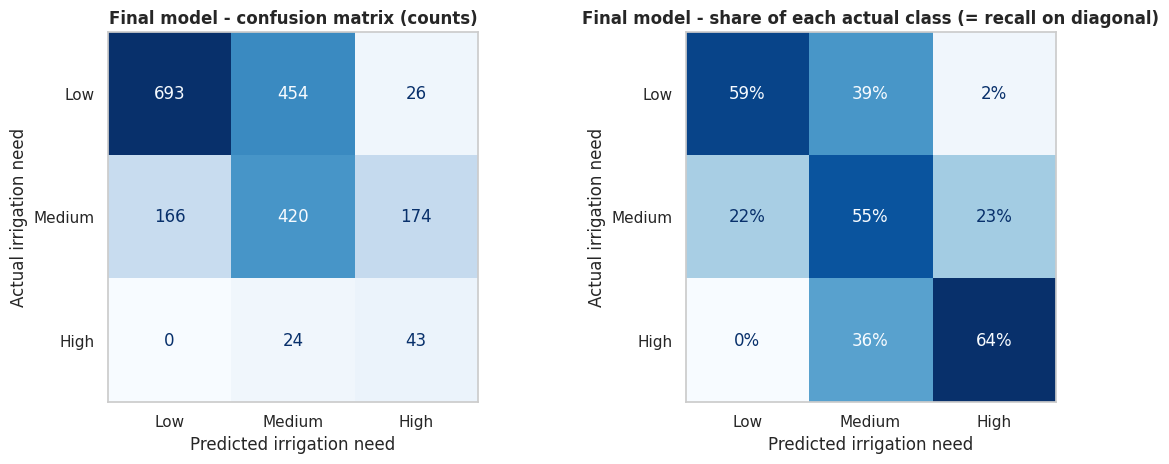

Trivial baseline (always predict 'Low') accuracy: 0.587
Final model accuracy: 0.578


In [33]:
# One-time confirmation on the untouched test set
final_test_pred = final_pipeline.predict(X_test)
print(f"Final model: {FINAL_NAME}\n")
print(classification_report(y_test, final_test_pred, labels=CLASS_ORDER, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ConfusionMatrixDisplay.from_predictions(y_test, final_test_pred, labels=CLASS_ORDER, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Final model - confusion matrix (counts)"); axes[0].grid(False)
ConfusionMatrixDisplay.from_predictions(y_test, final_test_pred, labels=CLASS_ORDER, normalize="true", values_format=".0%",
                                        cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Final model - share of each actual class (= recall on diagonal)"); axes[1].grid(False)
for ax in axes: ax.set_xlabel("Predicted irrigation need"); ax.set_ylabel("Actual irrigation need")
plt.tight_layout(); plt.show()

# Test-set score of the final model vs. a trivial baseline
majority_baseline = (y_test == y_train.mode()[0]).mean()
print(f"Trivial baseline (always predict '{y_train.mode()[0]}') accuracy: {majority_baseline:.3f}")
print(f"Final model accuracy: {accuracy_score(y_test, final_test_pred):.3f}")

**Why this model was selected.**

* In cross-validation on the training set, the balanced Decision Tree and balanced Random Forest are effectively tied (macro-F1 0.511 vs 0.510; High recall 0.699 vs 0.695). Both are clearly ahead of the other four models on cross-validated macro-F1 (0.43–0.46).
* Because the two are within noise of each other, the pre-declared rule falls to simplicity: the selected **Decision Tree (balanced, max depth 2)** is a rule set of four leaves that can be read by a person and even written as a few `if` statements on a microcontroller, whereas the Random Forest needs 150 trees.
* **Test-set confirmation (used once):** accuracy 0.578, macro-F1 0.489, *High* recall 0.642 (≈ 43 of 67 High observations found), *High* precision 0.177, *Medium* recall 0.553, *Low* recall 0.591.

**Honest caveats.**
* The final accuracy (0.578) is **not higher than the trivial "always Low" baseline (0.587)**. The model is chosen for what it does for the *High* and *Medium* classes, not for accuracy.
* Only ≈ 18 % of *High* alerts are correct, so this model should be viewed as a **screening tool**, not a precise classifier.
* Test-set results for the other models were not used to choose between models.

### 14.1 Pump decision view (derived from the 3-class prediction)

The pump needs a yes/no decision. The dataset does not say which levels should trigger irrigation, so this is an **explicit design assumption**, defined once and editable:

| Predicted level | Pump recommendation (default) |
|---|---|
| Low | Irrigation Not Needed |
| Medium | Irrigation Needed |
| High | Irrigation Needed |

Change `IRRIGATION_POLICY` if the agronomist decides that only *High* should start the pump.


In [34]:
IRRIGATION_POLICY = {"Low": "Irrigation Not Needed", "Medium": "Irrigation Needed", "High": "Irrigation Needed"}

y_test_binary = y_test.map(IRRIGATION_POLICY)
pred_binary = pd.Series(final_test_pred, index=y_test.index).map(IRRIGATION_POLICY)
print("Pump-decision performance of the final model (test set):")
print(classification_report(y_test_binary, pred_binary, digits=3, zero_division=0))
binary_cm = confusion_matrix(y_test_binary, pred_binary, labels=["Irrigation Not Needed", "Irrigation Needed"])
display(pd.DataFrame(binary_cm, index=["Actual: Not Needed", "Actual: Needed"], columns=["Pred: Not Needed", "Pred: Needed"]))
binary_metrics = classification_report(y_test_binary, pred_binary, output_dict=True, zero_division=0)["Irrigation Needed"]

Pump-decision performance of the final model (test set):
                       precision    recall  f1-score   support

    Irrigation Needed      0.579     0.799     0.672       827
Irrigation Not Needed      0.807     0.591     0.682      1173

             accuracy                          0.677      2000
            macro avg      0.693     0.695     0.677      2000
         weighted avg      0.713     0.677     0.678      2000



,Pred: Not Needed,Pred: Needed
Actual: Not Needed,693,480
Actual: Needed,166,661


**Interpretation (pump decision under the default policy).** With *Medium* and *High* both triggering irrigation, the model recommends irrigation for **79.9 %** of the fields that truly needed it (recall 0.799), missing 166 of 827. When it recommends irrigation it is right 57.9 % of the time; it triggers 480 unnecessary irrigations among 1,173 fields that did not need it. So the model leans toward **over-irrigating rather than under-irrigating**, which fits the aim of avoiding under-irrigation, but wastes water. If the policy is changed (for example, only *High* starts the pump) these numbers will change and should be re-evaluated.

## Step 15 — Feature Importance / Model Interpretation

Two complementary views are used:

1. **Model-internal importance** – coefficients for Logistic Regression, or impurity-based `feature_importances_` for tree models.
2. **Permutation importance** (model-agnostic) – shuffle one feature at a time on the test set and measure how much macro-F1 drops. A big drop means the model relies on that feature.

**Caution:** importance describes what *this model* uses to separate the classes in *this dataset*. It does **not** prove that a variable *causes* irrigation need.


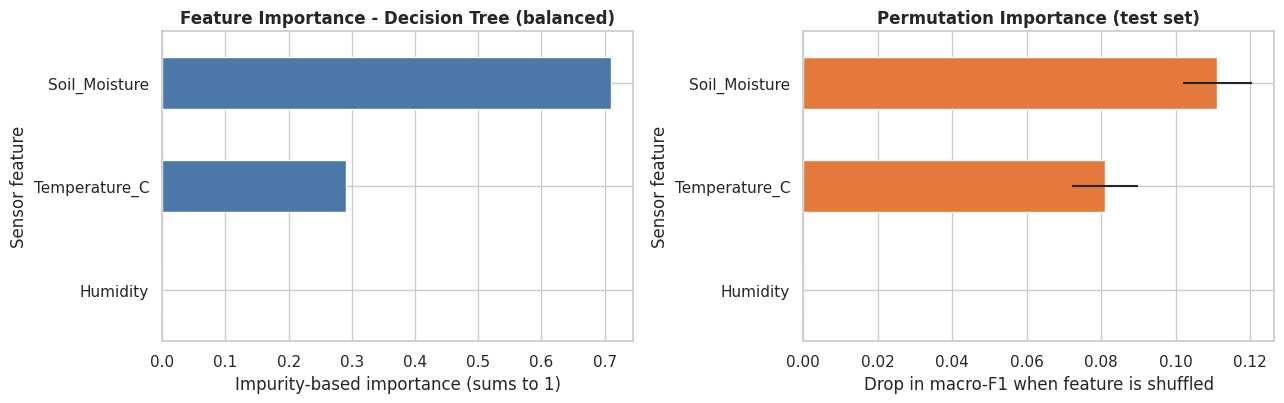

,model_importance,permutation_drop_in_macroF1
Soil_Moisture,0.7094,0.1112
Temperature_C,0.2906,0.0810
Humidity,0.0000,0.0000



Learned decision rules:

|--- Soil_Moisture <= 24.98
|   |--- Temperature_C <= 30.06
|   |   |--- class: Medium
|   |--- Temperature_C >  30.06
|   |   |--- class: High
|--- Soil_Moisture >  24.98
|   |--- Temperature_C <= 30.16
|   |   |--- class: Low
|   |--- Temperature_C >  30.16
|   |   |--- class: Medium



In [35]:
clf = final_pipeline.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    internal = pd.Series(clf.feature_importances_, index=FEATURES)
    internal_label = "Impurity-based importance (sums to 1)"
elif hasattr(clf, "coef_"):
    coef_table = pd.DataFrame(clf.coef_, index=clf.classes_, columns=FEATURES).reindex(CLASS_ORDER)
    print("Logistic-regression coefficients on STANDARDISED features (per class, log-odds per 1 std):")
    display(coef_table.round(3))
    internal = coef_table.abs().mean()
    internal_label = "Mean |coefficient| across classes (standardised features)"

perm = permutation_importance(final_pipeline, X_test, y_test, scoring="f1_macro", n_repeats=30, random_state=RANDOM_STATE)
perm_df = pd.DataFrame({"mean": perm.importances_mean, "std": perm.importances_std}, index=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
internal.sort_values().plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title(f"Feature Importance - {FINAL_NAME}"); axes[0].set_xlabel(internal_label); axes[0].set_ylabel("Sensor feature")
perm_df["mean"].sort_values().plot(kind="barh", xerr=perm_df.loc[perm_df["mean"].sort_values().index, "std"], ax=axes[1], color="#E4793B")
axes[1].set_title("Permutation Importance (test set)"); axes[1].set_xlabel("Drop in macro-F1 when feature is shuffled"); axes[1].set_ylabel("Sensor feature")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"model_importance": internal, "permutation_drop_in_macroF1": perm_df["mean"]}).round(4))

if isinstance(clf, DecisionTreeClassifier):
    print("\nLearned decision rules:\n")
    print(export_text(clf, feature_names=FEATURES, max_depth=4))

**Interpretation.**
* **Soil moisture** is the most important input (impurity importance 0.71; shuffling it lowers macro-F1 by about 0.11).
* **Temperature** is second (0.29; drop of about 0.08).
* **Humidity is not used at all** by the selected tree (importance 0.00; shuffling it changes nothing). This agrees with the earlier plots, where humidity had no visible relationship with the target.
* The learned rules are simple: soil moisture ≤ ≈ 25 % and temperature > ≈ 30 °C → *High*; soil moisture ≤ 25 % and cooler → *Medium*; soil moisture > 25 % and cooler → *Low*; soil moisture > 25 % and hotter → *Medium*.

These importances describe what the model uses in this dataset. They do **not** prove that soil moisture or temperature cause irrigation need, and they say nothing about humidity's role in real fields.

### 15.1 Diagnostic — how much does using only three sensors cost?

This is a **reference experiment, not the project model**. To understand the ceiling on performance, the same train/test split is used to train a Random Forest on *all* dataset columns (categorical ones one-hot encoded). It is used only to quantify what the three-sensor restriction gives up and is **not** used for model selection or deployment.


,accuracy,macro_f1,recall_High,precision_High,recall_Medium,recall_Low
Final model (3 sensors),0.578,0.489,0.642,0.177,0.553,0.591
Reference RF (all columns),0.972,0.854,0.433,1.000,0.979,0.999


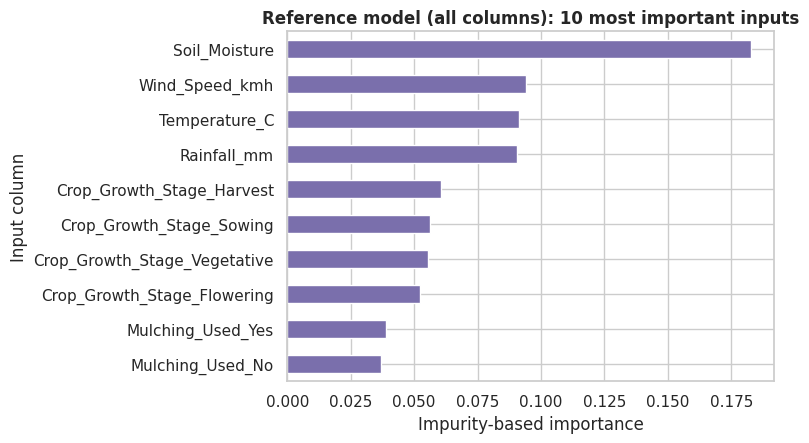

In [36]:
all_features = [c for c in df.columns if c != TARGET_COL]
cat_cols = df[all_features].select_dtypes(exclude="number").columns.tolist()
num_cols = [c for c in all_features if c not in cat_cols]

pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)], remainder="passthrough")
ref_model = Pipeline([("pre", pre), ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1))])
Xa_train, Xa_test = df.loc[X_train.index, all_features], df.loc[X_test.index, all_features]
ref_model.fit(Xa_train, y_train)
ref_pred = ref_model.predict(Xa_test)

ref_vs_final = pd.DataFrame({"Final model (3 sensors)": summarize(y_test, final_test_pred),
                             "Reference RF (all columns)": summarize(y_test, ref_pred)}).T
display(ref_vs_final[["accuracy", "macro_f1", "recall_High", "precision_High", "recall_Medium", "recall_Low"]].round(3))

ref_names = ref_model.named_steps["pre"].get_feature_names_out()
ref_imp = pd.Series(ref_model.named_steps["clf"].feature_importances_, index=[n.split("__")[-1] for n in ref_names])
top = ref_imp.sort_values(ascending=False).head(10)
ax = top.sort_values().plot(kind="barh", figsize=(8, 4.6), color="#7A6FAC")
ax.set_title("Reference model (all columns): 10 most important inputs"); ax.set_xlabel("Impurity-based importance"); ax.set_ylabel("Input column")
plt.tight_layout(); plt.show()

**Interpretation.** A Random Forest given **all** columns reaches accuracy ≈ 0.97 and macro-F1 ≈ 0.85, compared with ≈ 0.58 and ≈ 0.49 for the three-sensor model. In that reference model soil moisture is still the strongest single input, followed by wind speed, temperature and rainfall (all with similar importance) and crop growth stage (split across its four one-hot columns). The limited performance of the final model is therefore explained mostly by **information that the three sensors do not provide**, not by a shortcoming of the algorithm.

Two cautions: (1) the reference model detects fewer *High* cases (recall ≈ 0.43) but is almost never wrong when it says *High* (precision ≈ 1.0), a different trade-off from the final model; (2) this comparison shows what the dataset's label depends on; it does not show that the extra variables would be practical or reliable to measure in a real deployment (for example, a seasonal rainfall total is not a live sensor value). It also suggests the label may follow a fixed rule involving several variables, consistent with generated data.

## Step 16 — Visualize Predictions

Actual vs predicted irrigation status for the test set, including the probabilities the final model assigns (all three candidate families support `predict_proba`).


In [37]:
proba = final_pipeline.predict_proba(X_test)
proba_df = pd.DataFrame(proba, columns=[f"P({c})" for c in final_pipeline.classes_], index=X_test.index)[[f"P({c})" for c in CLASS_ORDER]]

results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = final_test_pred
results = results.join(proba_df.round(3))
results["Correct?"] = np.where(results["Actual"] == results["Predicted"], "yes", "NO")

print("12 randomly chosen test observations:")
display(results.sample(12, random_state=RANDOM_STATE).reset_index(drop=True))

12 randomly chosen test observations:


,Soil_Moisture,Temperature_C,Humidity,Actual,Predicted,P(Low),P(Medium),P(High),Correct?
0,47.15,19.72,66.89,Low,Low,0.740,0.260,0.000,yes
1,60.57,38.72,52.15,Medium,Medium,0.402,0.439,0.159,yes
2,47.79,38.23,55.97,Medium,Medium,0.402,0.439,0.159,yes
3,11.48,14.25,89.21,Medium,Medium,0.168,0.499,0.332,yes
4,19.63,31.22,44.80,Medium,High,0.028,0.218,0.754,NO
5,47.82,14.03,33.49,Low,Low,0.740,0.260,0.000,yes
6,59.05,20.16,50.49,Low,Low,0.740,0.260,0.000,yes
7,29.47,34.15,36.38,Low,Medium,0.402,0.439,0.159,NO
8,42.65,37.77,83.06,Medium,Medium,0.402,0.439,0.159,yes
9,54.92,15.98,89.78,Low,Low,0.740,0.260,0.000,yes


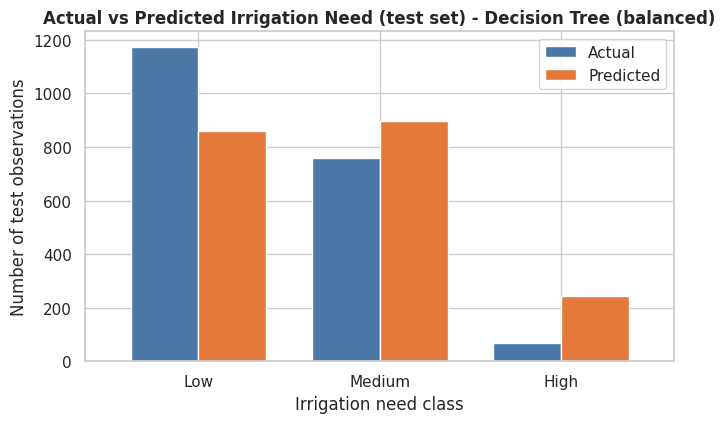

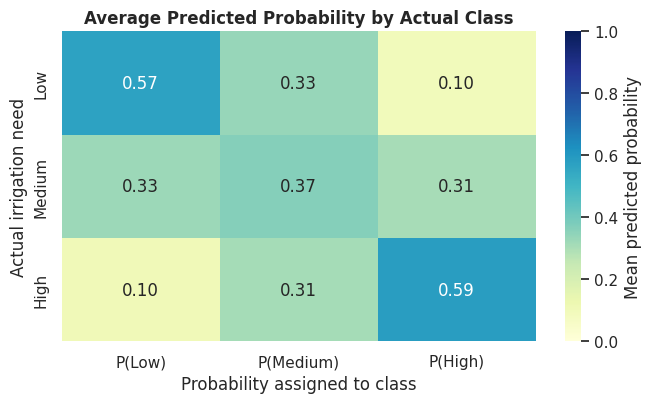

In [38]:
# Actual vs predicted counts
count_df = pd.DataFrame({"Actual": y_test.value_counts().reindex(CLASS_ORDER),
                         "Predicted": pd.Series(final_test_pred).value_counts().reindex(CLASS_ORDER)}).fillna(0)
ax = count_df.plot(kind="bar", figsize=(7, 4.4), color=["#4C78A8", "#E4793B"], width=0.75)
ax.set_title(f"Actual vs Predicted Irrigation Need (test set) - {FINAL_NAME}")
ax.set_xlabel("Irrigation need class"); ax.set_ylabel("Number of test observations"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

# Mean predicted probability for each actual class
mean_prob = proba_df.groupby(y_test).mean().reindex(CLASS_ORDER)
fig, ax = plt.subplots(figsize=(6.8, 4.2))
sns.heatmap(mean_prob, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Mean predicted probability"})
ax.set_title("Average Predicted Probability by Actual Class")
ax.set_xlabel("Probability assigned to class"); ax.set_ylabel("Actual irrigation need")
plt.tight_layout(); plt.show()

**Interpretation (each statement checked against the computed output).**
* **Predicted vs actual counts (test set):** the balanced model predicts *High* far more often than it occurs (243 predicted vs 67 actual), *Medium* somewhat more often (898 vs 760) and *Low* less often (859 vs 1,173). This over-prediction of the higher-need classes is the effect of class weighting and matches the low *High* precision (0.18).
* **Probability heatmap:** for every actual class the highest average probability is assigned to the correct class (Low 0.57, Medium 0.37, High 0.59), but the margins are small for *Medium* (0.37 vs 0.33 for *Low*). *Medium* and *High* observations both receive substantial probability for neighbouring classes, reflecting the overlap seen in the EDA.
* **Only four distinct probability patterns exist,** because a depth-2 tree has four leaves (visible in the table, e.g. 0.740 / 0.260 / 0.000). Confidence is therefore coarse and step-like.
* **Probabilities are not calibrated frequencies.** With class weighting, the leaf that outputs P(High) = 0.754 (soil moisture ≤ 25 % and temperature > 30 °C) actually contains about 20 % *High* observations in the raw data (about 68 % *Medium*, 13 % *Low*). Read them as relative confidence only.

## Step 17 — Test the Model With New Sensor Values

`predict_irrigation()` takes the three sensor readings, builds the input in the **saved feature order**, passes it through the trained pipeline (scaler + model, nothing hard-coded), and returns the pump recommendation. `predict_irrigation_detailed()` also returns the predicted level and class probabilities.

Input checks: physically impossible values raise an error, and values outside the range seen in training produce a warning, because the model can only be trusted inside the conditions it learned from.


In [39]:
TRAIN_RANGES = {c: (float(X_train[c].min()), float(X_train[c].max())) for c in FEATURES}

def predict_irrigation_detailed(soil_moisture, temperature, humidity, model=None):
    """Return predicted irrigation level, probabilities, pump recommendation and warnings."""
    model = model or final_pipeline
    values = {SOIL_COL: soil_moisture, TEMP_COL: temperature, HUM_COL: humidity}
    for col, v in values.items():
        lo, hi = PHYSICAL_LIMITS[col]
        if v is None or not np.isfinite(v) or not lo <= v <= hi:
            raise ValueError(f"{col}={v} is outside the physically valid range {lo} to {hi}.")
    notes = [f"{c}={v} is outside the training range {TRAIN_RANGES[c][0]:.0f}-{TRAIN_RANGES[c][1]:.0f}; treat prediction with caution."
             for c, v in values.items() if not TRAIN_RANGES[c][0] <= v <= TRAIN_RANGES[c][1]]
    x_new = pd.DataFrame([[values[c] for c in FEATURES]], columns=FEATURES)   # same feature order as training
    level = model.predict(x_new)[0]
    probs = dict(zip(model.classes_, model.predict_proba(x_new)[0].round(3)))
    return {"predicted_level": level, "probabilities": {c: float(probs[c]) for c in CLASS_ORDER},
            "decision": IRRIGATION_POLICY[level], "warnings": notes}

def predict_irrigation(soil_moisture, temperature, humidity):
    """Return 'Irrigation Needed' or 'Irrigation Not Needed'."""
    return predict_irrigation_detailed(soil_moisture, temperature, humidity)["decision"]

print(predict_irrigation(soil_moisture=30, temperature=32, humidity=55))
print(predict_irrigation_detailed(soil_moisture=30, temperature=32, humidity=55))

Irrigation Needed
{'predicted_level': 'Medium', 'probabilities': {'Low': 0.402, 'Medium': 0.439, 'High': 0.159}, 'decision': 'Irrigation Needed', 'warnings': []}


## Step 18 — Simulate Sensor Data

> **These are test inputs / simulation only — not real sensor measurements.** No physical sensor was connected. The values are hand-picked to show how a reading would flow through the model.


In [40]:
simulated_readings = [
    ("Moderate soil moisture, hot",       30, 32, 55),
    ("Wet soil, mild",                    55, 22, 70),
    ("Dry soil, cool, humid",             12, 18, 85),
    ("Borderline soil moisture",          26, 28, 60),
    ("Dry and hot",                       10, 40, 30),
    ("Well watered and hot",              60, 38, 40),
    ("Out-of-range humidity (warning)",   40, 25, 100),
]
first = True
rows = []
for label, sm, t, h in simulated_readings:
    r = predict_irrigation_detailed(sm, t, h)
    if first:
        print("SIMULATION - example readout\n")
        print(f"Soil Moisture: {sm}%\nTemperature: {t}°C\nHumidity: {h}%\n\nPrediction: {r['decision']}   (level: {r['predicted_level']})\n")
        first = False
    rows.append({"Scenario (simulated)": label, "Soil moisture %": sm, "Temp °C": t, "Humidity %": h,
                 "Predicted level": r["predicted_level"], "Decision": r["decision"],
                 "P(Low)": r["probabilities"]["Low"], "P(Medium)": r["probabilities"]["Medium"], "P(High)": r["probabilities"]["High"],
                 "Warning": "; ".join(r["warnings"]) or "-"})
display(pd.DataFrame(rows))

SIMULATION - example readout

Soil Moisture: 30%
Temperature: 32°C
Humidity: 55%

Prediction: Irrigation Needed   (level: Medium)



,Scenario (simulated),Soil moisture %,Temp °C,Humidity %,Predicted level,Decision,P(Low),P(Medium),P(High),Warning
0,"Moderate soil moisture, hot",30,32,55,Medium,Irrigation Needed,0.402,0.439,0.159,-
1,"Wet soil, mild",55,22,70,Low,Irrigation Not Needed,0.740,0.260,0.000,-
2,"Dry soil, cool, humid",12,18,85,Medium,Irrigation Needed,0.168,0.499,0.332,-
3,Borderline soil moisture,26,28,60,Low,Irrigation Not Needed,0.740,0.260,0.000,-
4,Dry and hot,10,40,30,High,Irrigation Needed,0.028,0.218,0.754,-
5,Well watered and hot,60,38,40,Medium,Irrigation Needed,0.402,0.439,0.159,-
6,Out-of-range humidity (warning),40,25,100,Low,Irrigation Not Needed,0.740,0.260,0.000,Humidity=100 is outside the training range 25-...


**Interpretation of the simulation (test inputs, not real sensor data).**
* The example reading (30 % soil moisture, 32 °C, 55 % humidity) is predicted *Medium* → **Irrigation Needed**, with low confidence (P(Medium) 0.44 vs P(Low) 0.40).
* Very dry and hot (10 %, 40 °C) gives *High* with the highest confidence (0.75).
* Borderline behaviour follows the tree's threshold: 26 % soil moisture at 28 °C is *Low*, whereas soil moisture at or below about 25 % at the same temperature is *Medium*.
* **A limitation this exposes:** the "well watered and hot" input (60 %, 38 °C) is predicted *Medium* → Irrigation Needed. In the raw data, observations with soil moisture above 25 % and temperature above 30 °C are about **58 % Low, 40 % Medium and 1 % High**, so *Low* is actually the more common outcome there. The balanced model still outputs *Medium* because class weighting pushes the leaf toward the higher-need class. This is a deliberate bias toward avoiding under-irrigation, but it means the model will recommend some unnecessary irrigation, and safety/agronomic rules outside the model are needed.
* Humidity has no effect on this model's output (it is unused by the tree), and a value of 100 % triggers an out-of-training-range warning (training range 25–95 %).

## Step 19 — IoT Deployment Concept

**Proposed architecture (concept only — not built or tested in this notebook):**

```text
Soil Moisture Sensor ─┐
                      │
Temperature Sensor ───┼──> Microcontroller
                      │
Humidity Sensor ──────┘
                              │
                              ↓
                         Sensor Data
                              │
                              ↓
                         AI Model
                              │
                    ┌─────────┴─────────┐
                    ↓                   ↓
             Irrigation ON       Irrigation OFF
                    │                   │
                    ↓                   ↓
                Water Pump            Pump OFF
```

**Possible hardware:** an **ESP32** (built-in Wi-Fi) or an **Arduino-compatible** board, depending on availability, with a capacitive soil-moisture probe, a DHT22/BME280-type temperature-humidity sensor, and a relay module switching the pump.

**Two ways to run the model:**

| Option | How | Trade-off |
|---|---|---|
| **Edge / on-device** | Export the (small) decision-tree or logistic-regression rules into C/C++ code running on the microcontroller | Works offline; only feasible for small models |
| **Edge + server** | The microcontroller sends readings over Wi-Fi (e.g. HTTP/MQTT) to a Python service that loads the saved model and returns the decision | Any scikit-learn model can be used; requires connectivity |

**Points that must be handled before real deployment**
* **Calibration** – the moisture probe's raw output (voltage/ADC counts) must be calibrated to the same scale (%) as the dataset; this is a major source of error.
* **Sensor faults** – readings outside valid ranges (as checked in `predict_irrigation`) must be rejected, and averaging over several readings reduces noise.
* **Safety logic** – add a maximum pump run-time, minimum interval between cycles and a manual override, independent of the model.
* **Validation** – compare model decisions with real field observations before letting it control the pump automatically.

> Hardware integration has **not** been implemented or tested in this notebook.


## Step 20 — Save the Model

Training takes time and depends on the data; the deployed system should not retrain at start-up. Saving the fitted pipeline lets an application or gateway load exactly the model evaluated here. The saved pipeline already **contains the fitted scaler (or pass-through) and the classifier**, so preprocessing cannot get out of sync with the model. The **feature order** and other metadata are stored alongside it as JSON.


In [41]:
ARTIFACT_DIR = Path("model_artifacts"); ARTIFACT_DIR.mkdir(exist_ok=True)
MODEL_PATH, META_PATH = ARTIFACT_DIR / "irrigation_model.joblib", ARTIFACT_DIR / "model_metadata.json"

# FREEZE_SAVED_MODEL = True keeps the existing saved model/metadata (the frozen prototype model) and never overwrites them,
# so re-running this notebook cannot silently replace the model that Part B depends on.
FREEZE_SAVED_MODEL = True

if FREEZE_SAVED_MODEL and MODEL_PATH.exists() and META_PATH.exists():
    saved_model = joblib.load(MODEL_PATH)
    same = bool((saved_model.predict(X_test) == final_pipeline.predict(X_test)).all())
    print("FREEZE_SAVED_MODEL = True: the existing saved model and metadata were kept (not overwritten).")
    print("The pipeline trained in this run gives identical test predictions to the saved model:", same)
else:
    joblib.dump(final_pipeline, MODEL_PATH)

    metadata = {
        "project": "AI-Based Smart Irrigation System Using Environmental Sensor Data",
        "created": datetime.now().isoformat(timespec="seconds"),
        "model_name": FINAL_NAME,
        "model_parameters": {k: (None if v is None else v) for k, v in best_params[FINAL_NAME].items()},
        "feature_order": FEATURES,
        "feature_units": {SOIL_COL: "% (assumed)", TEMP_COL: "degrees Celsius", HUM_COL: "% relative humidity (assumed)"},
        "target": TARGET_COL,
        "classes": CLASS_ORDER,
        "irrigation_policy": IRRIGATION_POLICY,
        "training_value_ranges": TRAIN_RANGES,
        "physical_limits": PHYSICAL_LIMITS,
        "n_train": int(len(X_train)), "n_test": int(len(X_test)), "random_state": RANDOM_STATE,
        "test_metrics": {k: round(float(v), 4) for k, v in summarize(y_test, final_test_pred).items()},
        "library_versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
                             "pandas": pd.__version__, "numpy": np.__version__, "joblib": joblib.__version__},
        "notes": "Trained on the supplied dataset (source and collection method not documented). Not validated on real sensor data.",
    }
    META_PATH.write_text(json.dumps(metadata, indent=2, default=str))

    # Verify: reload and confirm identical predictions
    reloaded = joblib.load(MODEL_PATH)
    assert (reloaded.predict(X_test) == final_pipeline.predict(X_test)).all()
    print("Saved:", MODEL_PATH, "and", META_PATH, "- reload check passed (identical predictions).")
    print("\nHow to use later:\n  model = joblib.load('model_artifacts/irrigation_model.joblib')\n  model.predict(pd.DataFrame([[soil, temp, hum]], columns=feature_order))")

FREEZE_SAVED_MODEL = True: the existing saved model and metadata were kept (not overwritten).
The pipeline trained in this run gives identical test predictions to the saved model: True


## Step 21 — Final Results Dashboard

,Value
Observations (after cleaning),"10,000"
Model input features,"3 (Soil_Moisture, Temperature_C, Humidity)"
Training size,"8,000"
Testing size,"2,000"
Target,Irrigation_Need: Low / Medium / High (origina...
Selected algorithm,"Decision Tree (balanced) {'max_depth': 2, 'mi..."
Accuracy,0.578
Precision (macro),0.484
Recall (macro),0.595
F1-score (macro),0.489


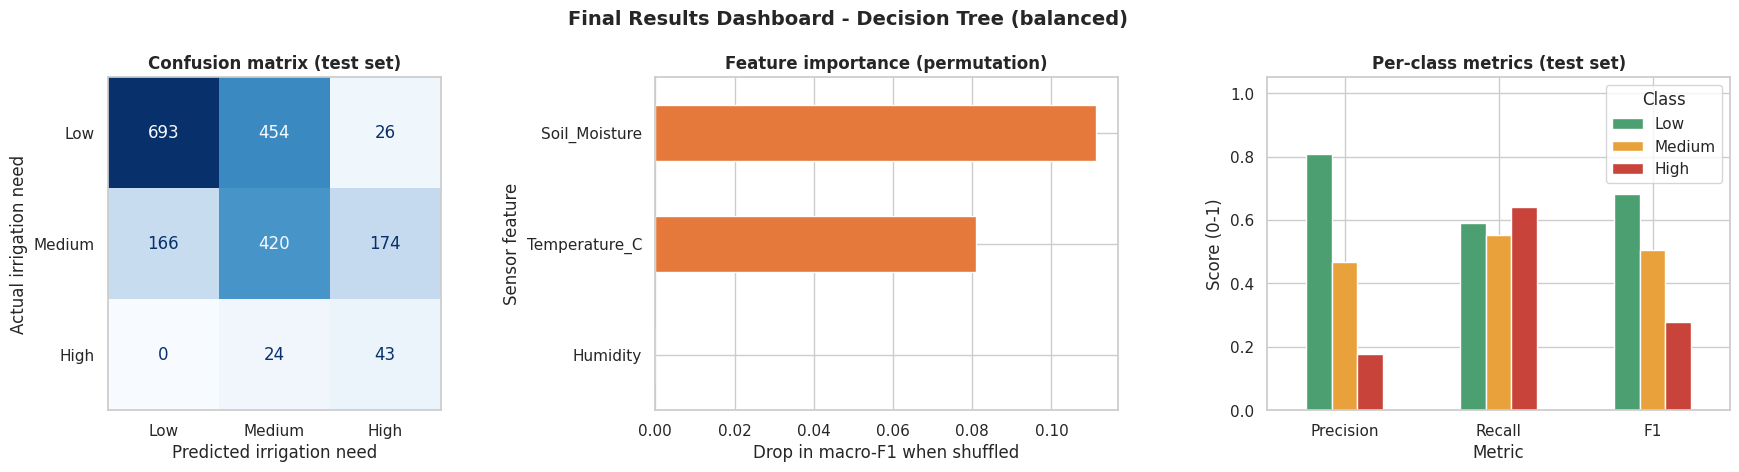

In [42]:
final_metrics = summarize(y_test, final_test_pred)
dashboard = pd.DataFrame({"Value": {
    "Observations (after cleaning)": f"{len(df):,}",
    "Model input features": f"{len(FEATURES)}  ({', '.join(FEATURES)})",
    "Training size": f"{len(X_train):,}",
    "Testing size": f"{len(X_test):,}",
    "Target": f"{TARGET_COL}: {' / '.join(CLASS_ORDER)}  (original dataset labels)",
    "Selected algorithm": f"{FINAL_NAME}  {best_params[FINAL_NAME]}",
    "Accuracy": f"{final_metrics['accuracy']:.3f}",
    "Precision (macro)": f"{final_metrics['macro_precision']:.3f}",
    "Recall (macro)": f"{final_metrics['macro_recall']:.3f}",
    "F1-score (macro)": f"{final_metrics['macro_f1']:.3f}",
    "Recall - High class": f"{final_metrics['recall_High']:.3f}",
    "Precision - High class": f"{final_metrics['precision_High']:.3f}",
    "Pump-decision recall (Needed)": f"{binary_metrics['recall']:.3f}",
    "Pump-decision precision (Needed)": f"{binary_metrics['precision']:.3f}",
}})
display(dashboard)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
ConfusionMatrixDisplay.from_predictions(y_test, final_test_pred, labels=CLASS_ORDER, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (test set)"); axes[0].set_xlabel("Predicted irrigation need"); axes[0].set_ylabel("Actual irrigation need"); axes[0].grid(False)
perm_df["mean"].sort_values().plot(kind="barh", ax=axes[1], color="#E4793B")
axes[1].set_title("Feature importance (permutation)"); axes[1].set_xlabel("Drop in macro-F1 when shuffled"); axes[1].set_ylabel("Sensor feature")
per_cls = pd.DataFrame({c: [final_metrics[f"precision_{c}"], final_metrics[f"recall_{c}"], final_metrics[f"f1_{c}"]] for c in CLASS_ORDER}, index=["Precision", "Recall", "F1"])
per_cls.plot(kind="bar", ax=axes[2], color=[CLASS_COLORS[c] for c in CLASS_ORDER]); axes[2].set_ylim(0, 1.05)
axes[2].set_title("Per-class metrics (test set)"); axes[2].set_xlabel("Metric"); axes[2].set_ylabel("Score (0-1)"); plt.setp(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(title="Class")
plt.suptitle(f"Final Results Dashboard - {FINAL_NAME}", fontsize=14, fontweight="bold"); plt.tight_layout(); plt.show()

## Step 22 — Conclusion

**What was built.** A complete machine-learning prototype in this notebook: data inspection and cleaning, exploratory analysis, six candidate models (Logistic Regression, Decision Tree and Random Forest, each with and without class weighting), cross-validated model selection, evaluation on an untouched test set, a prediction function, a simulation and a saved model with metadata.

**What the model predicts.** The dataset's own three-level label `Irrigation_Need` (**Low / Medium / High**), from three inputs: **soil moisture, temperature and humidity**. A pump recommendation ("Irrigation Needed" / "Not Needed") is derived from the predicted level by an explicit, editable rule (Medium and High → irrigate), which is a design assumption and not something the dataset defines.

**Selected model and performance.** A balanced **Decision Tree of depth 2**. On the 2,000-row test set: accuracy 0.578, macro-F1 0.489, recall for *High* 0.642 (precision 0.177). As a pump decision, it finds ≈ 80 % of the fields that needed irrigation (precision ≈ 58 %). The model relies on soil moisture (threshold ≈ 25 %) and temperature (threshold ≈ 30 °C); humidity is not used.

**How it could support smart irrigation.** As a low-cost screening rule that flags dry, hot conditions and errs toward irrigating rather than under-irrigating, and which is simple enough to run on a microcontroller or a small server.

**Limitations.**
* **Modest performance:** accuracy is no better than always predicting "Low" (0.587), and only ≈ 18 % of *High* alerts are correct. The result must not be presented as a highly accurate system.
* **Missing information:** a model using all dataset columns reaches ≈ 0.97 accuracy, so the three sensors leave much of the label unexplained.
* **Data origin:** the flat distributions, hard limits and uncorrelated variables suggest simulated data; its source, units and labelling method are undocumented. Patterns (e.g. the 25 % soil-moisture threshold) may reflect the generator, not real agronomy.
* **Small rare class:** only 67 *High* examples in the test set, so *High* metrics are uncertain.
* **No geography:** the dataset has no coordinates, so no map could be produced.
* **Uncalibrated probabilities** (class weighting) and coarse, four-leaf outputs.

**How real sensor data would help.** Collecting readings from the actual sensors, together with an expert's or an outcome-based irrigation decision, would allow (1) calibrating the sensors against this scale, (2) re-training and testing on the true operating conditions, (3) checking whether humidity or additional inputs (e.g. rainfall or a weather forecast, crop stage) are worth adding, and (4) choosing the irrigation policy and alert threshold with agronomists.

**Path to controlling a water pump.** Load the saved model (`model_artifacts/`), feed it validated sensor readings from an ESP32/Arduino-class node, and drive a relay through the decision, with safeguards independent of the model (maximum run time, minimum interval, manual override).

> **Prototype vs deployment.** Everything in this notebook is a **machine-learning prototype trained and tested on a supplied dataset**. No sensor, microcontroller or pump has been connected or tested. Physical IoT deployment is a **future stage** that requires hardware integration and field validation.


---
# PART B — From Prediction to Irrigation Control (architecture update)

Steps 1–22 above (data, model development, evaluation) are **unchanged**. The steps below add the **real Arduino data workflow**, the separate **irrigation-control layer**, user-configurable parameters with safety limits, the closed-loop pump logic, and the proposed multi-zone / power / communication architecture.

> **Scope:** notebook only. No website, app, dashboard, API, login or database is built here. “User configuration” means clearly labelled configuration variables in this notebook.
> **Model status:** the Decision Tree saved in `model_artifacts/` is a **fixed, initial prototype**. It is *not* retrained or replaced by anything in Part B.

## Step 23 — Real Sensor Data (Arduino)

This section keeps the real-data workflow (load → predict → pump mapping) and adds **validation** (types, physical limits, and — importantly — whether the readings lie inside the range the model was trained on).

> **Note on the stored outputs in this version.** `real_sensor_data.csv` was not supplied with the update request. The outputs stored below were produced from a **30-row excerpt** (10 first + 20 last rows) that was recovered from the outputs saved in the earlier version of this notebook, so the code could be tested. The full file in the earlier version had **135 rows (129 predicted Medium, 6 Low)**. Re-run this notebook with your complete `real_sensor_data.csv` to refresh every number in Steps 23 and 31.

In [43]:
import pandas as pd
import joblib

# Load real sensor data
real_data = pd.read_csv("real_sensor_data.csv")

# Display the first readings
real_data.head()

,Timestamp,Soil_Moisture,Temperature_C,Humidity
0,2026-09-30 20:58:55,0.2,25.6,89.1
1,2026-09-30 20:58:57,0.2,25.7,89.6
2,2026-09-30 20:58:59,0.5,25.7,89.6
3,2026-09-30 20:59:01,0.2,25.7,89.3
4,2026-09-30 20:59:03,0.2,25.7,89.3


In [44]:
real_data.describe()

,Soil_Moisture,Temperature_C,Humidity
count,30.000000,30.000000,30.000000
mean,6.096667,25.766667,89.456667
std,17.016270,0.054667,0.135655
min,0.000000,25.600000,89.100000
25%,0.200000,25.700000,89.350000
50%,0.200000,25.800000,89.500000
75%,0.575000,25.800000,89.500000
max,73.700000,25.800000,89.700000


### 23.1 Validation of the real readings (added)

,variable,min,max,mean,missing/non-numeric,physically impossible,below training range,above training range,training range
0,Soil_Moisture,0.0,73.7,6.10,0,0,26,1,8 to 65
1,Temperature_C,25.6,25.8,25.77,0,0,0,0,12 to 42
2,Humidity,89.1,89.7,89.46,0,0,0,0,25 to 95


Rows loaded: 30 | rows with at least one input outside the training range: 27 (90%)
Consecutive soil-moisture jumps larger than 20 percentage points: 5


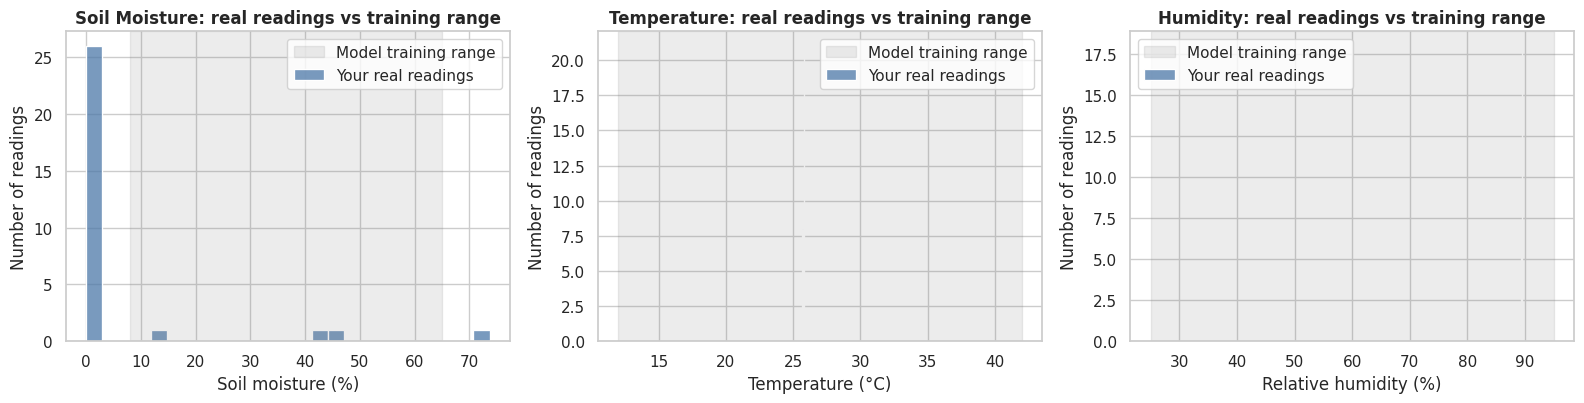

In [45]:
# ---- types, physical limits and training-range check for the real readings ----
real_check = real_data.copy()
for col in FEATURES:
    real_check[col] = pd.to_numeric(real_check[col], errors="coerce")        # text -> NaN, so it can be counted

rows = []
for col in FEATURES:
    lo, hi = PHYSICAL_LIMITS[col]                 # physical limits defined in Step 5
    tlo, thi = TRAIN_RANGES[col]                  # range seen by the model in training (Step 17)
    s = real_check[col]
    rows.append({"variable": col, "min": s.min(), "max": s.max(), "mean": round(s.mean(), 2),
                 "missing/non-numeric": int(s.isna().sum()),
                 "physically impossible": int(((s < lo) | (s > hi)).sum()),
                 "below training range": int((s < tlo).sum()), "above training range": int((s > thi).sum()),
                 "training range": f"{tlo:g} to {thi:g}"})
display(pd.DataFrame(rows))

OUTSIDE_RANGE = pd.Series(False, index=real_check.index)
for col in FEATURES:
    OUTSIDE_RANGE |= (real_check[col] < TRAIN_RANGES[col][0]) | (real_check[col] > TRAIN_RANGES[col][1])
real_data["Outside_Training_Range"] = OUTSIDE_RANGE.values
print(f"Rows loaded: {len(real_data)} | rows with at least one input outside the training range: "
      f"{int(OUTSIDE_RANGE.sum())} ({OUTSIDE_RANGE.mean():.0%})")

# Very large jumps between consecutive readings are physically suspicious for soil moisture
big_jumps = (real_check["Soil_Moisture"].diff().abs() > 20).sum()
print(f"Consecutive soil-moisture jumps larger than 20 percentage points: {int(big_jumps)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, col in zip(axes, FEATURES):
    sns.histplot(real_check[col].dropna(), bins=25, color="#4C78A8", ax=ax, label="Your real readings")
    ax.axvspan(*TRAIN_RANGES[col], color="grey", alpha=0.15, label="Model training range")
    ax.set_title(f"{FEATURE_TITLES[col]}: real readings vs training range"); ax.set_xlabel(FEATURE_LABELS[col])
    ax.set_ylabel("Number of readings"); ax.legend()
plt.tight_layout(); plt.show()

**Interpretation (stored output = 30-row excerpt; see the note at the top of Step 23).**
* **Temperature (25.6–25.8 °C) and humidity (89.1–89.7 %)** are inside the model's training ranges and almost constant, which suggests a short session in stable conditions.
* **Soil moisture is mostly ≈ 0 %.** In the excerpt 26 of 30 readings are below the lowest value the model saw in training (8 %), one (73.7 %) is above the highest (65 %), and **27 of 30 rows (90 %) have at least one input outside the training range**. In your full 135-row run the 75th percentile was also 0.2 %, so most readings there are near zero as well.
* **Suspicious jumps:** consecutive readings such as 0.5 → 46.3 → 73.7 → 0.5 (a two-second apart pair of readings cannot plausibly change soil moisture that much). This is consistent with the probe being moved (for example into water), poor contact, or an uncalibrated sensor scale. These values are **flagged, not deleted**; they need physical investigation.
* **Consequence:** the model is **extrapolating** on most of your real readings, so its output on them should be treated with caution until the sensor is calibrated and readings from real soil in the 8–65 % region are collected.

### 23.2 AI inference on the real readings (your original workflow, unchanged)

In [46]:
model = joblib.load("model_artifacts/irrigation_model.joblib")

print("Model loaded successfully.")

Model loaded successfully.


In [47]:
features = [
    "Soil_Moisture",
    "Temperature_C",
    "Humidity"
]

predictions = model.predict(real_data[features])

real_data["Irrigation_Need"] = predictions

real_data.head(5)

,Timestamp,Soil_Moisture,Temperature_C,Humidity,Outside_Training_Range,Irrigation_Need
0,2026-09-30 20:58:55,0.2,25.6,89.1,True,Medium
1,2026-09-30 20:58:57,0.2,25.7,89.6,True,Medium
2,2026-09-30 20:58:59,0.5,25.7,89.6,True,Medium
3,2026-09-30 20:59:01,0.2,25.7,89.3,True,Medium
4,2026-09-30 20:59:03,0.2,25.7,89.3,True,Medium


The next cell is the **AI-only** mapping from your original workflow (Medium/High → ON). It is kept for comparison, but it is **not** the final pump decision: from Step 24 onward the pump state is decided by the separate control layer.

In [48]:
real_data["Pump_Action"] = real_data["Irrigation_Need"].map({
    "Low": "OFF",
    "Medium": "ON",
    "High": "ON"
})

real_data.head(10)

,Timestamp,Soil_Moisture,Temperature_C,Humidity,Outside_Training_Range,Irrigation_Need,Pump_Action
0,2026-09-30 20:58:55,0.2,25.6,89.1,True,Medium,ON
1,2026-09-30 20:58:57,0.2,25.7,89.6,True,Medium,ON
2,2026-09-30 20:58:59,0.5,25.7,89.6,True,Medium,ON
3,2026-09-30 20:59:01,0.2,25.7,89.3,True,Medium,ON
4,2026-09-30 20:59:03,0.2,25.7,89.3,True,Medium,ON
5,2026-09-30 20:59:05,0.0,25.7,89.3,True,Medium,ON
6,2026-09-30 20:59:07,0.0,25.7,89.3,True,Medium,ON
7,2026-09-30 20:59:09,0.5,25.7,89.3,True,Medium,ON
8,2026-09-30 20:59:11,0.2,25.7,89.3,True,Medium,ON
9,2026-09-30 20:59:13,0.0,25.8,89.2,True,Medium,ON


In [49]:
real_data["Irrigation_Need"].value_counts()

Irrigation_Need
Medium    27
Low        3
Name: count, dtype: int64

In [50]:
real_data["Pump_Action"].value_counts()

Pump_Action
ON     27
OFF     3
Name: count, dtype: int64

In [51]:
real_data[[
    "Soil_Moisture",
    "Temperature_C",
    "Humidity",
    "Irrigation_Need",
    "Pump_Action"
]].tail(20)

,Soil_Moisture,Temperature_C,Humidity,Irrigation_Need,Pump_Action
10,1.9,25.8,89.5,Medium,ON
11,46.3,25.8,89.5,Low,OFF
12,73.7,25.8,89.5,Low,OFF
13,0.5,25.8,89.5,Medium,ON
14,1.6,25.8,89.5,Medium,ON
15,0.6,25.8,89.5,Medium,ON
16,0.6,25.8,89.5,Medium,ON
17,11.8,25.8,89.5,Medium,ON
18,42.3,25.8,89.5,Low,OFF
19,0.2,25.8,89.5,Medium,ON


**Interpretation.**
* In the excerpt the model predicts **27 Medium and 3 Low** (your full run: 129 Medium, 6 Low). *Low* appears only for the readings of 42–74 % soil moisture.
* The model is the four-rule tree shown in Step 24.1. Because *High* requires temperature above about 30 °C, **at the ≈ 25.7 °C of this log the model cannot output High, even for bone-dry soil** — it can only say Medium. This is a limitation of the model, not of the sensor.
* The AI-only mapping above turns the pump ON for every Medium/High row. It is kept for comparison; the control layer (Steps 28 and 31) makes the final proposal.

## Step 24 — AI Inference vs Irrigation Control

The system answers **two different questions with two different components**:

| | **A. AI inference** | **B. Irrigation control layer** |
|---|---|---|
| Question | *Does this area currently need irrigation?* | *If irrigation is needed, how much water, for how long, and when should the pump stop?* |
| Inputs | Soil moisture, temperature, humidity | AI output (Low/Medium/High) **+** current soil moisture **+** zone configuration (area, flow rate, targets, limits) |
| Method | Decision Tree (trained, **fixed**) | Explicit equations and safety rules (**configurable**, no training) |
| Output | `Low` / `Medium` / `High` | Pump ON/OFF, water volume (L), runtime (min), stop conditions |
| Changed by the farmer? | **No** | **Yes**, within validated safety limits |

> **Precise terminology.** The AI model performs **irrigation-need inference**. It does **not** calculate water volume or pump runtime. The control layer calculates the irrigation amount/runtime and controls the pump/valve.

**Why separate them?** Different farms differ in soil, crop, growth stage, field size, irrigation hardware and water availability. Those differences affect *how much* to irrigate, but the prototype sensors cannot measure most of them. Keeping them in editable control parameters lets an operator calibrate the system to a field **without retraining the AI model**, and keeps the model focused on the three quantities the prototype can actually measure.

> User-configurable parameters do not eliminate the need for future model validation or retraining if real-world data shows that the model does not generalize adequately.

In [52]:
# ---------- small helper for architecture diagrams (matplotlib only, no extra libraries) ----------
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Patch

STATUS_STYLE = {   # fill colour, edge colour, line style
    "demo": ("#DDF0E2", "#2E7D4F", "-"),    # demonstrated in this project (real Arduino data + Decision Tree)
    "soft": ("#DCE8F7", "#2F5F9E", "-"),    # implemented in this notebook as software / simulation
    "prop": ("#FCEBD2", "#B8721D", "--"),   # PROPOSED / future hardware - not built or tested
    "ext":  ("#EFEFEF", "#666666", "-"),    # the physical environment (not a component)
}
STATUS_LABEL = {"demo": "Demonstrated in this project", "soft": "Implemented in this notebook (software / simulation)",
                "prop": "Proposed / future hardware (NOT built or tested)", "ext": "Physical environment"}

def _anchor(box, side):
    x, y, w, h = box[:4]
    return {"left": (x - w / 2, y), "right": (x + w / 2, y), "top": (x, y + h / 2), "bottom": (x, y - h / 2)}[side]

def draw_diagram(title, boxes, arrows, figsize=(13, 6.2), xlim=(0, 100), ylim=(0, 60), notes=(), frames=()):
    """boxes: {key: (cx, cy, w, h, text, status)}; arrows: [(from_key, side, to_key, side, label, curvature)]"""
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    for (x, y, w, h, label) in frames:                       # grouping rectangles (e.g. "Farm")
        ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.3,rounding_size=1.5",
                                    fc="none", ec="#999999", lw=1.2, ls=":"))
        ax.text(x - w / 2 + 1, y + h / 2 - 1.2, label, fontsize=9, color="#555555", va="top", style="italic")
    for key, (x, y, w, h, text, status) in boxes.items():
        fc, ec, ls = STATUS_STYLE[status]
        ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.3,rounding_size=1.2", fc=fc, ec=ec, lw=1.8, ls=ls))
        ax.text(x, y, text, ha="center", va="center", fontsize=8.6)
    for a, sa, b, sb, label, rad in arrows:
        p1, p2 = _anchor(boxes[a], sa), _anchor(boxes[b], sb)
        ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=14, lw=1.4, color="#333333",
                                     connectionstyle=f"arc3,rad={rad}", shrinkA=2, shrinkB=2))
        if label:
            ax.text((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2 + 1.1, label, fontsize=7.8, ha="center", va="bottom",
                    color="#222222", bbox=dict(fc="white", ec="none", alpha=0.85, pad=0.8))
    for (x, y, text) in notes:
        ax.text(x, y, text, fontsize=8.6, ha="center", va="center", color="#333333")
    used = sorted({b[5] for b in boxes.values()})
    ax.legend(handles=[Patch(fc=STATUS_STYLE[s][0], ec=STATUS_STYLE[s][1], ls=STATUS_STYLE[s][2], lw=1.6, label=STATUS_LABEL[s]) for s in used],
              loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=len(used), fontsize=8.5, frameon=False)
    plt.tight_layout(); plt.show()


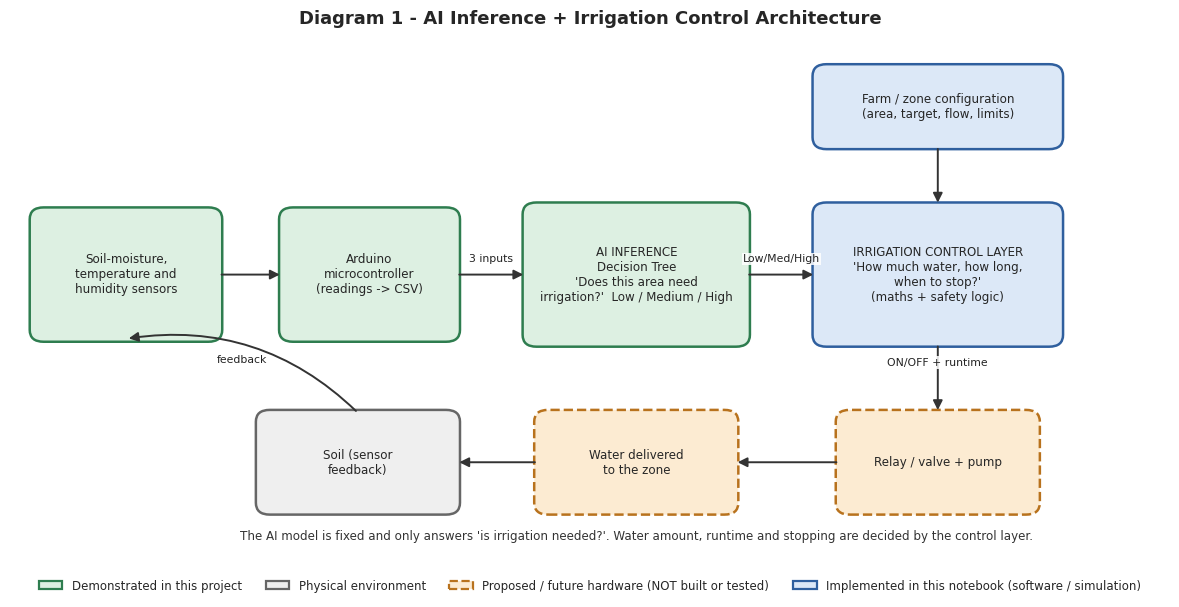

In [53]:
# DIAGRAM 1 - AI inference + irrigation control architecture
boxes = {
    "sensors": (10, 38, 16, 13, "Soil-moisture,\ntemperature and\nhumidity sensors", "demo"),
    "mcu":     (31, 38, 15, 13, "Arduino\nmicrocontroller\n(readings -> CSV)", "demo"),
    "ai":      (54, 38, 19, 14, "AI INFERENCE\nDecision Tree\n'Does this area need\nirrigation?'  Low / Medium / High", "demo"),
    "ctrl":    (80, 38, 21, 14, "IRRIGATION CONTROL LAYER\n'How much water, how long,\nwhen to stop?'\n(maths + safety logic)", "soft"),
    "cfg":     (80, 55, 21, 8,  "Farm / zone configuration\n(area, target, flow, limits)", "soft"),
    "relay":   (80, 19, 17, 10, "Relay / valve + pump", "prop"),
    "irrig":   (54, 19, 17, 10, "Water delivered\nto the zone", "prop"),
    "soil":    (30, 19, 17, 10, "Soil (sensor\nfeedback)", "ext"),
}
arrows = [("sensors", "right", "mcu", "left", "", 0), ("mcu", "right", "ai", "left", "3 inputs", 0),
          ("ai", "right", "ctrl", "left", "Low/Med/High", 0), ("cfg", "bottom", "ctrl", "top", "", 0),
          ("ctrl", "bottom", "relay", "top", "ON/OFF + runtime", 0), ("relay", "left", "irrig", "right", "", 0),
          ("irrig", "left", "soil", "right", "", 0), ("soil", "top", "sensors", "bottom", "feedback", 0.25)]
draw_diagram("Diagram 1 - AI Inference + Irrigation Control Architecture", boxes, arrows, ylim=(8, 62),
             notes=[(54, 11.5, "The AI model is fixed and only answers 'is irrigation needed?'. Water amount, runtime and stopping are decided by the control layer.")])


### 24.1 Integrity check of the (frozen) AI model

In [54]:
import hashlib, pickle

MODEL_FILE = Path("model_artifacts/irrigation_model.joblib")
META_FILE = Path("model_artifacts/model_metadata.json")
file_sha256 = lambda p: hashlib.sha256(Path(p).read_bytes()).hexdigest()

MODEL_FILE_SHA_START = file_sha256(MODEL_FILE)                     # fingerprint of the saved model file
frozen_model = joblib.load(MODEL_FILE)
frozen_meta = json.loads(META_FILE.read_text())
tree = frozen_model.named_steps["clf"]

print("Model type          :", type(tree).__name__, "| class_weight =", tree.class_weight)
print("Tree depth / leaves :", tree.get_depth(), "/", tree.get_n_leaves())
print("Input features      :", list(tree.feature_names_in_))
print("Output classes      :", list(frozen_model.classes_))
print("Saved file SHA-256  :", MODEL_FILE_SHA_START[:16] + "...")
print("\nLearned decision rules (the entire model):\n")
print(export_text(tree, feature_names=FEATURES))

# Recompute the test metrics from the frozen model and compare with the stored / quoted values
frozen_test_metrics = summarize(y_test, frozen_model.predict(X_test))
QUOTED = {"accuracy": 0.578, "macro_precision": 0.484, "macro_recall": 0.595, "macro_f1": 0.489}
integrity = pd.DataFrame({"recomputed now": {k: round(frozen_test_metrics[k], 4) for k in QUOTED},
                          "stored in metadata": {k: frozen_meta["test_metrics"][k] for k in QUOTED},
                          "quoted in project brief": QUOTED})
display(integrity)
assert all(abs(round(frozen_test_metrics[k], 3) - QUOTED[k]) <= 0.0011 for k in QUOTED), "frozen model no longer reproduces its metrics"
print("Integrity check passed: the saved Decision Tree reproduces its documented test performance.")

Model type          : DecisionTreeClassifier | class_weight = balanced
Tree depth / leaves : 2 / 4
Input features      : ['Soil_Moisture', 'Temperature_C', 'Humidity']
Output classes      : ['High', 'Low', 'Medium']
Saved file SHA-256  : 1fae85a798de3f7d...

Learned decision rules (the entire model):

|--- Soil_Moisture <= 24.98
|   |--- Temperature_C <= 30.06
|   |   |--- class: Medium
|   |--- Temperature_C >  30.06
|   |   |--- class: High
|--- Soil_Moisture >  24.98
|   |--- Temperature_C <= 30.16
|   |   |--- class: Low
|   |--- Temperature_C >  30.16
|   |   |--- class: Medium



,recomputed now,stored in metadata,quoted in project brief
accuracy,0.5780,0.5780,0.578
macro_precision,0.4838,0.4838,0.484
macro_recall,0.5951,0.5951,0.595
macro_f1,0.4887,0.4887,0.489


Integrity check passed: the saved Decision Tree reproduces its documented test performance.


**Interpretation.** The saved model is the original balanced **Decision Tree of depth 2 with 4 leaves**, using exactly the three sensor features. Recomputing its test metrics gives the same values as stored in the metadata and as quoted in the project brief (accuracy 0.578, macro precision 0.484, macro recall 0.595, macro F1 0.489). The whole model is four rules on soil moisture (≈ 25 %) and temperature (≈ 30 °C); **humidity is not used at all.** Nothing in Part B retrains or replaces this model (the file hash is checked again in Step 37).

## Step 25 — Irrigation Control and Mathematical Decision Layer

The control layer receives the AI output and turns it into a physical plan. Conceptually:

```text
Irrigation area  →  Water requirement (depth)  →  Water volume  →  Flow rate  →  Irrigation runtime
```

### 25.1 Equations (every symbol and unit)

| # | Equation | Meaning | Unit of result |
|---|---|---|---|
| 1 | $\Delta\theta = \max(0,\; \theta_{target} - \theta_{now})$ | Soil-moisture deficit | % points (sensor scale) |
| 2 | $d_{base} = \dfrac{\Delta\theta}{100}\, D_{root}$ *(deficit mode)* or $d_{base}=d_{fixed}$ *(fixed mode)* | Base water depth | mm |
| 3 | $f = K_c \cdot K_s$ | Combined crop × soil adjustment factor | – |
| 4 | $d_{net} = f \cdot d_{base}$ | Net depth to reach the root zone | mm |
| 5 | $d_{gross} = \dfrac{d_{net}}{E_a}$ | Depth to apply, allowing for losses | mm |
| 6 | $d_{used} = \min(d_{gross},\; d_{max})$ | Per-event depth limit (guard-rail) | mm |
| 7 | $V = A \cdot d_{used}$ | Water volume (**1 mm over 1 m² = 1 L**) | L |
| 8 | $t_{calc} = \dfrac{V}{Q}$ | Runtime needed at the zone's flow rate | min |
| 9 | $t_{applied} = \min(t_{calc},\; t_{max},\; t_{abs})$ | Runtime after safety cutoffs | min |
| 10 | $V_{delivered} = t_{applied}\cdot Q$ | Water actually planned | L |

### 25.2 Variables

| Symbol | Configuration name | Unit | Meaning | Depends on (needs calibration) |
|---|---|---|---|---|
| $A$ | `zone_area_m2` | m² | Irrigated area of the zone | Field survey |
| $\theta_{now}$ | *(measured)* | sensor % | Current soil moisture | Sensor + its calibration |
| $\theta_{target}$ | `target_soil_moisture` | sensor % | Stop when the sensor reaches this | Crop, soil, agronomist |
| – | `soil_moisture_threshold` | sensor % | Irrigate only if measured moisture is **below** this | Crop, soil, agronomist |
| $D_{root}$ | `root_zone_depth_mm` | mm | Depth of soil layer wetted by irrigation | Crop, growth stage, soil |
| $d_{fixed}$ | `fixed_water_depth_mm` | mm | Operator-chosen depth (fixed mode) | Agronomic advice |
| $K_c$ | `crop_coefficient` | – | Dimensionless crop water-demand multiplier | Crop and growth stage |
| $K_s$ | `soil_adjustment_coefficient` | – | Dimensionless soil/field multiplier | Soil, sensor-to-water relation |
| $E_a$ | `application_efficiency` | 0–1 | Fraction of applied water reaching the root zone | Irrigation method (drip, sprinkler, …) |
| $Q$ | `flow_rate_lpm` | L/min | Delivered flow of the zone | Pump, pipes, **measured on site** |
| $t_{max}$ | `max_runtime_min` | min | Operator's cutoff for one cycle | Safety policy |
| $t_{abs}$, $d_{max}$ | `ABSOLUTE_MAX_RUNTIME_MIN`, `MAX_EVENT_DEPTH_MM` | min, mm | **Fixed guard-rails** (not user-editable) | Installer |
| – | `min_interval_hours`, `max_events_per_day` | h, – | Irrigation frequency limits | Crop, soil, water availability |

### 25.3 What is — and is not — being claimed
* **No agronomic constants are asserted as universal facts.** Every value that depends on crop, soil, climate, irrigation method or field conditions is a *configuration parameter* whose value must come from field/agronomic calibration. The numbers used in the demonstrations below are **illustrative placeholders**.
* **Equation 2 treats the sensor's percentage like a volumetric water content** (1 percentage point of moisture in a root-zone layer of depth $D_{root}$ equals $D_{root}/100$ mm of water). That is only approximately true for a calibrated sensor; $K_s$ exists to absorb the discrepancy, and its value must be found by field trials.
* **$K_c$ here is a simple demand multiplier** (default behaviour: 1.0 = no adjustment). The FAO-56 crop coefficient is defined relative to reference evapotranspiration ($ET_c = K_c\,ET_0$), which this prototype does not measure; using real evapotranspiration is listed under future development.
* Drainage, rain, evaporation and soil-water movement are **not** modelled.

## Step 26 — User-Configurable Parameters and Safety Limits

Each irrigation zone has a `ZoneConfig` (a plain Python object — not a web form, not an app). An operator changes **control** parameters here; the **AI model is never touched**.

**Why configuration instead of retraining?** Retraining needs labelled data and changes the AI. Field-specific quantities (area, flow, target moisture, runtime limits) do not belong in a 3-feature model and can be adjusted instantly and safely.

**Safety rules**
1. `make_config()` **validates** every value and **refuses** invalid or unsafe configurations with an explicit error listing every problem. Nothing is silently clamped or corrected.
2. Two **hard guard-rails** — `ABSOLUTE_MAX_RUNTIME_MIN` and `MAX_EVENT_DEPTH_MM` — are *not* part of the zone configuration. They remain active even if someone bypasses validation.
3. The allowed ranges in `SAFETY_LIMITS` are **engineering guard-rails for this prototype**, not agronomic recommendations; an installer or agronomist should review them for a real site.
4. **Fail-safe default:** if the configuration, the sensor reading or the AI output is invalid, the pump stays **OFF**.

In [55]:
# ---------- Irrigation control layer: core (configuration, validation, mathematics, planner) ----------
import math
from dataclasses import dataclass, asdict, fields
from datetime import datetime, timedelta

# --- Hard guard-rails. These are INSTALLER-level engineering limits for this prototype, not agronomic
# --- recommendations and not editable through a zone configuration. -------------------------------
ABSOLUTE_MAX_RUNTIME_MIN = 120.0     # no pump cycle may ever exceed this, whatever the configuration says
MAX_EVENT_DEPTH_MM = 25.0            # no single irrigation event may apply more than this gross depth

SAFETY_LIMITS = {                    # parameter: (minimum allowed, maximum allowed)
    "zone_area_m2":               (1.0, 10_000.0),
    "soil_moisture_threshold":    (5.0, 85.0),
    "target_soil_moisture":       (10.0, 90.0),
    "fixed_water_depth_mm":       (0.5, MAX_EVENT_DEPTH_MM),
    "root_zone_depth_mm":         (50.0, 1500.0),
    "crop_coefficient":           (0.1, 1.5),
    "soil_adjustment_coefficient": (0.5, 2.0),
    "application_efficiency":     (0.3, 1.0),
    "flow_rate_lpm":              (0.5, 500.0),
    "min_runtime_min":            (0.5, 10.0),
    "max_runtime_min":            (1.0, ABSOLUTE_MAX_RUNTIME_MIN),
    "min_interval_hours":         (0.5, 168.0),
    "max_events_per_day":         (1, 12),
}

@dataclass(frozen=True)
class ZoneConfig:
    """Field-specific control parameters of ONE irrigation zone (no defaults on purpose: every value must be chosen)."""
    zone_id: str
    zone_area_m2: float              # irrigated area A                                  [m^2]
    soil_moisture_threshold: float   # irrigate only if measured soil moisture is BELOW this   [sensor %]
    target_soil_moisture: float      # stop irrigating when measured soil moisture reaches this [sensor %]
    depth_mode: str                  # "deficit" (depth from moisture deficit) or "fixed" (user-set depth)
    fixed_water_depth_mm: float      # net depth per event, used when depth_mode == "fixed"      [mm]
    root_zone_depth_mm: float        # depth of soil layer wetted by irrigation, "deficit" mode  [mm]
    crop_coefficient: float          # dimensionless crop water-demand multiplier (Kc-like)      [-]
    soil_adjustment_coefficient: float  # dimensionless soil/field multiplier                    [-]
    application_efficiency: float    # fraction of applied water that reaches the root zone Ea   [0-1]
    flow_rate_lpm: float             # delivered flow Q of the zone's pump/valve                  [L/min]
    min_runtime_min: float           # do not start a cycle shorter than this                     [min]
    max_runtime_min: float           # safety cutoff for one pump cycle                           [min]
    min_interval_hours: float        # minimum rest time between irrigation cycles ("frequency") [h]
    max_events_per_day: int          # maximum number of cycles per 24 h                          [-]

class ConfigError(ValueError):
    """Raised when a configuration is invalid or unsafe. Never silently corrected."""

def validate_config(cfg):
    """Return a list of human-readable problems ([] means the configuration is acceptable)."""
    problems = []
    if cfg.depth_mode not in ("deficit", "fixed"):
        problems.append(f"depth_mode={cfg.depth_mode!r} must be 'deficit' or 'fixed'")
    numeric_ok = True
    for name, (lo, hi) in SAFETY_LIMITS.items():
        v = getattr(cfg, name)
        if isinstance(v, bool) or not isinstance(v, (int, float)) or not math.isfinite(v):
            problems.append(f"{name}={v!r} is not a finite number"); numeric_ok = False
        elif not lo <= v <= hi:
            problems.append(f"{name}={v} is outside the allowed range {lo} to {hi}")
    if numeric_ok:
        if cfg.soil_moisture_threshold >= cfg.target_soil_moisture:
            problems.append("soil_moisture_threshold must be LOWER than target_soil_moisture")
        if cfg.min_runtime_min > cfg.max_runtime_min:
            problems.append("min_runtime_min must not exceed max_runtime_min")
    return problems

def make_config(**kwargs):
    """Create a ZoneConfig and refuse it (ConfigError listing every problem) if it is invalid or unsafe."""
    cfg = ZoneConfig(**kwargs)
    problems = validate_config(cfg)
    if problems:
        raise ConfigError(f"Zone '{cfg.zone_id}': " + "; ".join(problems))
    return cfg


In [56]:
# ---------------- EXAMPLE zone configuration (illustrative placeholders - NOT agronomic recommendations) ----------------
EXAMPLE_ZONE = make_config(
    zone_id="Example zone",
    zone_area_m2=50.0,                  # m^2
    soil_moisture_threshold=30.0,       # sensor %  : irrigate only below this
    target_soil_moisture=35.0,          # sensor %  : stop when reached
    depth_mode="deficit",               # depth computed from the moisture deficit
    fixed_water_depth_mm=5.0,           # mm        : only used if depth_mode == "fixed"
    root_zone_depth_mm=150.0,           # mm
    crop_coefficient=1.0,               # -         : 1.0 = no crop adjustment
    soil_adjustment_coefficient=1.0,    # -         : 1.0 = no soil adjustment
    application_efficiency=0.90,        # fraction
    flow_rate_lpm=60.0,                 # L/min
    min_runtime_min=1.0,                # min
    max_runtime_min=30.0,               # min
    min_interval_hours=6.0,             # h  (irrigation frequency limit)
    max_events_per_day=2,
)
UNITS_AND_MEANING = {
    "zone_area_m2": ("m²", "irrigated area"), "soil_moisture_threshold": ("sensor %", "irrigate only below this"),
    "target_soil_moisture": ("sensor %", "stop when sensor reaches this"), "depth_mode": ("-", "'deficit' or 'fixed'"),
    "fixed_water_depth_mm": ("mm", "net depth, fixed mode"), "root_zone_depth_mm": ("mm", "soil layer wetted"),
    "crop_coefficient": ("-", "crop demand multiplier"), "soil_adjustment_coefficient": ("-", "soil/field multiplier"),
    "application_efficiency": ("0-1", "share of water reaching the roots"), "flow_rate_lpm": ("L/min", "delivered flow"),
    "min_runtime_min": ("min", "shortest cycle worth starting"), "max_runtime_min": ("min", "safety cutoff per cycle"),
    "min_interval_hours": ("h", "rest time between cycles"), "max_events_per_day": ("-", "cycles per 24 h")}
rows = []
for name, value in asdict(EXAMPLE_ZONE).items():
    if name == "zone_id": continue
    lo_hi = SAFETY_LIMITS.get(name)
    rows.append({"parameter": name, "value": value, "unit": UNITS_AND_MEANING[name][0],
                 "allowed range": "-" if lo_hi is None else f"{lo_hi[0]:g} to {lo_hi[1]:g}", "meaning": UNITS_AND_MEANING[name][1]})
display(pd.DataFrame(rows))
print(f"Hard guard-rails (not user-editable): runtime <= {ABSOLUTE_MAX_RUNTIME_MIN:g} min per cycle, depth <= {MAX_EVENT_DEPTH_MM:g} mm per event")

,parameter,value,unit,allowed range,meaning
0,zone_area_m2,50.0,m²,1 to 10000,irrigated area
1,soil_moisture_threshold,30.0,sensor %,5 to 85,irrigate only below this
2,target_soil_moisture,35.0,sensor %,10 to 90,stop when sensor reaches this
3,depth_mode,deficit,-,-,'deficit' or 'fixed'
4,fixed_water_depth_mm,5.0,mm,0.5 to 25,"net depth, fixed mode"
5,root_zone_depth_mm,150.0,mm,50 to 1500,soil layer wetted
6,crop_coefficient,1.0,-,0.1 to 1.5,crop demand multiplier
7,soil_adjustment_coefficient,1.0,-,0.5 to 2,soil/field multiplier
8,application_efficiency,0.9,0-1,0.3 to 1,share of water reaching the roots
9,flow_rate_lpm,60.0,L/min,0.5 to 500,delivered flow


Hard guard-rails (not user-editable): runtime <= 120 min per cycle, depth <= 25 mm per event


### 26.1 Invalid or unsafe values are rejected — never silently accepted

In [57]:
bad_changes = {
    "negative area":                  dict(zone_area_m2=-5.0),
    "target not above threshold":     dict(target_soil_moisture=25.0),
    "runtime above hard cutoff":      dict(max_runtime_min=999.0),
    "zero flow rate":                 dict(flow_rate_lpm=0.0),
    "efficiency above 1":             dict(application_efficiency=1.4),
    "crop coefficient out of range":  dict(crop_coefficient=5.0),
    "not-a-number flow rate":         dict(flow_rate_lpm=float("nan")),
    "unknown depth mode":             dict(depth_mode="guess"),
}
invalid_rows = []
for label, change in bad_changes.items():
    try:
        make_config(**{**asdict(EXAMPLE_ZONE), **change}); outcome, msg = "ACCEPTED (unexpected!)", ""
    except ConfigError as err:
        outcome, msg = "REJECTED", str(err).split(": ", 1)[1]
    invalid_rows.append({"attempted change": label, "outcome": outcome, "reason given": msg})
invalid_table = pd.DataFrame(invalid_rows)
display(invalid_table)
assert (invalid_table["outcome"] == "REJECTED").all()

# Even if validation is bypassed (e.g. a config object built directly), the safety cutoffs still act:
unsafe = ZoneConfig(**{**asdict(EXAMPLE_ZONE), "max_runtime_min": 9999.0})
print("\nUnvalidated configuration with max_runtime_min = 9999:")
print("  validate_config ->", validate_config(unsafe))
print("  (the planner and the calculation both refuse / cap this configuration - demonstrated in Steps 27 and 28)")

,attempted change,outcome,reason given
0,negative area,REJECTED,zone_area_m2=-5.0 is outside the allowed range...
1,target not above threshold,REJECTED,soil_moisture_threshold must be LOWER than tar...
2,runtime above hard cutoff,REJECTED,max_runtime_min=999.0 is outside the allowed r...
3,zero flow rate,REJECTED,flow_rate_lpm=0.0 is outside the allowed range...
4,efficiency above 1,REJECTED,application_efficiency=1.4 is outside the allo...
5,crop coefficient out of range,REJECTED,crop_coefficient=5.0 is outside the allowed ra...
6,not-a-number flow rate,REJECTED,flow_rate_lpm=nan is not a finite number
7,unknown depth mode,REJECTED,depth_mode='guess' must be 'deficit' or 'fixed'



Unvalidated configuration with max_runtime_min = 9999:
  validate_config -> ['max_runtime_min=9999.0 is outside the allowed range 1.0 to 120.0']
  (the planner and the calculation both refuse / cap this configuration - demonstrated in Steps 27 and 28)


**Interpretation.** All 8 invalid or unsafe attempts (negative area, target not above threshold, runtime above the hard cutoff, zero flow, efficiency above 1, out-of-range coefficient, NaN, unknown mode) were **rejected with an explicit reason**; none was silently corrected. A configuration object built directly, bypassing `make_config`, is still caught by `validate_config`, and Steps 27–28 show that the planner refuses it and that the calculation still respects the hard cutoffs. The allowed ranges are prototype guard-rails, not agronomic advice.

## Step 27 — Mathematical Irrigation Calculation

`compute_irrigation()` implements equations 1–10 of Step 25 with explicit units. Below, a single worked example (soil at 22 %) is evaluated step by step and **checked by an independent route** (cubic metres instead of the “1 mm × 1 m² = 1 L” identity).

In [58]:
def compute_irrigation(cfg, soil_now):
    """Area -> water depth -> water volume -> flow rate -> runtime.   (All units are explicit in the key names.)"""
    if cfg.flow_rate_lpm <= 0 or cfg.application_efficiency <= 0:
        raise ValueError("flow rate and efficiency must be positive")
    adjust = cfg.crop_coefficient * cfg.soil_adjustment_coefficient                       # f  [-]
    deficit = max(0.0, cfg.target_soil_moisture - soil_now)                               # delta_theta [% points]
    base_depth = (deficit / 100.0) * cfg.root_zone_depth_mm if cfg.depth_mode == "deficit" else cfg.fixed_water_depth_mm  # [mm]
    d_net = adjust * base_depth                                                           # [mm]
    d_gross = d_net / cfg.application_efficiency                                          # [mm]
    d_gross_capped = min(d_gross, MAX_EVENT_DEPTH_MM)                                     # [mm]
    volume_L = cfg.zone_area_m2 * d_gross_capped                                          # 1 mm over 1 m^2 = 1 L
    t_calc = volume_L / cfg.flow_rate_lpm                                                 # [min]
    t_cap = min(cfg.max_runtime_min, ABSOLUTE_MAX_RUNTIME_MIN)                            # [min]
    t_applied = min(t_calc, t_cap)
    vol_applied = t_applied * cfg.flow_rate_lpm                                           # [L]
    expected_after = None
    if cfg.depth_mode == "deficit":
        net_mm = (vol_applied / cfg.zone_area_m2) * cfg.application_efficiency
        expected_after = soil_now + net_mm / (adjust * cfg.root_zone_depth_mm) * 100.0
    return {"deficit_pct_points": deficit, "adjustment_factor": adjust, "net_depth_mm": d_net,
            "gross_depth_mm": d_gross, "gross_depth_used_mm": d_gross_capped, "depth_capped": d_gross > MAX_EVENT_DEPTH_MM,
            "volume_required_L": volume_L, "flow_rate_lpm": cfg.flow_rate_lpm, "runtime_calculated_min": t_calc,
            "runtime_applied_min": t_applied, "runtime_capped": t_calc > t_cap, "volume_delivered_L": vol_applied,
            "expected_soil_after_pct": expected_after}


In [59]:
SOIL_NOW = 22.0                                         # sensor % (test input)
calc = compute_irrigation(EXAMPLE_ZONE, SOIL_NOW)
z = EXAMPLE_ZONE
steps = pd.DataFrame([
    ("1 Deficit",           "target - now",                     f"{z.target_soil_moisture} - {SOIL_NOW}",                              calc["deficit_pct_points"], "% points"),
    ("2 Base depth",        "deficit/100 x root depth",         f"{calc['deficit_pct_points']:.1f}/100 x {z.root_zone_depth_mm}",       calc["deficit_pct_points"] / 100 * z.root_zone_depth_mm, "mm"),
    ("3-4 Net depth",       "Kc x Ks x base depth",             f"{z.crop_coefficient} x {z.soil_adjustment_coefficient} x base",      calc["net_depth_mm"], "mm"),
    ("5 Gross depth",       "net / efficiency",                 f"{calc['net_depth_mm']:.2f} / {z.application_efficiency}",            calc["gross_depth_mm"], "mm"),
    ("6 Depth used",        "min(gross, 25 mm limit)",          f"min({calc['gross_depth_mm']:.2f}, {MAX_EVENT_DEPTH_MM})",            calc["gross_depth_used_mm"], "mm"),
    ("7 Volume",            "area x depth  (1 mm x 1 m2 = 1 L)", f"{z.zone_area_m2} x {calc['gross_depth_used_mm']:.2f}",             calc["volume_required_L"], "L"),
    ("8 Runtime",           "volume / flow rate",               f"{calc['volume_required_L']:.1f} / {z.flow_rate_lpm}",                calc["runtime_calculated_min"], "min"),
    ("9 Applied runtime",   "min(runtime, max runtime, 120)",   f"min({calc['runtime_calculated_min']:.2f}, {z.max_runtime_min}, {ABSOLUTE_MAX_RUNTIME_MIN:g})", calc["runtime_applied_min"], "min"),
], columns=["Step", "Formula", "Substitution", "Result", "Unit"])
steps["Result"] = steps["Result"].round(3)
display(steps)

# ---- independent unit check: go through cubic metres and seconds instead ----
volume_m3 = z.zone_area_m2 * (calc["gross_depth_used_mm"] / 1000.0)           # m^2 x m = m^3
volume_L_check = volume_m3 * 1000.0                                           # 1 m^3 = 1000 L
runtime_s_check = volume_L_check / (z.flow_rate_lpm / 60.0)                   # L / (L/s) = s
assert abs(volume_L_check - calc["volume_required_L"]) < 1e-6
assert abs(runtime_s_check / 60.0 - calc["runtime_calculated_min"]) < 1e-6
print(f"Unit check passed: {calc['volume_required_L']:.1f} L = {volume_m3:.3f} m3 ; {runtime_s_check:.0f} s = {runtime_s_check/60:.2f} min")
print(f"Expected soil moisture if the plan is delivered exactly as modelled: {calc['expected_soil_after_pct']:.1f} % (target {z.target_soil_moisture} %)")

,Step,Formula,Substitution,Result,Unit
0,1 Deficit,target - now,35.0 - 22.0,13.000,% points
1,2 Base depth,deficit/100 x root depth,13.0/100 x 150.0,19.500,mm
2,3-4 Net depth,Kc x Ks x base depth,1.0 x 1.0 x base,19.500,mm
3,5 Gross depth,net / efficiency,19.50 / 0.9,21.667,mm
4,6 Depth used,"min(gross, 25 mm limit)","min(21.67, 25.0)",21.667,mm
5,7 Volume,area x depth (1 mm x 1 m2 = 1 L),50.0 x 21.67,1083.333,L
6,8 Runtime,volume / flow rate,1083.3 / 60.0,18.056,min
7,9 Applied runtime,"min(runtime, max runtime, 120)","min(18.06, 30.0, 120)",18.056,min


Unit check passed: 1083.3 L = 1.083 m3 ; 1083 s = 18.06 min
Expected soil moisture if the plan is delivered exactly as modelled: 35.0 % (target 35.0 %)


### 27.1 How configuration changes the calculation (the AI output is not involved here)

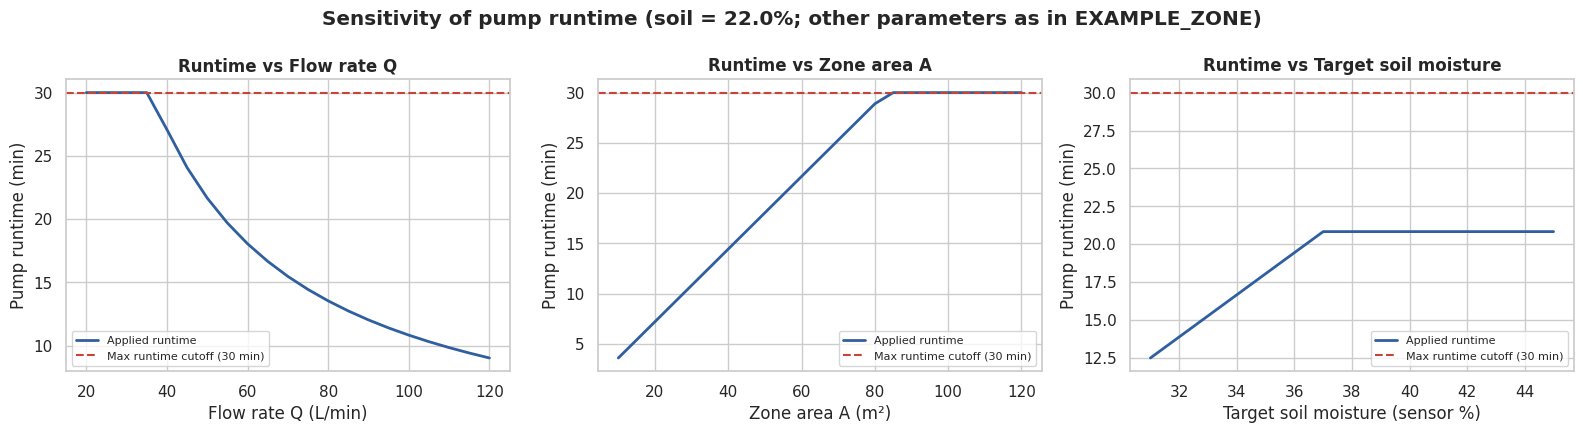

In [60]:
from dataclasses import replace

def runtime_curve(param, values):
    out = []
    for v in values:
        out.append(compute_irrigation(replace(EXAMPLE_ZONE, **{param: v}), SOIL_NOW)["runtime_applied_min"])
    return out

sweeps = [("flow_rate_lpm", np.linspace(20, 120, 21), "Flow rate Q (L/min)"),
          ("zone_area_m2", np.linspace(10, 120, 23), "Zone area A (m²)"),
          ("target_soil_moisture", np.linspace(31, 45, 15), "Target soil moisture (sensor %)")]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, (param, vals, label) in zip(axes, sweeps):
    ax.plot(vals, runtime_curve(param, vals), lw=2, color="#2F5F9E", label="Applied runtime")
    ax.axhline(EXAMPLE_ZONE.max_runtime_min, color="#C8443A", ls="--", label=f"Max runtime cutoff ({EXAMPLE_ZONE.max_runtime_min:g} min)")
    ax.set_title(f"Runtime vs {label.split(' (')[0]}"); ax.set_xlabel(label); ax.set_ylabel("Pump runtime (min)"); ax.legend(fontsize=8)
plt.suptitle(f"Sensitivity of pump runtime (soil = {SOIL_NOW}%; other parameters as in EXAMPLE_ZONE)", fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretation.**
* For a soil reading of 22 % and the example zone: deficit 13 percentage points → net depth 19.5 mm → gross depth 21.7 mm (efficiency 0.9) → volume 1,083 L over 50 m² → runtime **18.1 min** at 60 L/min.
* The independent route (m³ and seconds) gives the same volume and runtime, so the units are consistent. The “expected soil moisture after irrigation” equals the target by construction; it checks the equations against each other and is **not** a prediction of real soil behaviour.
* In the sensitivity plots, runtime falls as flow rate rises, rises with zone area and with the target moisture, and is limited by the 30-minute cutoff (and, for large targets, by the 25 mm per-event depth limit). This is how configuration — not the AI — determines *how long* the pump runs.

## Step 28 — Pump ON/OFF Logic

`plan_irrigation()` combines the AI output with the measured sensor value and the zone configuration. The checks run in this order and **the first failed check keeps the pump OFF**:

| Order | Check | If it fails |
|---|---|---|
| 1 | Configuration valid? | **OFF** (fail-safe) |
| 2 | Soil-moisture reading valid (number, 0–100)? | **OFF** (fail-safe) |
| 3 | AI output recognised (Low/Medium/High)? | **OFF** (fail-safe) |
| 4 | Flow/water-level monitor reports a fault? *(future hardware; inactive in this prototype)* | **OFF** |
| 5 | Inputs outside the model's training range, policy = `block`? | **OFF** *(policy `warn` continues with a warning)* |
| 6 | AI = **Low**? | **OFF** — irrigation not required |
| 7 | Measured soil moisture $\ge$ threshold? | **OFF** — sensor veto (soil already moist enough) |
| 8 | Daily-cycle limit / minimum interval since last cycle? | **OFF** — lockout (irrigation frequency) |
| 9 | Calculated runtime shorter than the minimum? | **OFF** — not worth starting |
| – | Otherwise (AI = Medium/High, soil below threshold) | **ON**, with runtime from Step 27 |

**When does the pump turn OFF after it has started?** The pump never simply stays on until the next AI prediction. During a cycle the controller keeps reading the soil sensor and stops at the **first** of: (1) planned volume/runtime delivered, (2) sensor reaches the target, (3) maximum-runtime cutoff, (4) *flow/water-level fault — proposed future hardware*. Step 29 demonstrates these in a simulation.

In [61]:
def plan_irrigation(ai_level, soil_now, cfg, *, now=None, history=None, outside_training_range=False,
                    ood_policy="warn", flow_ok=None):
    """Control decision for ONE zone. `ai_level` comes from the (fixed) ML model; everything else is control logic.
    Fail-safe: whenever anything is invalid or doubtful the pump stays OFF."""
    now = now or datetime.now()
    history = history or {"last_end": None, "events_today": 0}
    plan = {"zone_id": getattr(cfg, "zone_id", "?"), "ai_level": ai_level, "soil_now": soil_now, "pump": "OFF",
            "reason": "", "warnings": [], "calc": None, "runtime_min": 0.0, "stop_conditions": []}
    def off(reason): plan["reason"] = reason; return plan
    problems = validate_config(cfg)
    if problems:
        return off("FAIL-SAFE: invalid configuration -> " + "; ".join(problems))
    if soil_now is None or not isinstance(soil_now, (int, float)) or not math.isfinite(soil_now) or not 0 <= soil_now <= 100:
        return off(f"FAIL-SAFE: soil-moisture reading {soil_now!r} is invalid")
    if ai_level not in ("Low", "Medium", "High"):
        return off(f"FAIL-SAFE: unknown AI output {ai_level!r}")
    if flow_ok is False:
        return off("FAIL-SAFE: flow / water-level monitor reports a fault (future hardware)")
    if outside_training_range:
        if ood_policy == "block":
            return off("BLOCKED: inputs outside the model's training range (policy = block)")
        plan["warnings"].append("inputs outside the model's training range: the AI output is an extrapolation")
    if ai_level == "Low":
        return off("AI = Low: irrigation not required")
    if soil_now >= cfg.soil_moisture_threshold:
        return off(f"SENSOR VETO: AI = {ai_level}, but measured soil moisture {soil_now:.1f}% >= threshold {cfg.soil_moisture_threshold}%")
    if history["events_today"] >= cfg.max_events_per_day:
        return off(f"LOCKOUT: {history['events_today']} cycles already today (maximum {cfg.max_events_per_day})")
    if history["last_end"] is not None and now - history["last_end"] < timedelta(hours=cfg.min_interval_hours):
        wait = timedelta(hours=cfg.min_interval_hours) - (now - history["last_end"])
        return off(f"LOCKOUT: minimum interval {cfg.min_interval_hours} h not yet elapsed ({wait} remaining)")
    calc = compute_irrigation(cfg, soil_now)
    plan["calc"] = calc
    if calc["runtime_calculated_min"] < cfg.min_runtime_min:
        return off(f"NOT STARTED: calculated runtime {calc['runtime_calculated_min']:.2f} min is below the minimum {cfg.min_runtime_min} min")
    if calc["depth_capped"]:
        plan["warnings"].append(f"requested depth {calc['gross_depth_mm']:.1f} mm exceeds the per-event limit; limited to {MAX_EVENT_DEPTH_MM} mm")
    if calc["runtime_capped"]:
        plan["warnings"].append(f"calculated runtime {calc['runtime_calculated_min']:.1f} min exceeds the cutoff; limited to {calc['runtime_applied_min']:.1f} min")
    plan["pump"], plan["runtime_min"] = "ON", calc["runtime_applied_min"]
    plan["reason"] = f"AI = {ai_level} and measured soil moisture {soil_now:.1f}% < threshold {cfg.soil_moisture_threshold}%"
    plan["stop_conditions"] = [f"1. planned volume delivered (~{calc['runtime_calculated_min']:.1f} min at {cfg.flow_rate_lpm} L/min)",
                               f"2. sensor reaches target {cfg.target_soil_moisture}%",
                               f"3. maximum runtime cutoff {min(cfg.max_runtime_min, ABSOLUTE_MAX_RUNTIME_MIN)} min",
                               "4. flow / water-level fault (future hardware - inactive)"]
    return plan

def explain_decision(plan):
    """Plain-language explanation of one control decision."""
    lines = [f"Zone {plan['zone_id']}: AI inference = {plan['ai_level']} | measured soil moisture = {plan['soil_now']}%",
             f"  Pump: {plan['pump']}   ({plan['reason']})"]
    c = plan["calc"]
    if c and plan["pump"] == "ON":
        lines += [f"  Moisture deficit      = target - current       = {c['deficit_pct_points']:.1f} % points",
                  f"  Net depth             = Kc x Ks x deficit x root = {c['net_depth_mm']:.1f} mm",
                  f"  Gross depth           = net / efficiency        = {c['gross_depth_mm']:.1f} mm (used: {c['gross_depth_used_mm']:.1f} mm)",
                  f"  Volume                = area x depth            = {c['volume_required_L']:.0f} L",
                  f"  Runtime               = volume / flow rate      = {c['runtime_calculated_min']:.1f} min (applied: {c['runtime_applied_min']:.1f} min)"]
    lines += [f"  Warning: {w}" for w in plan["warnings"]]
    lines += [f"  Stop when: {s}" for s in plan["stop_conditions"]]
    return "\n".join(lines)


In [62]:
ZONE = EXAMPLE_ZONE
now = datetime(2026, 10, 3, 12, 0)
fresh = {"last_end": None, "events_today": 0}
tiny_deficit_zone = make_config(**{**asdict(ZONE), "soil_moisture_threshold": 30.0, "target_soil_moisture": 30.2})

cases = [
    ("AI Low, dry soil (18 %)",                          dict(ai_level="Low",    soil_now=18.0, cfg=ZONE)),
    ("AI Medium, soil 22 % < threshold",                 dict(ai_level="Medium", soil_now=22.0, cfg=ZONE)),
    ("AI High, soil 12 % < threshold",                   dict(ai_level="High",   soil_now=12.0, cfg=ZONE)),
    ("AI High but soil 33 % >= threshold (sensor veto)", dict(ai_level="High",   soil_now=33.0, cfg=ZONE)),
    ("AI Medium, previous cycle ended 2 h ago",          dict(ai_level="Medium", soil_now=22.0, cfg=ZONE, history={"last_end": now - timedelta(hours=2), "events_today": 1})),
    ("AI Medium, already 2 cycles today",                dict(ai_level="Medium", soil_now=22.0, cfg=ZONE, history={"last_end": now - timedelta(hours=9), "events_today": 2})),
    ("AI Medium, soil sensor returned NaN",              dict(ai_level="Medium", soil_now=float("nan"), cfg=ZONE)),
    ("AI Medium, soil sensor returned 140 %",            dict(ai_level="Medium", soil_now=140.0, cfg=ZONE)),
    ("AI Medium, input outside training range, policy = block", dict(ai_level="Medium", soil_now=2.0, cfg=ZONE, outside_training_range=True, ood_policy="block")),
    ("AI Medium, input outside training range, policy = warn",  dict(ai_level="Medium", soil_now=2.0, cfg=ZONE, outside_training_range=True, ood_policy="warn")),
    ("AI High, flow monitor reports a fault (future hardware)", dict(ai_level="High", soil_now=15.0, cfg=ZONE, flow_ok=False)),
    ("AI Medium, deficit too small (runtime < minimum)", dict(ai_level="Medium", soil_now=29.9, cfg=tiny_deficit_zone)),
    ("AI High, invalid configuration object",            dict(ai_level="High",   soil_now=15.0, cfg=unsafe)),
]
branch_rows = []
for label, kw in cases:
    kw.setdefault("history", fresh)
    p = plan_irrigation(now=now, **kw)
    branch_rows.append({"Situation": label, "Pump": p["pump"], "Runtime (min)": round(p["runtime_min"], 1) if p["pump"] == "ON" else "-",
                        "Reason / warnings": p["reason"][:105] + (" | WARN: " + "; ".join(p["warnings"])[:60] if p["warnings"] else "")})
branch_table = pd.DataFrame(branch_rows)
pd.set_option("display.max_colwidth", 190)
display(branch_table)

print("\nUnvalidated configuration with max_runtime_min = 9999 (built directly, bypassing make_config):")
print("  planner decision ->", plan_irrigation("High", 20.0, unsafe, now=now)["pump"], "|", plan_irrigation("High", 20.0, unsafe, now=now)["reason"][:80], "...")
print("  runtime if the calculation is called directly ->", round(compute_irrigation(unsafe, 20.0)["runtime_applied_min"], 1),
      f"min (never above the hard cutoff of {ABSOLUTE_MAX_RUNTIME_MIN:g} min)")

print("\nPlain-language explanation of one ON decision:\n")
print(explain_decision(plan_irrigation("High", 12.0, ZONE, now=now)))

,Situation,Pump,Runtime (min),Reason / warnings
0,"AI Low, dry soil (18 %)",OFF,-,AI = Low: irrigation not required
1,"AI Medium, soil 22 % < threshold",ON,18.1,AI = Medium and measured soil moisture 22.0% < threshold 30.0%
2,"AI High, soil 12 % < threshold",ON,20.8,AI = High and measured soil moisture 12.0% < threshold 30.0% | WARN: requested depth 38.3 mm exceeds the per-event limit; limited
3,AI High but soil 33 % >= threshold (sensor veto),OFF,-,"SENSOR VETO: AI = High, but measured soil moisture 33.0% >= threshold 30.0%"
4,"AI Medium, previous cycle ended 2 h ago",OFF,-,LOCKOUT: minimum interval 6.0 h not yet elapsed (4:00:00 remaining)
5,"AI Medium, already 2 cycles today",OFF,-,LOCKOUT: 2 cycles already today (maximum 2)
6,"AI Medium, soil sensor returned NaN",OFF,-,FAIL-SAFE: soil-moisture reading nan is invalid
7,"AI Medium, soil sensor returned 140 %",OFF,-,FAIL-SAFE: soil-moisture reading 140.0 is invalid
8,"AI Medium, input outside training range, policy = block",OFF,-,BLOCKED: inputs outside the model's training range (policy = block)
9,"AI Medium, input outside training range, policy = warn",ON,20.8,AI = Medium and measured soil moisture 2.0% < threshold 30.0% | WARN: inputs outside the model's training range: the AI output is



Unvalidated configuration with max_runtime_min = 9999 (built directly, bypassing make_config):
  planner decision -> OFF | FAIL-SAFE: invalid configuration -> max_runtime_min=9999.0 is outside the allowe ...
  runtime if the calculation is called directly -> 20.8 min (never above the hard cutoff of 120 min)

Plain-language explanation of one ON decision:

Zone Example zone: AI inference = High | measured soil moisture = 12.0%
  Pump: ON   (AI = High and measured soil moisture 12.0% < threshold 30.0%)
  Moisture deficit      = target - current       = 23.0 % points
  Net depth             = Kc x Ks x deficit x root = 34.5 mm
  Gross depth           = net / efficiency        = 38.3 mm (used: 25.0 mm)
  Volume                = area x depth            = 1250 L
  Runtime               = volume / flow rate      = 20.8 min (applied: 20.8 min)
  Stop when: 1. planned volume delivered (~20.8 min at 60.0 L/min)
  Stop when: 2. sensor reaches target 35.0%
  Stop when: 3. maximum runtime cutoff 3

**Interpretation.** Of the 13 situations, the pump turns ON in only three (AI Medium with soil 22 %, AI High with soil 12 %, and AI Medium with an out-of-range input under policy `warn`). Every other case stays **OFF with a stated reason**: AI Low, sensor veto (soil already above threshold), interval lockout, daily-cycle limit, invalid sensor values (NaN, 140 %), out-of-range input under policy `block`, flow-monitor fault (future hardware hook), a cycle too short to start, and an invalid configuration. For soil at 12 % the requested depth (38.3 mm) exceeds the 25 mm per-event limit and is limited, giving 20.8 min.

## Step 29 — Closed-Loop Architecture and Safety Cutoffs

After the pump starts, the controller keeps measuring and re-evaluating — it does **not** wait for the next AI prediction to stop. This is a **closed-loop** design: sensor feedback decides whether to continue or stop.

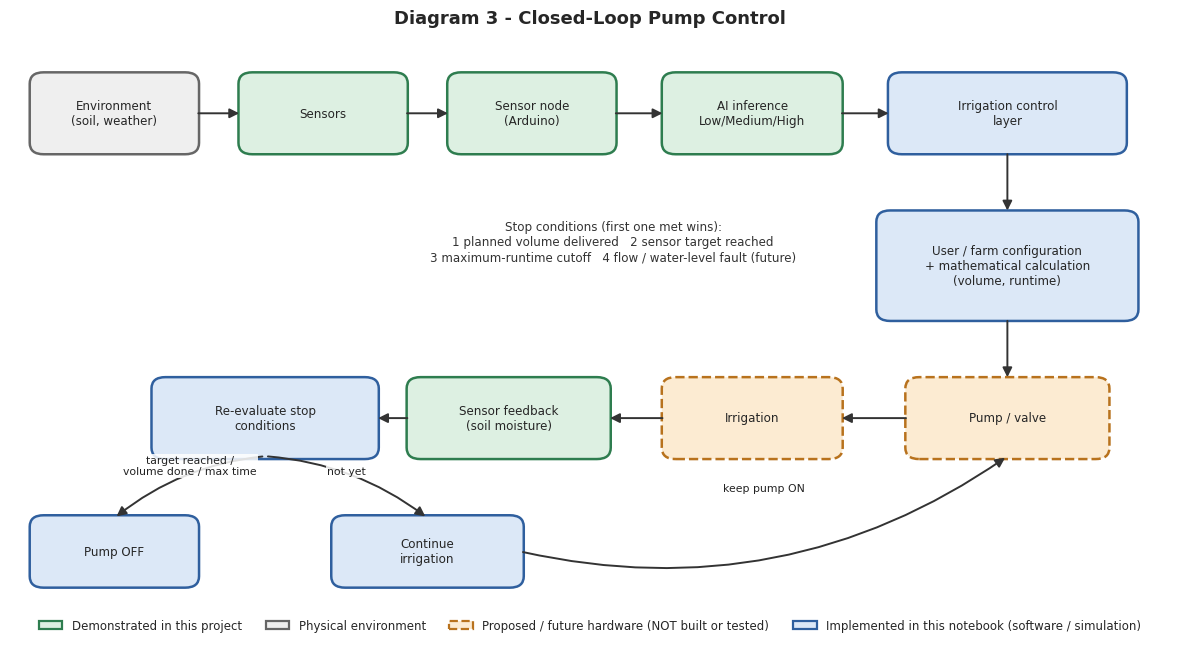

In [63]:
# DIAGRAM 3 - closed-loop pump control
boxes = {
    "env":    (9, 54, 14, 8,  "Environment\n(soil, weather)", "ext"),
    "sens":   (27, 54, 14, 8, "Sensors", "demo"),
    "node":   (45, 54, 14, 8, "Sensor node\n(Arduino)", "demo"),
    "ai":     (64, 54, 15, 8, "AI inference\nLow/Medium/High", "demo"),
    "ctrl":   (86, 54, 20, 8, "Irrigation control\nlayer", "soft"),
    "cfgm":   (86, 38, 22, 11, "User / farm configuration\n+ mathematical calculation\n(volume, runtime)", "soft"),
    "pump":   (86, 22, 17, 8, "Pump / valve", "prop"),
    "irr":    (64, 22, 15, 8, "Irrigation", "prop"),
    "fb":     (43, 22, 17, 8, "Sensor feedback\n(soil moisture)", "demo"),
    "reeval": (22, 22, 19, 8, "Re-evaluate stop\nconditions", "soft"),
    "off":    (9, 8, 14, 7,   "Pump OFF", "soft"),
    "cont":   (36, 8, 16, 7,  "Continue\nirrigation", "soft"),
}
arrows = [("env", "right", "sens", "left", "", 0), ("sens", "right", "node", "left", "", 0), ("node", "right", "ai", "left", "", 0),
          ("ai", "right", "ctrl", "left", "", 0), ("ctrl", "bottom", "cfgm", "top", "", 0), ("cfgm", "bottom", "pump", "top", "", 0),
          ("pump", "left", "irr", "right", "", 0), ("irr", "left", "fb", "right", "", 0), ("fb", "left", "reeval", "right", "", 0),
          ("reeval", "bottom", "off", "top", "target reached /\nvolume done / max time", 0.15),
          ("reeval", "bottom", "cont", "top", "not yet", -0.15), ("cont", "right", "pump", "bottom", "keep pump ON", 0.22)]
draw_diagram("Diagram 3 - Closed-Loop Pump Control", boxes, arrows, ylim=(2, 62), figsize=(13, 6.6),
             notes=[(52, 40.5, "Stop conditions (first one met wins):\n1 planned volume delivered   2 sensor target reached\n3 maximum-runtime cutoff   4 flow / water-level fault (future)")])


### 29.1 Simulation of the stop conditions

> **ILLUSTRATIVE SIMULATION — not an experiment and not a field result.** A simple “soil bucket” stands in for the field (water added → soil moisture rises; no drainage, evaporation or rain). The *controller* plans with its configured parameters, but the *simulated soil* is allowed to respond differently — exactly the situation in a real field where configuration is only approximately right. The point is to show **which stop condition ends the cycle** in each situation, not to predict real soil behaviour.

| Case | What is assumed about the simulated field | What it demonstrates |
|---|---|---|
| 1 | Soil responds *more* strongly than the controller assumed; sensor reads with a 30 s lag | Stop condition 2 (sensor reaches target), and overshoot caused by sensor delay |
| 2 | Soil responds *less* strongly than assumed | Stop condition 1 (planned volume delivered) before the target is reached → re-evaluate later |
| 3 | **Fault injection:** sensor frozen, and both normal stop conditions disabled | Stop condition 3 — the maximum-runtime safety cutoff still switches the pump off |
| 4 | A configuration whose requirement exceeds the cutoff (large zone, modest flow) | The runtime is limited by the cutoff, as flagged by the planner |

In [64]:
import numpy as np

def simulate_closed_loop(cfg, soil_start, plan, *, true_root_zone_mm, true_efficiency=None, sensor_lag_s=0.0,
                         sensor_stuck=False, flow_factor=1.0, disable_target_stop=False, disable_planned_stop=False,
                         dt_s=10, post_min=6.0):
    """ILLUSTRATIVE simulation (not an experiment). A simple soil-water bucket stands in for the real field:
         water delivered (L) = Q_actual * dt ;  depth (mm) = L / A ;  soil rise (% points) = depth * Ea_true / root_true * 100
       Drainage, evaporation and rain are ignored. The controller only sees the (possibly lagged / stuck) sensor reading."""
    assert plan["pump"] == "ON", "nothing to simulate: the plan keeps the pump OFF"
    c = plan["calc"]
    Ea_true = cfg.application_efficiency if true_efficiency is None else true_efficiency
    cap_min = min(cfg.max_runtime_min, ABSOLUTE_MAX_RUNTIME_MIN)
    planned_min = c["runtime_calculated_min"]
    t, soil, read, vol, pump = [0.0], [soil_start], [soil_start], [0.0], [1]
    stop_reason, stop_t, k = None, None, 0
    while True:
        k += 1; el = k * dt_s / 60.0
        on = stop_reason is None
        if on:
            dL = cfg.flow_rate_lpm * flow_factor * dt_s / 60.0
            soil.append(soil[-1] + (dL / cfg.zone_area_m2) * Ea_true / true_root_zone_mm * 100.0)
            vol.append(vol[-1] + dL)
        else:
            soil.append(soil[-1]); vol.append(vol[-1])
        if sensor_stuck:
            read.append(soil_start)
        elif sensor_lag_s > 0:
            read.append(read[-1] + (soil[-1] - read[-1]) * min(1.0, dt_s / sensor_lag_s))
        else:
            read.append(soil[-1])
        t.append(el)
        if on:                                    # stop conditions, checked in priority order after each step
            if el >= cap_min - 1e-9:
                stop_reason, stop_t = "3. MAX RUNTIME cutoff", el
            elif not disable_target_stop and read[-1] >= cfg.target_soil_moisture:
                stop_reason, stop_t = "2. SENSOR TARGET reached", el
            elif not disable_planned_stop and el >= planned_min - 1e-9:
                stop_reason, stop_t = "1. PLANNED VOLUME delivered", el
        pump.append(1 if on and stop_reason is None else 0)
        if stop_reason is not None and el >= stop_t + post_min:
            break
    return {"t": np.array(t), "soil_true": np.array(soil), "soil_read": np.array(read), "volume_L": np.array(vol),
            "pump": np.array(pump), "stop_reason": stop_reason, "stop_min": stop_t,
            "volume_delivered_L": vol[int(round(stop_t * 60 / dt_s))], "final_true": soil[int(round(stop_t * 60 / dt_s))],
            "final_read_at_end": read[-1], "soil_at_end": soil[-1]}


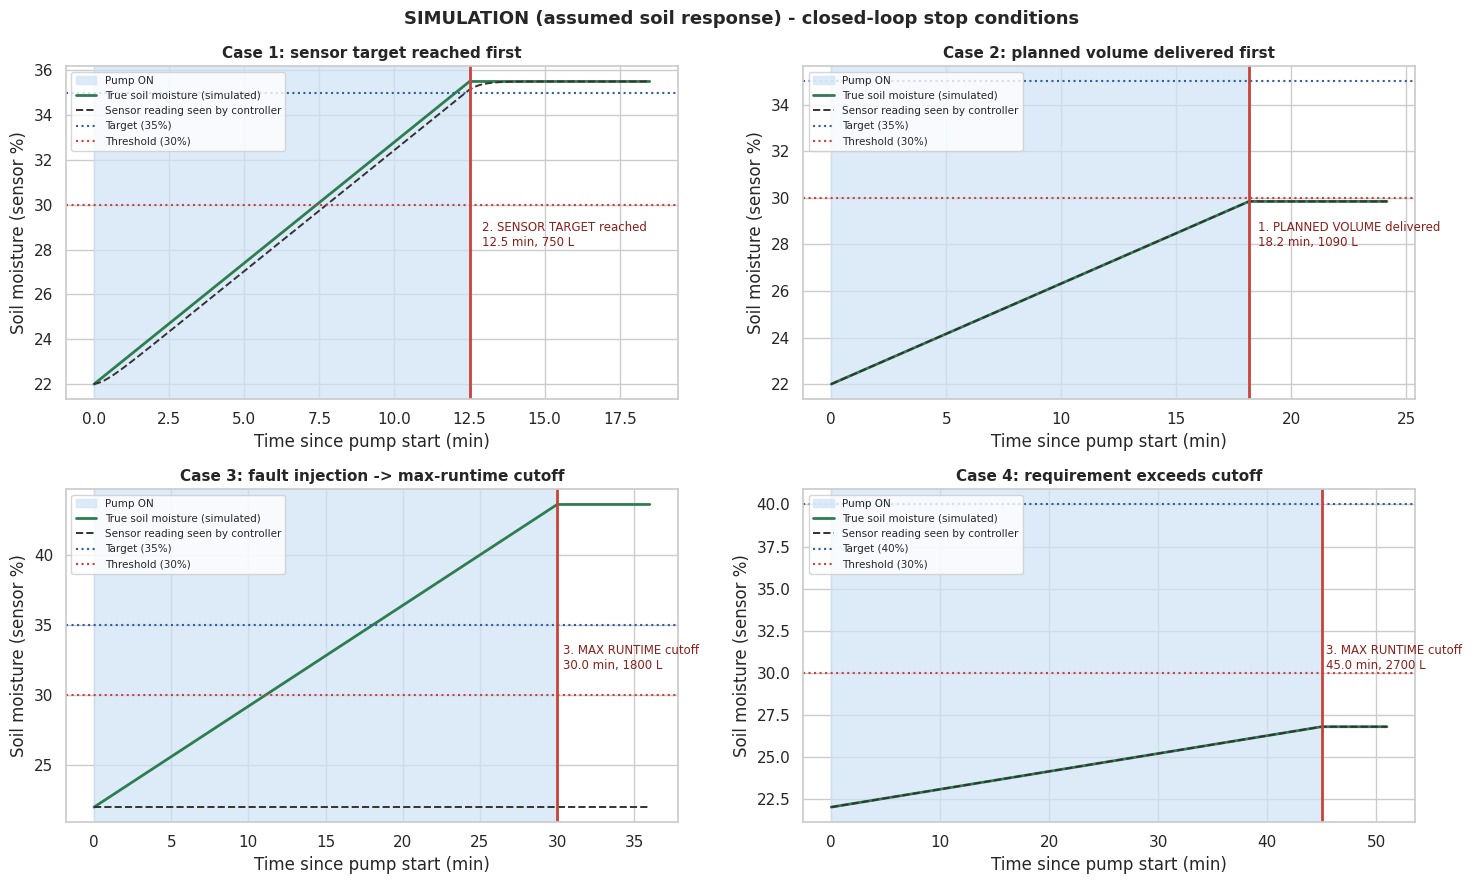

,Case,Stop condition that ended the cycle,Pump ran (min),Planned runtime (min),Cutoff (min),Water used (L),True soil at stop (%),Target (%)
0,Case 1,2. SENSOR TARGET reached,12.5,18.1,30.0,750,35.5,35.0
1,Case 2,1. PLANNED VOLUME delivered,18.2,18.1,30.0,1090,29.8,35.0
2,Case 3,3. MAX RUNTIME cutoff,30.0,18.1,30.0,1800,43.6,35.0
3,Case 4,3. MAX RUNTIME cutoff,45.0,166.7,45.0,2700,26.8,40.0


In [65]:
BIG_ZONE = make_config(**{**asdict(EXAMPLE_ZONE), "zone_id": "Large zone", "zone_area_m2": 400.0, "root_zone_depth_mm": 120.0,
                          "target_soil_moisture": 40.0, "application_efficiency": 0.85, "max_runtime_min": 45.0})
SOIL_START = 22.0
plan_small = plan_irrigation("High", SOIL_START, EXAMPLE_ZONE, now=now)
plan_big = plan_irrigation("High", SOIL_START, BIG_ZONE, now=now)

sim_cases = [
    ("Case 1: sensor target reached first", EXAMPLE_ZONE, plan_small, dict(true_root_zone_mm=100.0, sensor_lag_s=30.0)),
    ("Case 2: planned volume delivered first", EXAMPLE_ZONE, plan_small, dict(true_root_zone_mm=250.0)),
    ("Case 3: fault injection -> max-runtime cutoff", EXAMPLE_ZONE, plan_small,
     dict(true_root_zone_mm=150.0, sensor_stuck=True, disable_target_stop=True, disable_planned_stop=True)),
    ("Case 4: requirement exceeds cutoff", BIG_ZONE, plan_big, dict(true_root_zone_mm=120.0)),
]
sim_results, sim_rows = [], []
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=False)
for ax, (title, cfg, pl, kw) in zip(axes.ravel(), sim_cases):
    r = simulate_closed_loop(cfg, SOIL_START, pl, **kw)
    sim_results.append((cfg, r))
    ax.axvspan(0, r["stop_min"], color="#CFE3F7", alpha=0.7, label="Pump ON")
    ax.plot(r["t"], r["soil_true"], color="#2E7D4F", lw=2, label="True soil moisture (simulated)")
    ax.plot(r["t"], r["soil_read"], color="#333333", lw=1.4, ls="--", label="Sensor reading seen by controller")
    ax.axhline(cfg.target_soil_moisture, color="#2F5F9E", ls=":", label=f"Target ({cfg.target_soil_moisture:g}%)")
    ax.axhline(cfg.soil_moisture_threshold, color="#C8443A", ls=":", label=f"Threshold ({cfg.soil_moisture_threshold:g}%)")
    ax.axvline(r["stop_min"], color="#C8443A", lw=2)
    y0, y1 = ax.get_ylim()
    ax.text(r["stop_min"] + 0.4, y0 + 0.45 * (y1 - y0), r["stop_reason"] + f"\n{r['stop_min']:.1f} min, {r['volume_delivered_L']:.0f} L",
            fontsize=8.5, color="#8A1F18", va="bottom")
    ax.set_title(title, fontsize=11); ax.set_xlabel("Time since pump start (min)"); ax.set_ylabel("Soil moisture (sensor %)"); ax.legend(fontsize=7.5, loc="upper left")
    sim_rows.append({"Case": title.split(":")[0], "Stop condition that ended the cycle": r["stop_reason"], "Pump ran (min)": round(r["stop_min"], 1),
                     "Planned runtime (min)": round(pl["calc"]["runtime_calculated_min"], 1), "Cutoff (min)": min(cfg.max_runtime_min, ABSOLUTE_MAX_RUNTIME_MIN),
                     "Water used (L)": round(r["volume_delivered_L"]), "True soil at stop (%)": round(r["final_true"], 1),
                     "Target (%)": cfg.target_soil_moisture})
plt.suptitle("SIMULATION (assumed soil response) - closed-loop stop conditions", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()
sim_table = pd.DataFrame(sim_rows); display(sim_table)

**Interpretation (all four cases are simulations with an assumed soil response, not experiments).**
* **Case 1:** the sensor reached the target after **12.5 min**, earlier than the planned 18.1 min (750 L), saving water. The 30 s sensor lag let the true soil moisture overshoot slightly (35.5 % vs target 35 %).
* **Case 2:** the planned volume was delivered at **18.2 min** (1,090 L) but the simulated soil rose only to 29.8 %, below the 35 % target and below the 30 % threshold. The cycle ends anyway and the situation would be re-evaluated after the minimum interval.
* **Case 3 (fault injection):** with a frozen sensor and both normal stop conditions disabled, the **maximum-runtime cutoff** ended the cycle at 30 min (1,800 L). The cutoff limits the damage but does not remove it: the simulated soil ended 8.6 points above the target. This is why a flow sensor and a local hardware timer are recommended for a real system.
* **Case 4:** the requirement (166.7 min) far exceeded the 45-minute cutoff, so the cycle was limited to 45 min (2,700 L) and the soil only reached 26.8 % of a 40 % target. The cutoff protected the system, but such a result also signals that area, flow rate and cutoff in the configuration do not match.

## Step 30 — Same AI Model, Different Farm Configurations (Scenarios A and B)

> **Illustrative configuration scenarios — not universal agronomic recommendations.** The values below are hypothetical placeholders chosen only to show that changing *control* parameters changes the *control decision*, while the AI model stays exactly the same.

Both scenarios receive the **same sensor input** (a test input, not a measurement) and use the **same, unchanged** trained model. The model is fingerprinted (SHA-256 of its serialised form) before and after to show that nothing was retrained or modified.

Scenario,Scenario A,Scenario B
AI output,High,High
Area (m²),50.0,120.0
Threshold/Target (%),30 / 35,28 / 38
Kc,1.0,1.1
Efficiency,0.9,0.75
Flow (L/min),60.0,80.0
Max runtime (min),30.0,40.0
Gross depth (mm),21.7,23.5
Volume (L),1083,2816
Runtime (min),18.1,35.2


Model fingerprint before: 98f940706ee8b348fb33 ...
Model fingerprint after : 98f940706ee8b348fb33 ...   identical: True


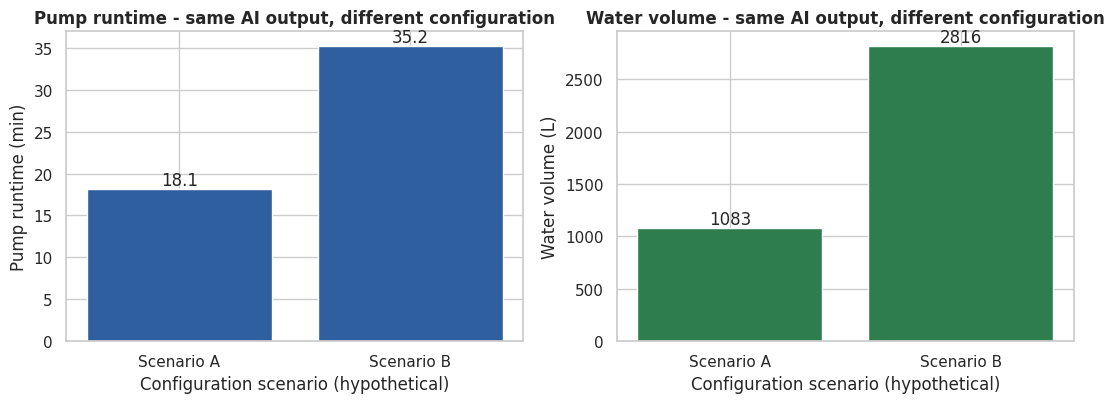

In [66]:
SCENARIO_A = make_config(**{**asdict(EXAMPLE_ZONE), "zone_id": "Scenario A"})
SCENARIO_B = make_config(
    zone_id="Scenario B",
    zone_area_m2=120.0, soil_moisture_threshold=28.0, target_soil_moisture=38.0,
    depth_mode="deficit", fixed_water_depth_mm=5.0, root_zone_depth_mm=100.0,
    crop_coefficient=1.1, soil_adjustment_coefficient=1.0, application_efficiency=0.75,
    flow_rate_lpm=80.0, min_runtime_min=1.0, max_runtime_min=40.0, min_interval_hours=6.0, max_events_per_day=2)

TEST_INPUT = {"Soil_Moisture": 22.0, "Temperature_C": 32.0, "Humidity": 55.0}      # TEST INPUT, not a real measurement
x_new = pd.DataFrame([TEST_INPUT], columns=FEATURES)

fingerprint_before = hashlib.sha256(pickle.dumps(frozen_model)).hexdigest()
scenario_rows, scenario_plans = [], {}
for sc in (SCENARIO_A, SCENARIO_B):
    ai_level = frozen_model.predict(x_new)[0]                                      # SAME model, SAME input
    p = plan_irrigation(ai_level, TEST_INPUT["Soil_Moisture"], sc, now=now)
    scenario_plans[sc.zone_id] = p
    c = p["calc"]
    scenario_rows.append({"Scenario": sc.zone_id, "AI output": ai_level, "Area (m²)": sc.zone_area_m2, "Threshold/Target (%)": f"{sc.soil_moisture_threshold:g} / {sc.target_soil_moisture:g}",
                          "Kc": sc.crop_coefficient, "Efficiency": sc.application_efficiency, "Flow (L/min)": sc.flow_rate_lpm, "Max runtime (min)": sc.max_runtime_min,
                          "Gross depth (mm)": round(c["gross_depth_used_mm"], 1), "Volume (L)": round(c["volume_required_L"]), "Runtime (min)": round(p["runtime_min"], 1),
                          "Pump": p["pump"], "Runtime capped?": c["runtime_capped"]})
fingerprint_after = hashlib.sha256(pickle.dumps(frozen_model)).hexdigest()
scenario_table = pd.DataFrame(scenario_rows).set_index("Scenario").T
display(scenario_table)
print("Model fingerprint before:", fingerprint_before[:20], "...")
print("Model fingerprint after :", fingerprint_after[:20], "...   identical:", fingerprint_before == fingerprint_after)
assert fingerprint_before == fingerprint_after
assert scenario_rows[0]["AI output"] == scenario_rows[1]["AI output"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
names = [r["Scenario"] for r in scenario_rows]
for ax, key, ylabel, colour in [(axes[0], "Runtime (min)", "Pump runtime (min)", "#2F5F9E"), (axes[1], "Volume (L)", "Water volume (L)", "#2E7D4F")]:
    bars = ax.bar(names, [r[key] for r in scenario_rows], color=colour)
    for b in bars: ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():g}", ha="center", va="bottom")
    ax.set_title(f"{ylabel.split(' (')[0]} - same AI output, different configuration"); ax.set_xlabel("Configuration scenario (hypothetical)"); ax.set_ylabel(ylabel)
plt.tight_layout(); plt.show()

**Interpretation.** The **same test input** (22 % soil moisture, 32 °C, 55 % humidity — not a measurement) gave the **same AI output (High)** in both scenarios, and the model fingerprint is identical before and after, so the AI was not retrained or changed. The control result differs only because the *configuration* differs: Scenario A → 18.1 min and 1,083 L; Scenario B (larger area, different target, crop factor, efficiency and flow) → 35.2 min and 2,816 L. These scenario values are hypothetical illustrations, not agronomic recommendations.

## Step 31 — Real Sensor Data → AI Inference → Control Layer

For every real reading the notebook now:
1. takes `Soil_Moisture + Temperature_C + Humidity`,
2. sends them to the **unchanged** Decision Tree → `Low / Medium / High` (done in Step 23),
3. passes the **AI prediction + soil reading** to the control layer together with a zone configuration,
4. calculates the proposed irrigation amount/runtime, and
5. produces the **proposed** pump state and an explanation.

> **Nothing is switched.** No relay, valve or pump is connected; the output is a *proposal*. Every row is evaluated independently, as if it were the first irrigation cycle (the real log contains no record of an actual pump run, so lockout history and sensor feedback cannot be reconstructed from it).
>
> `REAL_ZONE` below is a **hypothetical** plot (placeholder values): the real field area, flow rate and targets must be entered by the operator.

In [67]:
REAL_ZONE = make_config(
    zone_id="Prototype plot (placeholder values)",
    zone_area_m2=20.0, soil_moisture_threshold=30.0, target_soil_moisture=40.0, depth_mode="deficit", fixed_water_depth_mm=5.0,
    root_zone_depth_mm=100.0, crop_coefficient=1.0, soil_adjustment_coefficient=1.0, application_efficiency=0.85,
    flow_rate_lpm=10.0, min_runtime_min=1.0, max_runtime_min=30.0, min_interval_hours=6.0, max_events_per_day=2)
OOD_POLICY = "warn"       # "warn": proceed but flag readings outside the training range ; "block": keep the pump OFF for them

control_rows = []
for idx, row in real_data.iterrows():
    p = plan_irrigation(row["Irrigation_Need"], float(row["Soil_Moisture"]), REAL_ZONE, now=now,
                        outside_training_range=bool(row["Outside_Training_Range"]), ood_policy=OOD_POLICY)
    c = p["calc"]
    control_rows.append({"AI_Level": p["ai_level"], "Control_Pump": p["pump"], "Proposed_Runtime_min": round(p["runtime_min"], 1),
                         "Proposed_Volume_L": round(p["runtime_min"] * REAL_ZONE.flow_rate_lpm, 0) if p["pump"] == "ON" else 0.0,
                         "Depth_limited": bool(c and c["depth_capped"]), "Runtime_limited": bool(c and c["runtime_capped"]),
                         "Flags": "; ".join(p["warnings"]) if p["warnings"] else "", "Reason": p["reason"]})
control_df = pd.concat([real_data[["Soil_Moisture", "Temperature_C", "Humidity", "Outside_Training_Range"]].reset_index(drop=True),
                        pd.DataFrame(control_rows)], axis=1)
display(control_df.head(8))
print("\nAI level  ->  control-layer pump state (rows):")
display(pd.crosstab(control_df["AI_Level"], control_df["Control_Pump"], margins=True))
print("AI-only mapping (Step 23) vs control layer:")
display(pd.crosstab(real_data["Pump_Action"].reset_index(drop=True).rename("AI-only"), control_df["Control_Pump"].rename("Control layer")))

,Soil_Moisture,Temperature_C,Humidity,Outside_Training_Range,AI_Level,Control_Pump,Proposed_Runtime_min,Proposed_Volume_L,Depth_limited,Runtime_limited,Flags,Reason
0,0.2,25.6,89.1,True,Medium,ON,30.0,300.0,True,True,inputs outside the model's training range: the AI output is an extrapolation; requested depth 46.8 mm exceeds the per-event limit; limited to 25.0 mm; calculated runtime 50.0 min exceeds...,AI = Medium and measured soil moisture 0.2% < threshold 30.0%
1,0.2,25.7,89.6,True,Medium,ON,30.0,300.0,True,True,inputs outside the model's training range: the AI output is an extrapolation; requested depth 46.8 mm exceeds the per-event limit; limited to 25.0 mm; calculated runtime 50.0 min exceeds...,AI = Medium and measured soil moisture 0.2% < threshold 30.0%
2,0.5,25.7,89.6,True,Medium,ON,30.0,300.0,True,True,inputs outside the model's training range: the AI output is an extrapolation; requested depth 46.5 mm exceeds the per-event limit; limited to 25.0 mm; calculated runtime 50.0 min exceeds...,AI = Medium and measured soil moisture 0.5% < threshold 30.0%
3,0.2,25.7,89.3,True,Medium,ON,30.0,300.0,True,True,inputs outside the model's training range: the AI output is an extrapolation; requested depth 46.8 mm exceeds the per-event limit; limited to 25.0 mm; calculated runtime 50.0 min exceeds...,AI = Medium and measured soil moisture 0.2% < threshold 30.0%
4,0.2,25.7,89.3,True,Medium,ON,30.0,300.0,True,True,inputs outside the model's training range: the AI output is an extrapolation; requested depth 46.8 mm exceeds the per-event limit; limited to 25.0 mm; calculated runtime 50.0 min exceeds...,AI = Medium and measured soil moisture 0.2% < threshold 30.0%
5,0.0,25.7,89.3,True,Medium,ON,30.0,300.0,True,True,inputs outside the model's training range: the AI output is an extrapolation; requested depth 47.1 mm exceeds the per-event limit; limited to 25.0 mm; calculated runtime 50.0 min exceeds...,AI = Medium and measured soil moisture 0.0% < threshold 30.0%
6,0.0,25.7,89.3,True,Medium,ON,30.0,300.0,True,True,inputs outside the model's training range: the AI output is an extrapolation; requested depth 47.1 mm exceeds the per-event limit; limited to 25.0 mm; calculated runtime 50.0 min exceeds...,AI = Medium and measured soil moisture 0.0% < threshold 30.0%
7,0.5,25.7,89.3,True,Medium,ON,30.0,300.0,True,True,inputs outside the model's training range: the AI output is an extrapolation; requested depth 46.5 mm exceeds the per-event limit; limited to 25.0 mm; calculated runtime 50.0 min exceeds...,AI = Medium and measured soil moisture 0.5% < threshold 30.0%



AI level  ->  control-layer pump state (rows):


Control_Pump,OFF,ON,All
AI_Level,,,
Low,3,0,3
Medium,0,27,27
All,3,27,30


AI-only mapping (Step 23) vs control layer:


Control layer,OFF,ON
AI-only,,
OFF,3,0
ON,0,27


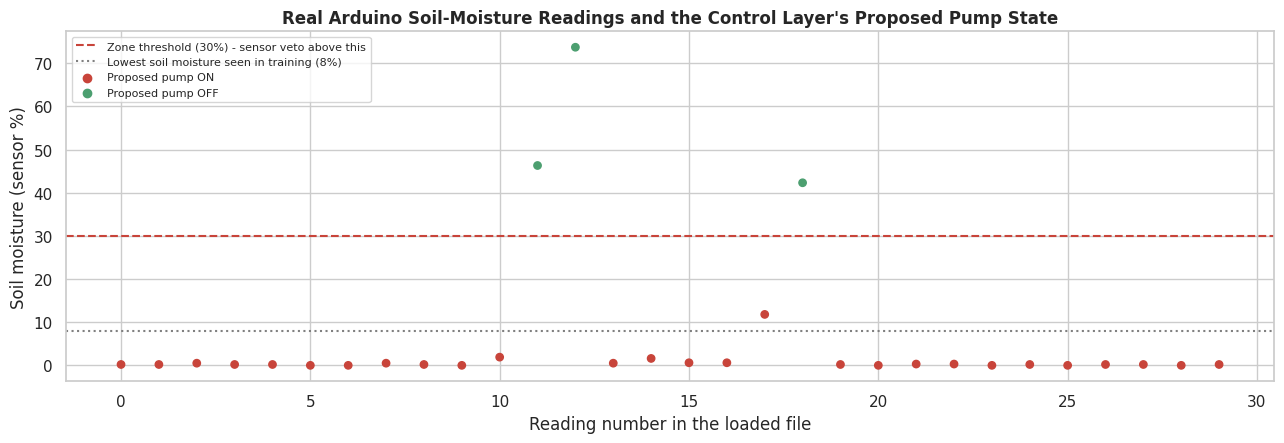

Explanation of one ON proposal:

Zone Prototype plot (placeholder values): AI inference = Medium | measured soil moisture = 0.2%
  Pump: ON   (AI = Medium and measured soil moisture 0.2% < threshold 30.0%)
  Moisture deficit      = target - current       = 39.8 % points
  Net depth             = Kc x Ks x deficit x root = 39.8 mm
  Gross depth           = net / efficiency        = 46.8 mm (used: 25.0 mm)
  Volume                = area x depth            = 500 L
  Runtime               = volume / flow rate      = 50.0 min (applied: 30.0 min)
  Stop when: 1. planned volume delivered (~50.0 min at 10.0 L/min)
  Stop when: 2. sensor reaches target 40.0%
  Stop when: 3. maximum runtime cutoff 30.0 min
  Stop when: 4. flow / water-level fault (future hardware - inactive)

Explanation of one OFF proposal:

Zone Prototype plot (placeholder values): AI inference = Low | measured soil moisture = 46.3%
  Pump: OFF   (AI = Low: irrigation not required)


In [68]:
fig, ax = plt.subplots(figsize=(13, 4.6))
colours = {"ON": "#C8443A", "OFF": "#4C9F70"}
ax.scatter(control_df.index, control_df["Soil_Moisture"], c=control_df["Control_Pump"].map(colours), s=28, zorder=3)
ax.axhline(REAL_ZONE.soil_moisture_threshold, color="#C8443A", ls="--", label=f"Zone threshold ({REAL_ZONE.soil_moisture_threshold:g}%) - sensor veto above this")
ax.axhline(TRAIN_RANGES["Soil_Moisture"][0], color="grey", ls=":", label=f"Lowest soil moisture seen in training ({TRAIN_RANGES['Soil_Moisture'][0]:g}%)")
ax.scatter([], [], c=colours["ON"], label="Proposed pump ON"); ax.scatter([], [], c=colours["OFF"], label="Proposed pump OFF")
ax.set_title("Real Arduino Soil-Moisture Readings and the Control Layer's Proposed Pump State")
ax.set_xlabel("Reading number in the loaded file"); ax.set_ylabel("Soil moisture (sensor %)"); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

on_rows = control_df[control_df["Control_Pump"] == "ON"]
off_rows = control_df[control_df["Control_Pump"] == "OFF"]
print("Explanation of one ON proposal:\n")
r0 = on_rows.iloc[0]
print(explain_decision(plan_irrigation(r0["AI_Level"], float(r0["Soil_Moisture"]), REAL_ZONE, now=now,
                                       outside_training_range=bool(r0["Outside_Training_Range"]), ood_policy=OOD_POLICY)))
if len(off_rows):
    print("\nExplanation of one OFF proposal:\n")
    r1 = off_rows.iloc[0]
    print(explain_decision(plan_irrigation(r1["AI_Level"], float(r1["Soil_Moisture"]), REAL_ZONE, now=now,
                                           outside_training_range=bool(r1["Outside_Training_Range"]), ood_policy=OOD_POLICY)))

**Interpretation (stored output = 30-row excerpt; placeholder zone configuration).**
* The control layer received the AI prediction for every row. The 3 *Low* rows (soil 42–74 %) give pump **OFF**; the 27 *Medium* rows give **ON**, so on this excerpt the control layer agrees with the AI-only mapping — no sensor veto was needed because every Medium row has low soil moisture.
* With soil ≈ 0 % the equations request a depth of about 47 mm, which is **limited to 25 mm**, and a 50-minute runtime, which is **limited to the 30-minute cutoff**: each ON proposal is therefore 300 L (15 mm over the 20 m² placeholder plot). The guard-rails are doing their job, but a soil reading of ≈ 0 % is more likely a sensor-calibration or contact issue than a real field state, so these proposals should not be acted on until the sensor is calibrated.
* 27 of 30 rows carry the “outside training range” flag. The control layer cannot make an unreliable AI input reliable; it can only flag it (policy `warn`) or block it (policy `block`).

## Step 32 — Multi-Zone, Large-Scale Farm Architecture (proposed)

A single sensor cannot represent a large farm: soil, slope, crop and irrigation hardware vary from place to place. The proposed approach is to **divide the farm into irrigation zones**, each with its own sensor node, its own Zone ID and its own configuration:

```text
Farm
 ├── Zone 1  (sensor node + valve)
 ├── Zone 2  (sensor node + valve)
 ├── Zone 3  (sensor node + valve)
 └── Zone 4  (sensor node + valve)
```

Each sensor node contains: a soil-moisture sensor, a temperature sensor, a humidity sensor, a microcontroller (ESP32 or another suitable low-power board), a unique **Zone ID**, a communication module and a local power source. Each zone is monitored and controlled **independently**. The central system runs the **same AI model** for every zone, but applies **zone-specific control parameters**.

> **Status: proposed.** Only a single Arduino prototype node has produced data. The multi-zone network, wireless links and zone valves described here have **not** been built or tested.

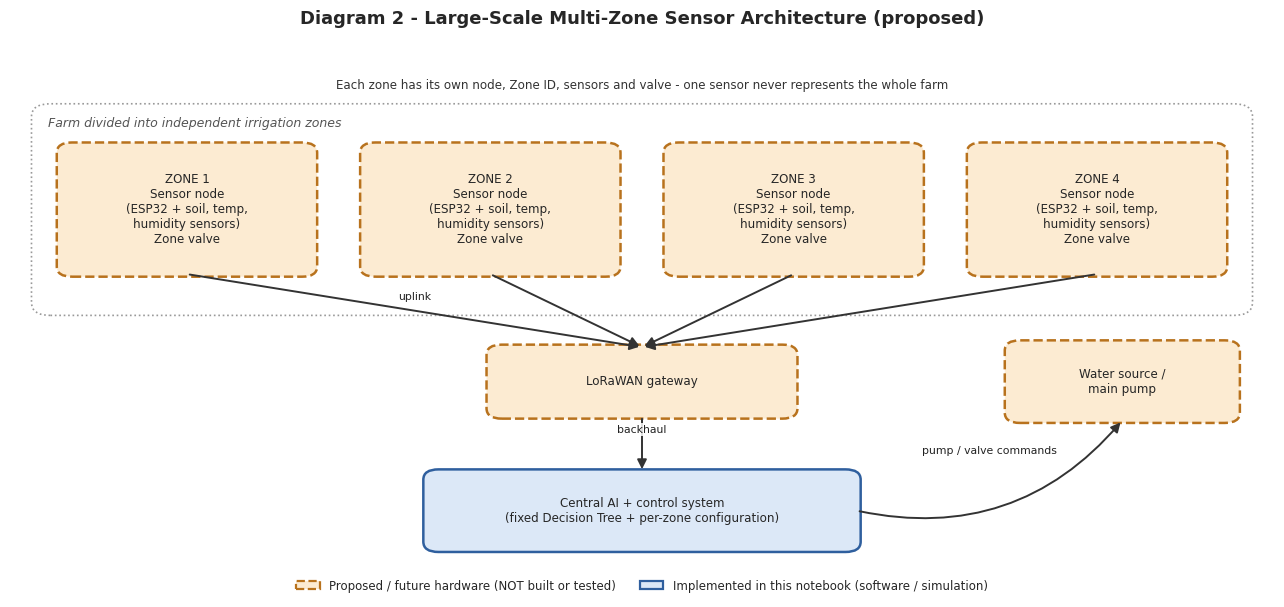

In [69]:
# DIAGRAM 2 - large-scale multi-zone sensor architecture (PROPOSED)
zone_txt = lambda k: f"ZONE {k}\nSensor node\n(ESP32 + soil, temp,\nhumidity sensors)\nZone valve"
boxes = {f"z{k}": (14 + 24 * (k - 1), 44, 20, 15, zone_txt(k), "prop") for k in range(1, 5)}
boxes.update({
    "gw":      (50, 24, 24, 8,  "LoRaWAN gateway", "prop"),
    "central": (50, 9,  34, 9,  "Central AI + control system\n(fixed Decision Tree + per-zone configuration)", "soft"),
    "src":     (88, 24, 18, 9,  "Water source /\nmain pump", "prop"),
})
arrows = [(f"z{k}", "bottom", "gw", "top", "uplink" if k == 1 else "", 0) for k in range(1, 5)]
arrows += [("gw", "bottom", "central", "top", "backhaul", 0), ("central", "right", "src", "bottom", "pump / valve commands", 0.3)]
draw_diagram("Diagram 2 - Large-Scale Multi-Zone Sensor Architecture (proposed)", boxes, arrows, ylim=(2, 64),
             frames=[(50, 44, 96, 24, "Farm divided into independent irrigation zones")],
             notes=[(50, 58.5, "Each zone has its own node, Zone ID, sensors and valve - one sensor never represents the whole farm")])


### 32.1 Illustrative multi-zone calculation

> **Hypothetical readings** for four zones (test inputs, **not** measurements) are passed through the *same* AI model; each zone has its own configuration. If the water source cannot supply all zones at once (sum of zone flow rates > source capacity, a configurable value), the zones are scheduled one after another, *High* before *Medium*, larger moisture deficit first.

Zones requesting water need 120 L/min in total; source capacity 100 L/min -> zones are scheduled sequentially


,Zone,Soil %,Temp °C,Humidity %,AI output,Pump,Runtime (min),Volume (L),Limited by guard-rail?,Start (min),End (min)
0,Zone 1,18.0,33.0,50.0,High,ON,40.0,1600,True,0.0,40.0
1,Zone 2,35.0,27.0,70.0,Low,OFF,0.0,0,False,0.0,0.0
2,Zone 3,24.0,31.0,45.0,High,ON,40.0,1200,True,40.0,80.0
3,Zone 4,27.0,34.0,40.0,Medium,ON,20.0,1000,False,80.0,100.0


Total proposed water: 3,800 L


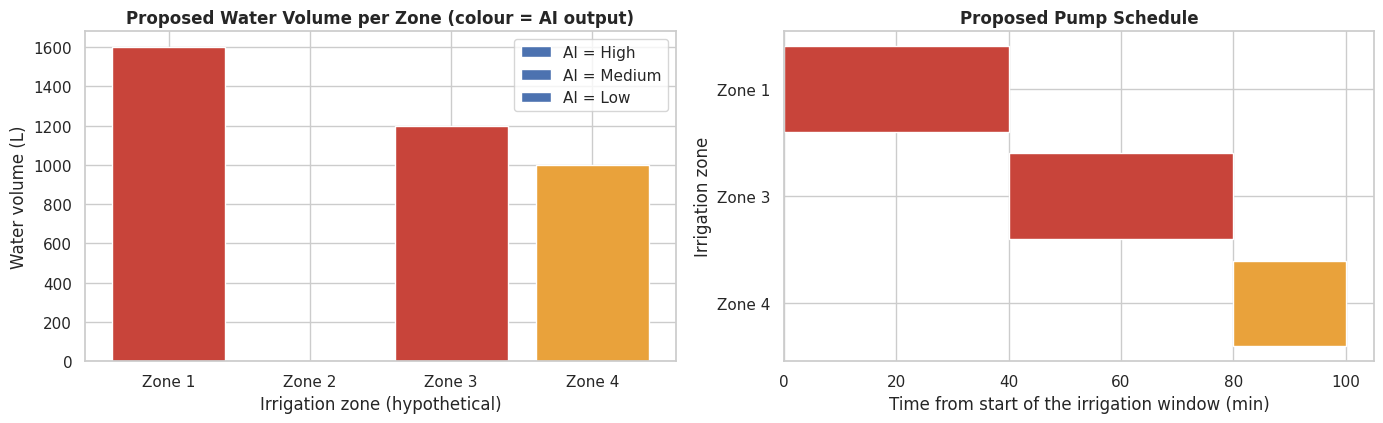

In [70]:
def zone_cfg(**changes):
    return make_config(**{**asdict(EXAMPLE_ZONE), **changes})

ZONE_SETUP = [   # (configuration, hypothetical node reading: soil %, temperature C, humidity %)
    (zone_cfg(zone_id="Zone 1", zone_area_m2=80.0,  root_zone_depth_mm=120.0, application_efficiency=0.90, flow_rate_lpm=40.0, max_runtime_min=40.0, soil_moisture_threshold=30.0, target_soil_moisture=38.0), (18.0, 33.0, 50.0)),
    (zone_cfg(zone_id="Zone 2", zone_area_m2=150.0, root_zone_depth_mm=100.0, application_efficiency=0.75, flow_rate_lpm=60.0, max_runtime_min=45.0, crop_coefficient=0.9, soil_moisture_threshold=28.0, target_soil_moisture=36.0), (35.0, 27.0, 70.0)),
    (zone_cfg(zone_id="Zone 3", zone_area_m2=60.0,  root_zone_depth_mm=150.0, application_efficiency=0.85, flow_rate_lpm=30.0, max_runtime_min=40.0, crop_coefficient=1.1, soil_moisture_threshold=30.0, target_soil_moisture=38.0), (24.0, 31.0, 45.0)),
    (zone_cfg(zone_id="Zone 4", zone_area_m2=100.0, root_zone_depth_mm=100.0, application_efficiency=0.90, flow_rate_lpm=50.0, max_runtime_min=40.0, soil_moisture_threshold=30.0, target_soil_moisture=36.0), (27.0, 34.0, 40.0)),
]
SOURCE_CAPACITY_LPM = 100.0          # configurable: total flow the water source can supply at once (hypothetical)

zone_rows = []
for cfg_z, (s, t, h) in ZONE_SETUP:
    in_range = all(TRAIN_RANGES[f][0] <= v <= TRAIN_RANGES[f][1] for f, v in zip(FEATURES, (s, t, h)))
    ai = frozen_model.predict(pd.DataFrame([[s, t, h]], columns=FEATURES))[0]               # same model for every zone
    p = plan_irrigation(ai, s, cfg_z, now=now, outside_training_range=not in_range)
    zone_rows.append({"Zone": cfg_z.zone_id, "Soil %": s, "Temp °C": t, "Humidity %": h, "AI output": ai, "Pump": p["pump"],
                      "Runtime (min)": round(p["runtime_min"], 1), "Volume (L)": round(p["runtime_min"] * cfg_z.flow_rate_lpm) if p["pump"] == "ON" else 0,
                      "Flow (L/min)": cfg_z.flow_rate_lpm if p["pump"] == "ON" else 0.0, "Limited by guard-rail?": bool(p["calc"] and (p["calc"]["runtime_capped"] or p["calc"]["depth_capped"])), "_priority": (0 if ai == "High" else 1, -(p["calc"]["deficit_pct_points"] if p["calc"] else 0))})
zones_df = pd.DataFrame(zone_rows)

total_flow = zones_df["Flow (L/min)"].sum()
parallel = total_flow <= SOURCE_CAPACITY_LPM
zones_df["Start (min)"], zones_df["End (min)"] = 0.0, 0.0
clock = 0.0
for i in zones_df[zones_df["Pump"] == "ON"].sort_values("_priority").index:
    start = 0.0 if parallel else clock
    zones_df.loc[i, ["Start (min)", "End (min)"]] = [start, start + zones_df.loc[i, "Runtime (min)"]]
    clock = start + zones_df.loc[i, "Runtime (min)"]
print(f"Zones requesting water need {total_flow:g} L/min in total; source capacity {SOURCE_CAPACITY_LPM:g} L/min -> "
      f"{'zones can run in parallel' if parallel else 'zones are scheduled sequentially'}")
display(zones_df.drop(columns=["_priority", "Flow (L/min)"]))
print(f"Total proposed water: {zones_df['Volume (L)'].sum():,} L")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
colors = {"High": "#C8443A", "Medium": "#E9A23B", "Low": "#4C9F70"}
axes[0].bar(zones_df["Zone"], zones_df["Volume (L)"], color=[colors[a] for a in zones_df["AI output"]])
axes[0].set_title("Proposed Water Volume per Zone (colour = AI output)"); axes[0].set_xlabel("Irrigation zone (hypothetical)"); axes[0].set_ylabel("Water volume (L)")
for k, lab in colors.items(): axes[0].bar([], [], color=lab, label=f"AI = {k}")
axes[0].legend()
on = zones_df[zones_df["Pump"] == "ON"].sort_values("Start (min)")
axes[1].barh(on["Zone"], on["End (min)"] - on["Start (min)"], left=on["Start (min)"], color=[colors[a] for a in on["AI output"]])
axes[1].set_title("Proposed Pump Schedule"); axes[1].set_xlabel("Time from start of the irrigation window (min)"); axes[1].set_ylabel("Irrigation zone"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

**Interpretation (hypothetical readings, not measurements).** The same AI model gave *High* for Zones 1 and 3, *Medium* for Zone 4 and *Low* for Zone 2, so only Zone 2 stays OFF. Each zone's runtime comes from its own configuration. The three requesting zones need 120 L/min against a (hypothetical) 100 L/min source, so they are scheduled one after another — Zone 1 (0–40 min), Zone 3 (40–80), Zone 4 (80–100) — for a total of 3,800 L. Zones 1 and 3 hit a guard-rail (the 25 mm depth limit and 40-minute cutoff), as the table shows, which in a real deployment would prompt a review of their configuration.

## Step 33 — Sensor Node, Power and Communication Concept (proposed)

### 33.1 Node architecture
```text
Soil moisture + Temperature + Humidity sensors
        ↓
ESP32 / suitable low-power microcontroller (Zone ID)
        ↓
Wireless communication (e.g. LoRa / LoRaWAN)
        ↓
Central AI + control system
        ↓
Zone-specific valve / pump
```
**Communication (proposed).** For fields spread over large areas, **LoRa/LoRaWAN** is a candidate because it offers long range at very low power and small payloads, which suits a few sensor values every few minutes. A single gateway can serve many nodes. A possible message (design suggestion, not an implemented protocol): Zone ID, soil moisture, temperature, humidity, battery voltage and a message counter — roughly 10 bytes. Other options (Wi-Fi for nearby zones, cellular for remote gateways) depend on site conditions. **None of this has been implemented or tested.**

**Local fail-safe (design requirement).** Each zone's valve controller should enforce the maximum-runtime cutoff **locally** (a hardware/firmware timer), so that a lost radio link or a crashed central server can never leave a valve open.

### 33.2 Power (proposed)
**Solar panel → charge controller → rechargeable battery → regulator → sensor node** (microcontroller, sensors, radio). Low-power operation — sleeping between measurements and waking only to measure and transmit — is the main way to keep the energy demand small. The sizing arithmetic is below.

> **Current prototype vs proposal.** The current prototype is an Arduino sensor set-up that produced the CSV data. **Solar power, batteries, LoRa and multi-node operation have not been built or tested.**

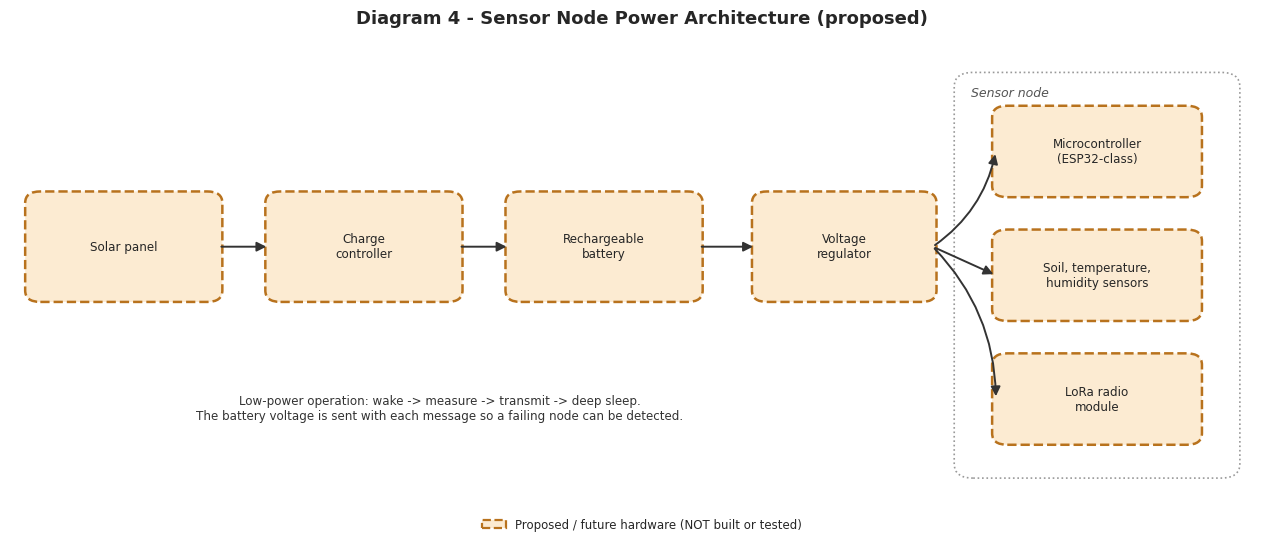

In [71]:
# DIAGRAM 4 - sensor-node power architecture (PROPOSED)
boxes = {
    "solar": (9, 34, 15, 11, "Solar panel", "prop"),
    "chg":   (28, 34, 15, 11, "Charge\ncontroller", "prop"),
    "batt":  (47, 34, 15, 11, "Rechargeable\nbattery", "prop"),
    "reg":   (66, 34, 14, 11, "Voltage\nregulator", "prop"),
    "mcu":   (86, 44, 16, 9,  "Microcontroller\n(ESP32-class)", "prop"),
    "sen":   (86, 31, 16, 9,  "Soil, temperature,\nhumidity sensors", "prop"),
    "radio": (86, 18, 16, 9,  "LoRa radio\nmodule", "prop"),
}
arrows = [("solar", "right", "chg", "left", "", 0), ("chg", "right", "batt", "left", "", 0), ("batt", "right", "reg", "left", "", 0),
          ("reg", "right", "mcu", "left", "", 0.2), ("reg", "right", "sen", "left", "", 0), ("reg", "right", "radio", "left", "", -0.2)]
draw_diagram("Diagram 4 - Sensor Node Power Architecture (proposed)", boxes, arrows, ylim=(6, 56), figsize=(13, 5.6),
             frames=[(86, 31, 22, 42, "Sensor node")],
             notes=[(34, 17, "Low-power operation: wake -> measure -> transmit -> deep sleep.\nThe battery voltage is sent with each message so a failing node can be detected.")])


In [72]:
def node_energy_budget(i_active_mA, t_active_s, i_sleep_mA, period_s, supply_V, autonomy_days, depth_of_discharge, peak_sun_hours, system_efficiency):
    """Sizing arithmetic for ONE node (all inputs must come from datasheets / site data)."""
    i_avg_mA = (i_active_mA * t_active_s + i_sleep_mA * (period_s - t_active_s)) / period_s       # duty-cycle average current
    daily_mAh = i_avg_mA * 24.0
    battery_mAh = daily_mAh * autonomy_days / depth_of_discharge                                     # capacity for N days without sun
    daily_Wh = supply_V * daily_mAh / 1000.0
    panel_W = daily_Wh / (peak_sun_hours * system_efficiency)                                        # panel power for that daily energy
    return {"average current (mA)": i_avg_mA, "energy per day (mAh)": daily_mAh, "battery capacity needed (mAh)": battery_mAh,
            "energy per day (Wh)": daily_Wh, "panel power needed (W)": panel_W}

# PLACEHOLDER INPUTS to illustrate the arithmetic only - NOT measurements and NOT datasheet values of any real component.
placeholder = dict(i_active_mA=120.0, t_active_s=5.0, i_sleep_mA=0.05, period_s=900.0, supply_V=3.7,
                   autonomy_days=3.0, depth_of_discharge=0.5, peak_sun_hours=4.0, system_efficiency=0.6)
duty = node_energy_budget(**placeholder)
always_on = node_energy_budget(**{**placeholder, "t_active_s": placeholder["period_s"]})          # never sleeps
budget = pd.DataFrame({"duty-cycled node (wakes every 15 min for 5 s)": duty, "always-on node (never sleeps)": always_on}).round(2)
display(budget)
print(f"With these PLACEHOLDER numbers, sleeping between readings reduces the average current by a factor of "
      f"{always_on['average current (mA)'] / duty['average current (mA)']:.0f}. Real values must be measured.")

,duty-cycled node (wakes every 15 min for 5 s),always-on node (never sleeps)
average current (mA),0.72,120.00
energy per day (mAh),17.19,2880.00
battery capacity needed (mAh),103.16,17280.00
energy per day (Wh),0.06,10.66
panel power needed (W),0.03,4.44


With these PLACEHOLDER numbers, sleeping between readings reduces the average current by a factor of 168. Real values must be measured.


**Interpretation (placeholder inputs, not measurements or datasheet values).** The arithmetic shows why duty-cycling matters: with the placeholder numbers, waking for 5 s every 15 minutes gives an average current of about 0.72 mA instead of 120 mA, which shrinks the battery from roughly 17,000 mAh to roughly 100 mAh and the panel from about 4.4 W to about 0.03 W. Real nodes consume more (radio join and retransmissions, sensor warm-up, regulator quiescent current, temperature effects), so every input must be replaced by measured or datasheet values before any component is chosen.

## Step 34 — Current Prototype vs Proposed System

| Component | Status | Evidence in this project |
|---|---|---|
| Arduino sensor data collection | ✅ **Demonstrated** | Real log loaded in Step 23 |
| Soil-moisture measurement | ✅ **Demonstrated** | `Soil_Moisture` column in the real CSV (calibration still to be verified) |
| Temperature measurement | ✅ **Demonstrated** | `Temperature_C` column |
| Humidity measurement | ✅ **Demonstrated** | `Humidity` column |
| CSV data collection | ✅ **Demonstrated** | `real_sensor_data.csv` |
| ML inference with the 3 sensor parameters | ✅ **Demonstrated** | Steps 23, 24 |
| Decision Tree prediction (Low/Medium/High) | ✅ **Demonstrated** | Steps 12–16, 23 |
| Control-layer mathematics, configuration, safety logic | 🔵 **Implemented as software and tested with simulated / hypothetical inputs** | Steps 25–31 |
| Closed-loop stop conditions | 🔵 **Simulated only** (assumed soil response) | Step 29 |
| Automatic physical pump control | 🟠 **Proposed / future** | Not built |
| Relay / valve integration | 🟠 **Proposed / future** | Not built |
| Flow sensor | 🟠 **Proposed / future** | Not installed |
| Water-level monitoring | 🟠 **Proposed / future** | Not installed |
| Solar-powered sensor nodes | 🟠 **Proposed / future** | Not built |
| Wireless multi-zone deployment (LoRa/LoRaWAN) | 🟠 **Proposed / future** | Not built |
| Large-scale farm deployment | 🟠 **Proposed / future** | Not attempted |
| User-facing dashboard / app | 🟠 **Proposed / future** | Deliberately not started |

## Step 35 — Limitations

* **Model accuracy is modest.** On the held-out test set the Decision Tree reaches **accuracy 57.8 %**, macro precision 48.4 %, macro recall 59.5 % and macro F1 48.9 % (Step 24.1). Accuracy is *not* higher than always predicting “Low” (58.7 %). It is an **initial prototype**, not a production-ready agricultural model.
* **Dataset limitations.** The training data looks simulated (uniform distributions, hard limits, uncorrelated sensors); its origin and labelling rule are undocumented (Step 5). Patterns such as the ≈ 25 % soil-moisture threshold may reflect how the data was generated rather than real agronomy.
* **No validation against real labelled observations.** The model has not been checked against real field decisions or measured crop/soil outcomes.
* **Three sensors cannot capture everything.** Crop, soil type, weather, growth stage and field conditions all influence irrigation need; a model using all dataset columns reached much higher accuracy (Step 15.1), which shows how much information the three-sensor restriction leaves out.
* **Real readings fall outside the training range.** Much of the real soil-moisture data lies below the lowest value seen in training (8 %), so the model is extrapolating (Steps 23.1 and 31). The real sensor's percentage scale also needs calibration against actual soil.
* **Control constants need field calibration.** Root-zone depth, crop and soil coefficients, application efficiency, flow rate and moisture targets are placeholders until measured or set by an agronomist. The equations ignore drainage, rain, evaporation and soil-water movement, and treat the sensor percentage approximately like volumetric water content.
* **Simulation is not evidence.** The closed-loop results (Step 29) use an assumed soil response; they show the logic works, not how real soil behaves.
* **Probabilities are not calibrated** (class weighting) and the tree has only four leaves, so confidence is coarse.
* **No physical pump automation has been demonstrated.** No relay, valve, pump, flow sensor or water-level sensor has been connected or tested.
* **User-configurable parameters do not eliminate the need for future model validation or retraining** if real-world data shows that the model does not generalize adequately.

## Step 36 — Future Development

1. **Collect labelled real data:** log sensor readings together with the irrigation decisions of an agronomist/farmer (or measured outcomes) over several weeks and conditions; then evaluate — and if necessary retrain — the model on it.
2. **Calibrate the soil-moisture sensor** against gravimetric or reference measurements for the actual soil, and confirm units.
3. **Field-calibrate the control constants** ($D_{root}$, $K_c$, $K_s$, $E_a$, targets) with an agronomist, and measure the real flow rate $Q$ of each zone.
4. **Add evapotranspiration / weather inputs** to the *control* layer (not necessarily the AI) to use a proper $ET_c = K_c\,ET_0$ approach and rain forecasts.
5. **Hardware:** relay/valve driver with a local hardware timer; **flow sensor** (detect no flow, unexpected flow, blockage, excess flow) and **water-level sensor** (tank depletion); both as additional stop conditions.
6. **Multi-zone pilot:** two or three nodes with LoRa/LoRaWAN, solar power and a gateway; measure battery life and packet loss.
7. **Run in recommend-only mode** and compare with human decisions before allowing automatic pump control.
8. **Only afterwards:** a user-facing dashboard/app and scientific-paper writing.

## Step 37 — Final Validation Checks

Automated checks that the requirements for this update are met. Any failure stops the notebook.

In [73]:
checks = []
def check(name, passed, detail=""):
    checks.append({"Check": name, "Result": "PASS" if passed else "FAIL", "Detail": detail})

# --- AI model: unchanged and still the original Decision Tree on three features ---
check("Saved model file was not modified by this notebook", file_sha256(MODEL_FILE) == MODEL_FILE_SHA_START, "SHA-256 " + MODEL_FILE_SHA_START[:12] + "...")
check("Model is the original balanced Decision Tree (depth 2)", type(tree).__name__ == "DecisionTreeClassifier" and tree.get_depth() == 2, f"depth={tree.get_depth()}, leaves={tree.get_n_leaves()}")
check("Model uses only the three sensor features", list(tree.feature_names_in_) == FEATURES, str(FEATURES))
check("Model still reproduces its documented test metrics", all(abs(round(frozen_test_metrics[k], 3) - QUOTED[k]) <= 0.0011 for k in QUOTED), "accuracy %.3f / macro-F1 %.3f" % (frozen_test_metrics["accuracy"], frozen_test_metrics["macro_f1"]))
# --- real data -> model -> control ---
recomputed = frozen_model.predict(real_data[FEATURES])
check("Real sensor data passes through the model (re-prediction identical)", bool((recomputed == real_data["Irrigation_Need"].values).all()), f"{len(real_data)} rows")
check("Control layer received the AI prediction for every real row", bool((control_df["AI_Level"].values == recomputed).all()))
check("AI 'Low' never produces a pump ON", bool((control_df.loc[control_df["AI_Level"] == "Low", "Control_Pump"] == "OFF").all()))
# --- configuration changes control, not the AI ---
check("Changing configuration changes the control result", scenario_rows[0]["Runtime (min)"] != scenario_rows[1]["Runtime (min)"], f"A={scenario_rows[0]['Runtime (min)']} min, B={scenario_rows[1]['Runtime (min)']} min")
check("AI model identical before/after the scenarios", fingerprint_before == fingerprint_after)
check("Both scenarios received the same AI output", scenario_rows[0]["AI output"] == scenario_rows[1]["AI output"], scenario_rows[0]["AI output"])
# --- safety ---
check("All invalid configurations were rejected", bool((invalid_table["outcome"] == "REJECTED").all()), f"{len(invalid_table)} cases")
check("Unvalidated unsafe config -> pump stays OFF", plan_irrigation("High", 20.0, unsafe)["pump"] == "OFF")
check("Absolute runtime cutoff holds even for an unvalidated config", compute_irrigation(unsafe, 20.0)["runtime_applied_min"] <= ABSOLUTE_MAX_RUNTIME_MIN, f"<= {ABSOLUTE_MAX_RUNTIME_MIN:g} min")
check("Invalid sensor reading (NaN) -> pump OFF", plan_irrigation("High", float("nan"), ZONE)["pump"] == "OFF")
check("No simulated cycle exceeded its maximum runtime", all(r["stop_min"] <= min(c.max_runtime_min, ABSOLUTE_MAX_RUNTIME_MIN) + 1e-6 for c, r in sim_results))
check("Fault injection ended by the max-runtime cutoff", sim_results[2][1]["stop_reason"].startswith("3."), sim_results[2][1]["stop_reason"])
check("Per-event depth limit respected in all real-data proposals", bool((control_df["Proposed_Volume_L"] <= REAL_ZONE.zone_area_m2 * MAX_EVENT_DEPTH_MM + 1e-6).all()))
# --- units ---
_unit = make_config(**{**asdict(EXAMPLE_ZONE), "zone_area_m2": 1.0, "depth_mode": "fixed", "fixed_water_depth_mm": 1.0, "application_efficiency": 1.0,
                       "crop_coefficient": 1.0, "soil_adjustment_coefficient": 1.0})
check("Unit identity: 1 mm over 1 m2 = 1 L (code)", abs(compute_irrigation(_unit, 10.0)["volume_required_L"] - 1.0) < 1e-12)
check("Worked example verified through an independent m3/seconds route", abs(volume_L_check - calc["volume_required_L"]) < 1e-6 and abs(runtime_s_check / 60 - calc["runtime_calculated_min"]) < 1e-6)

validation = pd.DataFrame(checks)
pd.set_option("display.max_colwidth", 120)
display(validation)
assert (validation["Result"] == "PASS").all(), "A validation check failed"
print(f"\nALL {len(validation)} CHECKS PASSED")

,Check,Result,Detail
0,Saved model file was not modified by this notebook,PASS,SHA-256 1fae85a798de...
1,Model is the original balanced Decision Tree (depth 2),PASS,"depth=2, leaves=4"
2,Model uses only the three sensor features,PASS,"['Soil_Moisture', 'Temperature_C', 'Humidity']"
3,Model still reproduces its documented test metrics,PASS,accuracy 0.578 / macro-F1 0.489
4,Real sensor data passes through the model (re-prediction identical),PASS,30 rows
5,Control layer received the AI prediction for every real row,PASS,
6,AI 'Low' never produces a pump ON,PASS,
7,Changing configuration changes the control result,PASS,"A=18.1 min, B=35.2 min"
8,AI model identical before/after the scenarios,PASS,
9,Both scenarios received the same AI output,PASS,High



ALL 19 CHECKS PASSED


## Step 38 — Conclusion (updated)

**What this update adds.** The project now separates two responsibilities. A **fixed Decision Tree** performs *irrigation-need inference* from three sensor values (soil moisture, temperature, humidity) and outputs **Low / Medium / High**. A separate, **configurable control layer** — explicit equations plus safety rules, with no machine learning — calculates the irrigation amount and runtime (**area → water depth → volume → flow rate → runtime**), decides whether the pump may start, and stops it when the first valid stop condition occurs (planned volume delivered, sensor target reached, or the maximum-runtime cutoff; flow/water-level monitoring is proposed future hardware).

**What can be changed without retraining.** Zone area, moisture threshold and target, water-depth mode, root-zone depth, crop and soil coefficients, application efficiency, flow rate, runtime limits and irrigation-frequency limits. All of them pass through validation; invalid or unsafe values are rejected, and hard guard-rails remain active regardless. Step 30 shows the same sensor input and the same unchanged model giving different runtimes under two hypothetical configurations.

**What has actually been demonstrated.** Real Arduino sensor readings were collected to CSV and passed through the Decision Tree; the control layer receives the AI prediction and produces *proposed* pump states, volumes and runtimes; the logic, safety limits and unit consistency are verified by automated checks (Step 37) and by simulation.

**What has not.** No pump, relay, valve, flow sensor, solar node or wireless network has been built or tested. The closed-loop behaviour is simulated with an assumed soil response, and the multi-zone, power and LoRa/LoRaWAN material is a **proposed architecture**.

**Honest performance statement.** The model's accuracy is **57.8 %** (macro-F1 48.9 %) and it has not been validated against real labelled field decisions; many real soil-moisture readings lie outside the range it was trained on. Control constants shown here are illustrative placeholders that require field calibration. The system is a **reviewable AI + configurable-control prototype architecture**, not a validated irrigation product.

**Recommended next step.** Collect labelled real data (sensor readings together with expert or outcome-based irrigation decisions), calibrate the soil sensor and the control constants for one real plot, and evaluate/retrain the model on that data — before any dashboard/app development or scientific-paper writing.